### Autoreload

Autoreload allows the notebook to dynamically load code: if we update some helper functions *outside* of the notebook, we do not need to reload the notebook.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../../src
import sys
sys.path.append("../../src/")

# Data understanding - Cyclists Dataset

As first thing we imported all the necessary modules.

In [3]:
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np

In [4]:
from distribution_utility import stats_and_distribution
from distribution_utility import stats_on_missing_values
from distribution_utility import show_bar_plot
from distribution_utility import show_stats
from distribution_utility import correlations
from distribution_utility import show_heatmap

In [5]:
np.random.seed(42)

Dataset loading

In [6]:
cyclists = pd.read_csv('../../dataset/cyclists.csv', sep=",")
races= pd.read_csv('../../dataset/races.csv', sep=",")

In [7]:
cyclists.head()

,_url,name,birth_year,weight,height,nationality
0,bruno-surra,Bruno Surra,1964.0,NaN,NaN,Italy
1,gerard-rue,Gérard Rué,1965.0,74.0,182.0,France
2,jan-maas,Jan Maas,1996.0,69.0,189.0,Netherlands
3,nathan-van-hooydonck,Nathan Van Hooydonck,1995.0,78.0,192.0,Belgium
4,jose-felix-parra,José Félix Parra,1997.0,55.0,171.0,Spain


As we can see, each data object of the _cyclists_ dataset contains some information about a cyclist, in particular the _name_, the _birth year_, the _weight_, the _height_ and the nationality.
Let's see which column types are automatically inferred by Python.

In [8]:
cyclists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6134 entries, 0 to 6133
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   _url         6134 non-null   object 
 1   name         6134 non-null   object 
 2   birth_year   6121 non-null   float64
 3   weight       3078 non-null   float64
 4   height       3143 non-null   float64
 5   nationality  6133 non-null   object 
dtypes: float64(3), object(3)
memory usage: 287.7+ KB


## Evaluation of NaN values

### Check null for each column

In [9]:
stats_on_missing_values(cyclists)

,Feature,Null_counter,Perc_of_null_(%)
0,_url,0,0.0
1,name,0,0.0
2,birth_year,13,0.2
3,weight,3056,49.8
4,height,2991,48.8
5,nationality,1,0.0


### Check distribution of null values across the rows

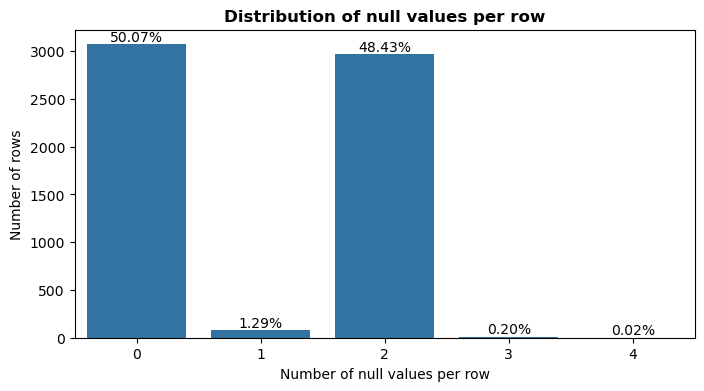

In [10]:
#compute the number of null values for each row
cyclists['null_count'] = cyclists.isnull().sum(axis=1)

plt.figure(figsize=(8, 4))

ax=sbn.countplot(x='null_count', data=cyclists, legend=False)
total = len(cyclists['null_count'])

#% over the bars
for p in ax.patches:
    height = p.get_height()  #height of the bar
    percentage = 100 * height / total  #determine the %
    ax.text(
        p.get_x() + p.get_width() / 2,  #Position the text in the middle of the bar
        height,  #Position on the bar end
        f'{percentage:.2f}%',
        ha='center',           # Horizontal alignment
        va='bottom'            # Vertical alignment
    )

plt.title('Distribution of null values per row', fontweight='bold')
plt.xlabel('Number of null values per row')
plt.ylabel('Number of rows')
plt.show()
plt.close()

Half of the dataset rows do not have null values, almost half of the rows have 2 NaN values (typically height and weight). Few rows have only a single missing value, one between height and weight. <br> Let's find the rows with the highest number of null values. <br>

In [11]:
max_null_count = cyclists['null_count'].max()
rows_with_max_null = cyclists[cyclists['null_count'] == max_null_count]
print("Rows with the highest number of null values:")
display(rows_with_max_null)

Rows with the highest number of null values:


,_url,name,birth_year,weight,height,nationality,null_count
9,scott-davies,Scott Davies,NaN,NaN,NaN,NaN,4


We could see that the cyclist with the most null values is Scott Davies.

In [12]:
races_placings_count = races[races['cyclist'] == "scott-davies"].shape[0]
print(f"Scott-davies appears in {races_placings_count} different races placings")

Scott-davies appears in 52 different races placings


In [13]:
cyclists[cyclists['null_count'] == 3]

,_url,name,birth_year,weight,height,nationality,null_count
601,vladimir-malakov,Vladimir Malakov,NaN,NaN,NaN,Russia,3
894,antonio-zanini,Antonio Zanini,NaN,NaN,NaN,Italy,3
2408,filippo-simonetti,Filippo Simonetti,NaN,NaN,NaN,Italy,3
2515,carlos-garcia,Carlos García,NaN,NaN,NaN,Spain,3
2536,alexandr-osipov,Alexandr Osipov,NaN,NaN,NaN,Russia,3
3046,nicolai-kosyakov,Nicolai Kosyakov,NaN,NaN,NaN,Russia,3
3551,nevens-guy,Guy Nevens,NaN,NaN,NaN,Belgium,3
4142,oscar-pumar,Oscar Pumar,NaN,NaN,NaN,Venezuela,3
4384,javier-luquin,Javier Luquin,NaN,NaN,NaN,Spain,3
4756,thierry-lauder,Thierry Lauder,NaN,NaN,NaN,France,3


There are 12 rows with 3 missing values (weight, height, birth year).

In [14]:
cyclists.drop(['null_count'], axis=1, inplace=True) #drop the artificial column

# Stats on attributes

Custom procedure that produces some basic statistics on a single feature of the dataset.

In [15]:
#'box' parameter enables the boxplot representation
def stats(column, box=False):
    print(f"Description of attribute '{column.name}':")
    display(column.describe())
    print("\nUnique values:")
    print(column.unique())
    mv = column.isna().sum()
    nrec = cyclists.shape[0]
    per=mv*100/nrec
    print(f"\nNull values: {mv} over {nrec} records - ({per:.2f}%)")
    print("\nTop 5 common value:" + "\n"+str(column.value_counts().head()))
    
   
    if box:
        boxplot_dict = plt.boxplot(column[~np.isnan(column)])
        plt.title(f"Boxplot of {column.name}", fontweight='bold')
        #recover outliers from boxplot
        outliers = [flier.get_ydata() for flier in boxplot_dict['fliers']]
        #get the list of outliers without duplicates
        outliers_values = list({value for sublist in outliers for value in sublist})
        print("\nOutliers:", outliers_values)
    
        plt.show()
        plt.close()

## _url_

The _url_ is a categorical feature of type string. It represents a kind of cyclist identifier and it follows the format _name-surname_.

In [16]:
#stats(cyclists['_url'], box=False)
show_stats(cyclists, '_url', 'categorical')

Description of attribute '_url':


count            6134
unique           6134
top       bruno-surra
freq                1
Name: _url, dtype: object


Unique values:
['bruno-surra' 'gerard-rue' 'jan-maas' ... 'paolo-alberati'
 'jackson-rodriguez' 'ward-vanhoof']

Null values: 0 over 6134 records - (0.00%)

Top 5 most frequent values:
_url
bruno-surra               1
rossano-brasi             1
camilo-andres-suarez      1
marco-gilli               1
nelson-rodriguez-serna    1
Name: count, dtype: int64


There are no missing values in this column. There are no duplicates as each cyclist only appears once in the dataset.

## Name

The name is a categorical feature of type string. This columns contains the name of the cyclist in the format '_Name Surname_'.

In [17]:
show_stats(cyclists, 'name', 'categorical')

Description of attribute 'name':


count             6134
unique            6127
top       Jesús  López
freq                 2
Name: name, dtype: object


Unique values:
['Bruno  Surra' 'Gérard  Rué' 'Jan  Maas' ... 'Paolo  Alberati'
 'Jackson  Rodríguez' 'Ward  Vanhoof']

Null values: 0 over 6134 records - (0.00%)

Top 5 most frequent values:
name
Jesús  López          2
Roman  Kreuziger      2
Alberto  Fernández    2
Antonio  Cabello      2
Andrea  Peron         2
Name: count, dtype: int64


Also in this column there are no missing values but, as we can see in the output of the stats function, there are only 6127 unique values (over 6134 rows), which means that there are repetitions of the same name.

In [18]:
name_occurrences=cyclists['name'].value_counts()
duplicate_names=name_occurrences[name_occurrences > 1] #the name is the index of this series
homonyms=duplicate_names.index.tolist()
print(duplicate_names)
print("Homonyms -->",homonyms)

name
Jesús  López          2
Roman  Kreuziger      2
Alberto  Fernández    2
Antonio  Cabello      2
Andrea  Peron         2
Sergio  Domínguez     2
Alessandro  Pozzi     2
Name: count, dtype: int64
Homonyms --> ['Jesús  López', 'Roman  Kreuziger', 'Alberto  Fernández', 'Antonio  Cabello', 'Andrea  Peron', 'Sergio  Domínguez', 'Alessandro  Pozzi']


In [19]:
cyclists[cyclists['name'].isin(homonyms)]

,_url,name,birth_year,weight,height,nationality
347,andrea-peron-1,Andrea Peron,1971.0,70.0,183.0,Italy
1745,roman-kreuziger-sr,Roman Kreuziger,1965.0,NaN,NaN,Czech Republic
2235,alessandro-pozzi2,Alessandro Pozzi,1969.0,NaN,NaN,Italy
2601,roman-kreuziger,Roman Kreuziger,1986.0,65.0,183.0,Czech Republic
2682,andrea-peron,Andrea Peron,1988.0,70.0,178.0,Italy
2862,antonio-cabello-baena,Antonio Cabello,1990.0,67.0,179.0,Spain
2939,jesus-lopez23,Jesús López,1955.0,NaN,NaN,Spain
2953,alberto-fernandez-sainz,Alberto Fernández,1981.0,NaN,NaN,Spain
3238,antonio-cabello,Antonio Cabello,1956.0,NaN,NaN,Spain
4917,sergio-dominguez-rodriguez,Sergio Domínguez,1979.0,NaN,NaN,Spain


Even if there are some cases of homonomy, the _url_ continues to act as a cyclist identifier, since there are some final characters of the _url that make it possible to disambiguate the url of 2 cyclists with the same name-surname.

## Birth Year

_Birth Year_ is a continuous numeric attribute. The float64 column can be cast to int as the unique values are not decimal.

In [20]:
#We use 'Int64' to correctly manage also NaN values
try:
    res = np.all(cyclists['birth_year'] == cyclists['birth_year'].astype('Int64'))
    print(res)
    if res:
        cyclists['birth_year'] = cyclists['birth_year'].astype('Int64')

    print(cyclists['birth_year'].dtype)
except TypeError:
    print("Not castable!")

True
Int64


Description of attribute 'birth_year':


count         6121.0
mean     1974.071884
std        15.535834
min           1933.0
25%           1962.0
50%           1974.0
75%           1987.0
max           2004.0
Name: birth_year, dtype: Float64


Unique values:
<IntegerArray>
[1964, 1965, 1996, 1995, 1997, 1998, 1947, 1988, 1984, <NA>, 1982, 1980, 1970,
 1981, 1985, 1954, 1994, 1951, 1973, 1950, 1979, 1957, 1986, 1991, 1974, 1944,
 1962, 2001, 1978, 1952, 1969, 1968, 1943, 1960, 1972, 1975, 1961, 1949, 1966,
 1990, 1989, 1983, 1956, 1992, 1999, 2002, 1993, 1959, 1948, 1971, 1977, 1987,
 1976, 1967, 1963, 2000, 1955, 1942, 1940, 2003, 1946, 1945, 1953, 1941, 1958,
 1933, 1938, 2004, 1939, 1936, 1934, 1937]
Length: 72, dtype: Int64

Null values: 13 over 6134 records - (0.21%)

Top 5 most frequent values:
birth_year
1964    145
1962    141
1970    140
1974    138
1975    133
Name: count, dtype: Int64


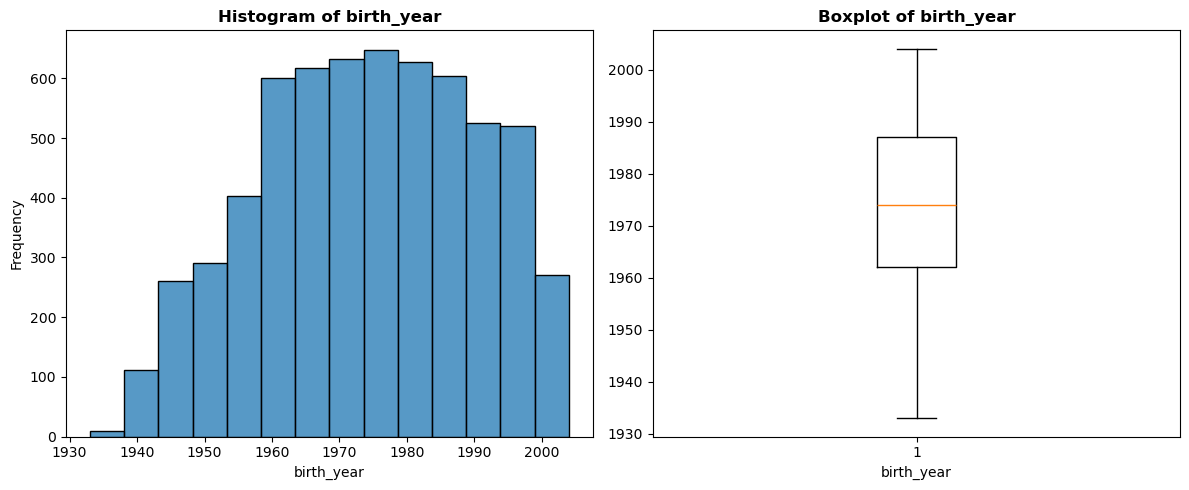

Outliers in birth_year: []


In [21]:
#stats(cyclists['birth_year'], box=True)
stats_and_distribution(cyclists, 'birth_year', 'numerical')

This dataset contains information on cyclists born between the 1933 and 2004. The most represented year is the 1964. There are not outliers or erroneous values. The columns contains 13 missing values, representing 0.21%, but actually this is not a serious problem as we could find this information using external sources (or the difference between the 'date' and 'cyclist age' fields of the races dataset).

Let's the distribution using a different number of bins.

Not Nan: 6121


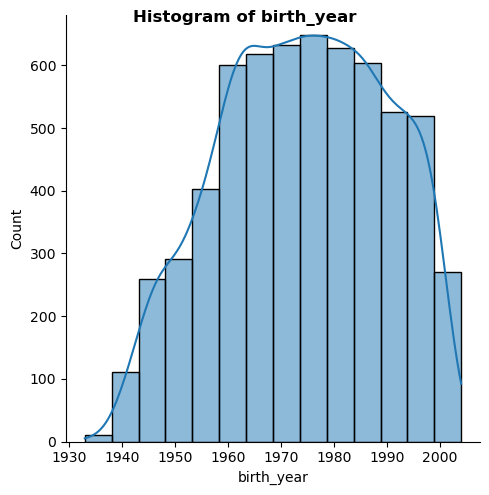

In [22]:
tmp = len(cyclists['birth_year'].dropna(inplace=False))
print("Not Nan:",tmp)

graph=sbn.displot(cyclists, x='birth_year',kind="hist", row_order="desc", bins='sturges', kde=True)
plt.suptitle(f'Histogram of birth_year', fontweight='bold')
plt.show()
plt.close()

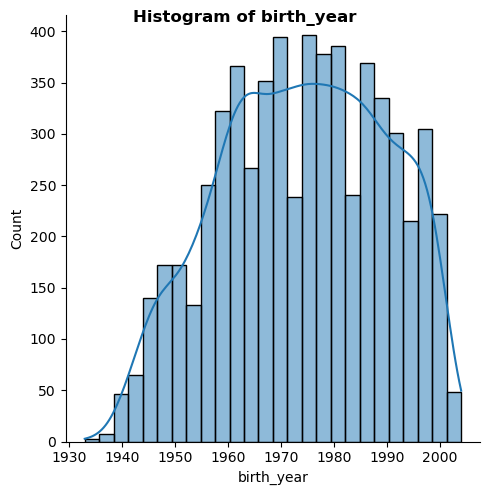

In [23]:
sbn.displot(cyclists, x='birth_year',kind="hist", row_order="desc", kde=True) 
plt.suptitle(f'Histogram of birth_year', fontweight='bold')
plt.show()
plt.close()

## Weight

_Weight_ is a continuous numeric attribute. Its type cannot be cast to int because its values have decimal places.

In [24]:
#We use 'Int64' to correctly manage also NaN values
try:
    res = np.all(cyclists['weight'] == cyclists['weight'].astype('Int64'))
    print("Castable!")
    if res:
        cyclists['weight'] = cyclists['weight'].astype('Int64')
        print(cyclists.dtypes)
except TypeError:
    print("Not castable!")

Not castable!


Description of attribute 'weight':


count    3078.000000
mean       68.658739
std         6.348183
min        48.000000
25%        64.000000
50%        69.000000
75%        73.000000
max        94.000000
Name: weight, dtype: float64


Unique values:
[ nan 74.  69.  78.  55.  67.  71.5 73.  60.  65.  71.  62.  63.  59.
 83.  76.  70.  80.  72.  79.  61.  68.  64.  82.  56.  77.  66.  75.
 58.  53.  57.  91.  81.  88.  85.  84.  86.  67.5 89.  52.  51.  54.
 58.5 48.  90.  63.5 74.5 66.5 78.1 77.5 81.4 50.  87.  62.5 93.  73.5
 79.5 65.1 92.  94. ]

Null values: 3056 over 6134 records - (49.82%)

Top 5 most frequent values:
weight
70.0    272
68.0    219
65.0    193
67.0    177
72.0    169
Name: count, dtype: int64


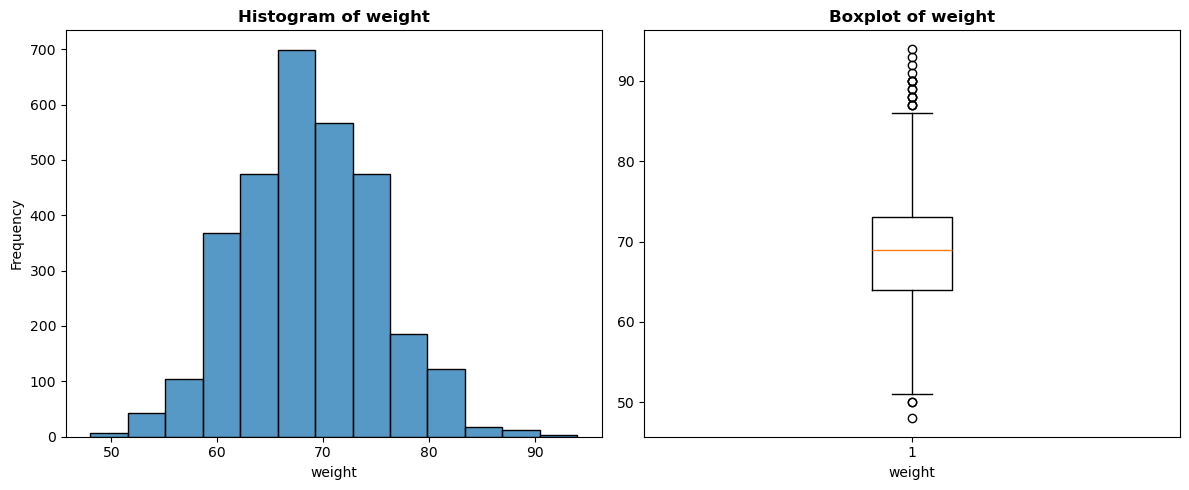

Outliers in weight: [48.0, 50.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0]


In [25]:
stats_and_distribution(cyclists, 'weight', "numerical")

Let's see the distribution using a different number of bins.

Not Nan: 3078


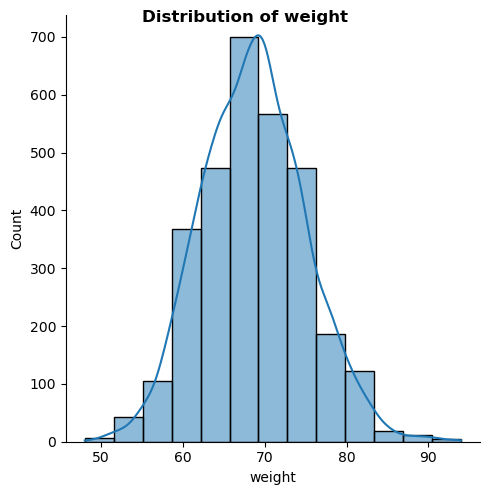

In [26]:
tmp = len(cyclists['weight'].dropna(inplace=False))
print("Not Nan:",tmp)

sbn.displot(cyclists, x='weight',kind="hist", row_order="desc", bins='sturges', kde=True)
plt.suptitle(f'Distribution of weight', fontweight='bold')
plt.show()
plt.close()

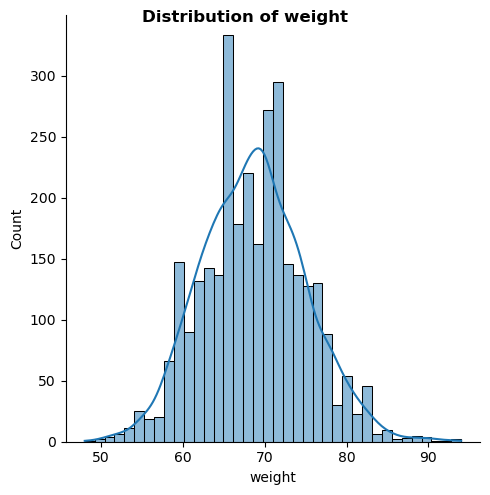

In [27]:
sbn.displot(cyclists, x='weight',kind="hist", row_order="desc", kde=True)
plt.suptitle(f'Distribution of weight', fontweight="bold")
plt.show()
plt.close()

The critical point here is the fact that there are the 49% of missing values. This result suggests that we need to pay attention to how we do the imputation, in order to preserve significant values for this column! There are some outliers in this column, in particular cyclists whose weight is greater than 86 or less than 52. As expected the distribution of the weights follows a quite normal distribution.

## Height

_Height_ is a continuous numeric attribute. Its type be cast to int because its values do not have decimal places.

In [28]:
#We use 'Int64' to correctly manage also NaN values
try:
    res = np.all(cyclists['height'] == cyclists['height'].astype('Int64'))
    print("Castable")
    if res:
        cyclists['height'] = cyclists['height'].astype('Int64')
        print(cyclists.dtypes)
except TypeError:
    print("Not castable!")

Castable
_url            object
name            object
birth_year       Int64
weight         float64
height           Int64
nationality     object
dtype: object


Description of attribute 'height':


count        3143.0
mean     179.815145
std        6.443447
min           154.0
25%           175.0
50%           180.0
75%           184.0
max           204.0
Name: height, dtype: Float64


Unique values:
<IntegerArray>
[<NA>,  182,  189,  192,  171,  177,  191,  175,  178,  181,  172,  174,  180,
  164,  170,  184,  185,  186,  190,  179,  193,  167,  173,  176,  183,  166,
  187,  188,  195,  169,  198,  194,  168,  199,  204,  154,  165,  159,  160,
  196,  162,  161,  163,  155,  158,  197,  202,  157,  200]
Length: 49, dtype: Int64

Null values: 2991 over 6134 records - (48.76%)

Top 5 most frequent values:
height
180    277
178    226
183    193
181    181
175    169
Name: count, dtype: Int64


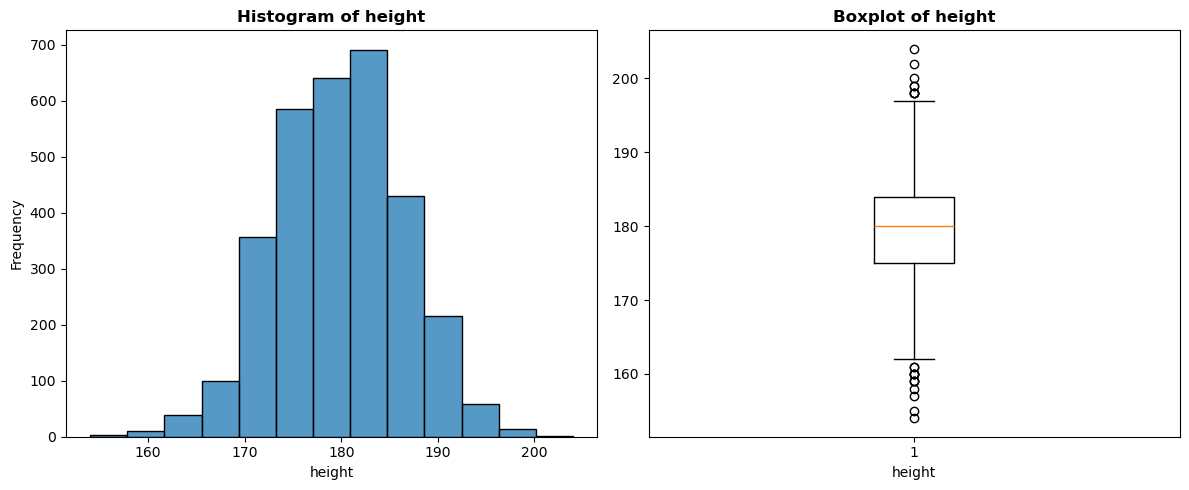

Outliers in height: [160, 161, 198, 199, 200, 202, 204, 154, 155, 157, 158, 159]


In [29]:
stats_and_distribution(cyclists, 'height', 'numerical')

Not Nan: 3143


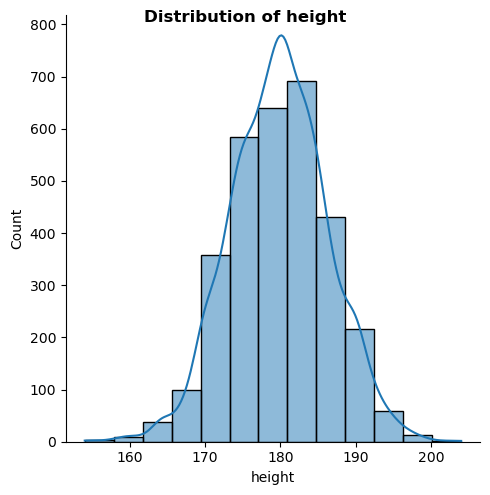

In [30]:
tmp = len(cyclists['height'].dropna(inplace=False))
print("Not Nan:",tmp)

sbn.displot(cyclists, x='height',kind="hist", row_order="desc", bins='sturges', kde=True)
plt.suptitle(f'Distribution of height', fontweight='bold')
plt.show()
plt.close()

Let's try a different number of bins.

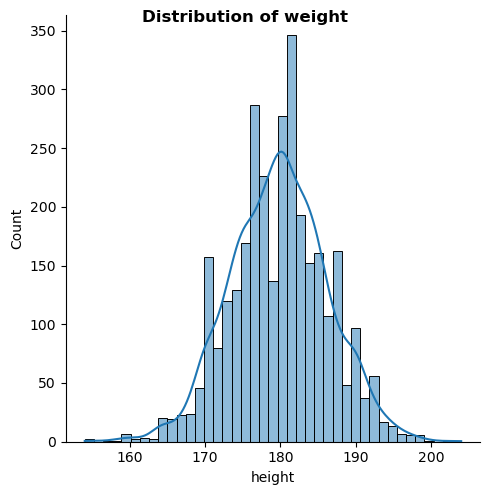

In [31]:
sbn.displot(cyclists, x='height',kind="hist", row_order="desc", kde=True)
plt.suptitle(f'Distribution of weight', fontweight='bold')
plt.show()
plt.close()

The critical point here is the fact that there are the 49% of missing values. This result suggests that we need to pay attention to how we do the imputation, in order to preserve significant values for this column! There are some outliers in this column, in particular cyclists whose height is greater than 197 or less than 162. As expected the distribution of the weights follows a quite normal distribution.

Let's check if all the rows with NaN weight have also a NaN height or not.

In [32]:
print(f"{cyclists[(cyclists['weight'].isna()) & (cyclists['height'].notna())].shape[0]} rows with NaN weight and not NaN height")
print(f"{cyclists[(cyclists['weight'].notna()) & (cyclists['height'].isna())].shape[0]} rows with not NaN weight and NaN height")
print(f"{cyclists[(cyclists['weight'].isna()) & (cyclists['height'].isna())].shape[0]} rows with NaN weight and NaN height")
print(f"{cyclists[(cyclists['weight'].notna()) & (cyclists['height'].notna())].shape[0]} rows with not NaN weight and not NaN height")

72 rows with NaN weight and not NaN height
7 rows with not NaN weight and NaN height
2984 rows with NaN weight and NaN height
3071 rows with not NaN weight and not NaN height


There are situations where only one of the 2 features is NaN. Actually, in most rows with at least one NaN, both features have no value.

## Nationality

_Nationality_ is a categorical feature of type string. It represents the nationality of the cyclist described by that row.

Description of attribute 'nationality':


count      6133
unique       72
top       Italy
freq       1029
Name: nationality, dtype: object


Unique values:
['Italy' 'France' 'Netherlands' 'Belgium' 'Spain' 'United States' nan
 'Norway' 'Russia' 'Poland' 'Germany' 'Australia' 'Switzerland' 'Ireland'
 'Denmark' 'Great Britain' 'Colombia' 'South Africa' 'Argentina'
 'New Zealand' 'Lithuania' 'Portugal' 'Austria' 'Yugoslavia' 'Estonia'
 'Romania' 'Slovenia' 'Canada' 'Latvia' 'Luxembourg' 'Sweden'
 'Czech Republic' 'Slovakia' 'Morocco' 'Ukraine' 'Ethiopia' 'Belarus'
 'Venezuela' 'Japan' 'Mexico' 'Croatia' 'Kazakhstan' 'Uruguay' 'Israel'
 'Namibia' 'Eritrea' 'Costa Rica' 'Taiwan' 'Azerbaijan' 'Hungary'
 'Moldova' 'Panama' 'Finland' 'Bulgaria' 'Serbia' 'Brazil' 'Iran' 'Greece'
 'Chile' 'Ecuador' 'China' 'Albania' 'Guatemala' 'Uzbekistan' 'Algeria'
 'Tunisia' 'Monaco' 'Rwanda' 'Dominican Republic' 'Liechtenstein'
 'Zimbabwe' 'Puerto Rico' 'Hongkong']

Null values: 1 over 6134 records - (0.02%)

Top 5 most frequent values:
nationality
Italy          1029
Spain           872
Belgium         869
France          741
Netherlands     38

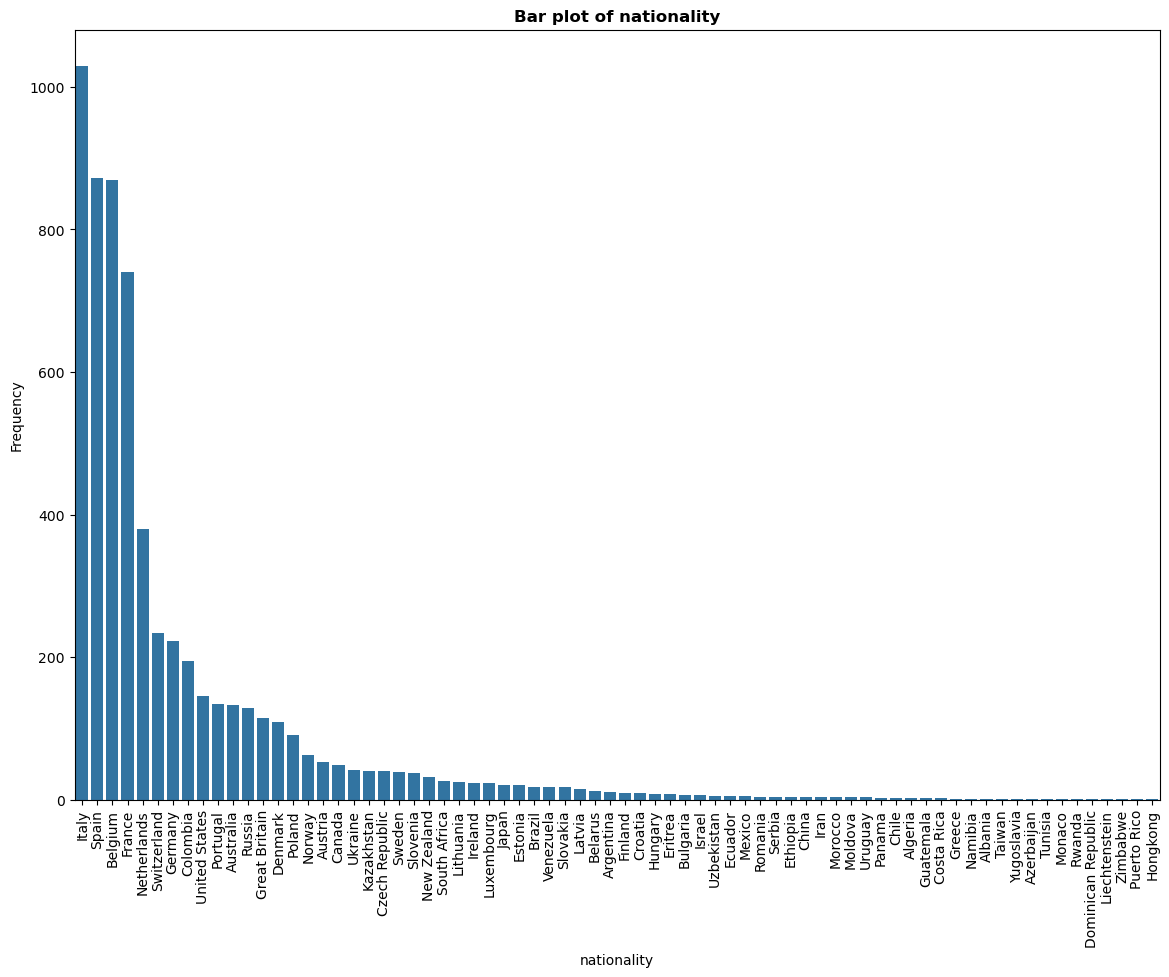

In [33]:
stats_and_distribution(cyclists, 'nationality', 'categorical')

We can see that there is only one missing value, which can easily be solved by using external sources of information. We can see that the country with the most entries is Italy. In total, 72 countries are represented. These values can be aggregated by considering groups of countries such as contients (such as Africa, Oceania, America, Europe, etc.) or geographical areas (North America, Eastern Europe, etc.).

In [34]:
unique_nationalities=cyclists['nationality'].dropna().unique()
sorted(unique_nationalities)

['Albania',
 'Algeria',
 'Argentina',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Belarus',
 'Belgium',
 'Brazil',
 'Bulgaria',
 'Canada',
 'Chile',
 'China',
 'Colombia',
 'Costa Rica',
 'Croatia',
 'Czech Republic',
 'Denmark',
 'Dominican Republic',
 'Ecuador',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Finland',
 'France',
 'Germany',
 'Great Britain',
 'Greece',
 'Guatemala',
 'Hongkong',
 'Hungary',
 'Iran',
 'Ireland',
 'Israel',
 'Italy',
 'Japan',
 'Kazakhstan',
 'Latvia',
 'Liechtenstein',
 'Lithuania',
 'Luxembourg',
 'Mexico',
 'Moldova',
 'Monaco',
 'Morocco',
 'Namibia',
 'Netherlands',
 'New Zealand',
 'Norway',
 'Panama',
 'Poland',
 'Portugal',
 'Puerto Rico',
 'Romania',
 'Russia',
 'Rwanda',
 'Serbia',
 'Slovakia',
 'Slovenia',
 'South Africa',
 'Spain',
 'Sweden',
 'Switzerland',
 'Taiwan',
 'Tunisia',
 'Ukraine',
 'United States',
 'Uruguay',
 'Uzbekistan',
 'Venezuela',
 'Yugoslavia',
 'Zimbabwe']

There are no typing problems in the nationalities.

In [35]:
#Grouping the nationalities in the dataset in groups representing continents
africa = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi',
    'Cape Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros',
    'Republic of the Congo', 'Democratic Republic of the Congo', 'Djibouti',
    'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia',
    'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Kenya', 'Lesotho', 'Liberia',
    'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius',
    'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda',
    'São Tomé and Príncipe', 'Senegal', 'Seychelles', 'Sierra Leone',
    'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania',
    'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
]

america = [
    'Antigua and Barbuda', 'Argentina', 'Bahamas', 'Barbados', 'Belize',
    'Bolivia', 'Brazil', 'Canada', 'Chile', 'Colombia', 'Costa Rica',
    'Cuba', 'Dominica', 'Dominican Republic', 'Ecuador', 'El Salvador',
    'Grenada', 'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Jamaica',
    'Mexico', 'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Saint Kitts and Nevis',
    'Saint Lucia', 'Saint Vincent and the Grenadines', 'Suriname', 'United States',
    'Uruguay', 'Venezuela', 'Puerto Rico'
]

asia = [
    'Afghanistan', 'Saudi Arabia', 'Armenia', 'Azerbaijan', 'Bahrain',
    'Bangladesh', 'Bhutan', 'Myanmar', 'Cambodia', 'China', 'Cyprus',
    'North Korea', 'South Korea', 'United Arab Emirates', 'Philippines',
    'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Laos', 'Lebanon',
    'Malaysia', 'Maldives', 'Mongolia', 'Nepal', 'Oman', 'Pakistan', 'Qatar',
    'Russia', 'Singapore', 'Sri Lanka', 'Syria', 'Tajikistan', 'Taiwan',
    'Thailand', 'Timor-Leste', 'Turkmenistan', 'Uzbekistan', 'Vietnam',
    'Yemen', 'Israel', 'Iran', 'Hongkong'
]

europe = [
    'Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium',
    'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Denmark', 'Estonia',
    'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland',
    'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands',
    'North Macedonia', 'Norway', 'Poland', 'Portugal', 'United Kingdom', 'Great Britain',
    'Czech Republic', 'Romania', 'Russia', 'San Marino', 'Serbia',
    'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine',
    'Vatican City', 'Liechtenstein', 'Yugoslavia'
]

oceania = [
    'Australia', 'Federated States of Micronesia', 'Fiji',
    'Kiribati', 'Marshall Islands', 'Nauru', 'New Zealand', 'Palau',
    'Papua New Guinea', 'Samoa', 'Solomon Islands', 'Tonga', 'Tuvalu',
    'Vanuatu'
]

#New feature ('continent') filling 
def addContinent(dataset, countryColumn):
    dataset.loc[dataset[countryColumn].isin(europe), "continent"] = "Europe"
    dataset.loc[dataset[countryColumn].isin(asia), "continent"] = "Asia"
    dataset.loc[dataset[countryColumn].isin(america), "continent"] = "America"
    dataset.loc[dataset[countryColumn].isin(africa), "continent"] = "Africa"
    dataset.loc[dataset[countryColumn].isin(oceania), "continent"] = "Oceania"

In [36]:
#Countries grouped by continent
addContinent(cyclists, 'nationality')

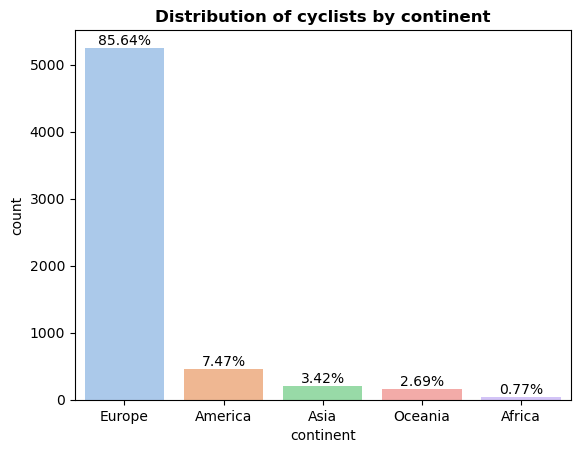

In [37]:
ax=sbn.countplot(x='continent', data=cyclists, palette='pastel', hue='continent', legend=False)

#Total occurrences to determine the %
total = len(cyclists['continent'])

#% over the bars
for p in ax.patches:
    height = p.get_height()  #height of the bar
    percentage = 100 * height / total  #determine the %
    ax.text(
        p.get_x() + p.get_width() / 2,  #Position the text in the middle of the bar
        height,  #Position on the bar end
        f'{percentage:.2f}%',
        ha='center',           # Horizontal alignment
        va='bottom'            # Vertical alignment
    )

plt.title("Distribution of cyclists by continent", fontweight='bold')
plt.show()
plt.close()

As shown above, the majority of cyclists in the dataset are European. Let's create groups with higher granularity only for the Europe, in order to reduce that size, and see how the distribution changes. [GeoScheme](https://it.wikipedia.org/wiki/Geoschema_delle_Nazioni_Unite)

In [38]:
#Definition of smaller groups for the Europe continent
northern_europe = [
    'Denmark', 'Estonia', 'Finland', 'Iceland', 'Ireland', 
    'Latvia', 'Lithuania', 'Norway', 'Sweden', 'United Kingdom', 'Great Britain'
]

eastern_europe = [
    'Belarus', 'Bulgaria', 'Czech Republic', 'Hungary', 
    'Moldova', 'Poland', 'Romania', 'Russia', 'Slovakia', 'Ukraine'
]

western_europe = [
    'Austria', 'Belgium', 'France', 'Germany', 'Luxembourg', 
    'Netherlands', 'Switzerland', 'Liechtenstein', 'Monaco'
]

southern_europe = [
    'Albania', 'Andorra', 'Bosnia and Herzegovina', 'Croatia', 'Greece', 
    'Italy', 'Kosovo', 'Malta', 'Montenegro', 'North Macedonia', 
    'Portugal', 'San Marino', 'Serbia', 'Slovenia', 'Spain', 'Vatican City', 'Yugoslavia'
]

africa = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi',
    'Cape Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros',
    'Republic of the Congo', 'Democratic Republic of the Congo', 'Djibouti',
    'Egypt', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia',
    'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Kenya', 'Lesotho', 'Liberia',
    'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius',
    'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda',
    'São Tomé and Príncipe', 'Senegal', 'Seychelles', 'Sierra Leone',
    'Somalia', 'South Africa', 'South Sudan', 'Sudan', 'Tanzania',
    'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
]

america = [
    'Antigua and Barbuda', 'Argentina', 'Bahamas', 'Barbados', 'Belize',
    'Bolivia', 'Brazil', 'Canada', 'Chile', 'Colombia', 'Costa Rica',
    'Cuba', 'Dominica', 'Dominican Republic', 'Ecuador', 'El Salvador',
    'Grenada', 'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Jamaica',
    'Mexico', 'Nicaragua', 'Panama', 'Paraguay', 'Peru', 'Saint Kitts and Nevis',
    'Saint Lucia', 'Saint Vincent and the Grenadines', 'Suriname', 'United States',
    'Uruguay', 'Venezuela', 'Puerto Rico'
]

asia = [
    'Afghanistan', 'Saudi Arabia', 'Armenia', 'Azerbaijan', 'Bahrain',
    'Bangladesh', 'Bhutan', 'Myanmar', 'Cambodia', 'China', 'Cyprus',
    'North Korea', 'South Korea', 'United Arab Emirates', 'Philippines',
    'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Laos', 'Lebanon',
    'Malaysia', 'Maldives', 'Mongolia', 'Nepal', 'Oman', 'Pakistan', 'Qatar',
    'Russia', 'Singapore', 'Sri Lanka', 'Syria', 'Tajikistan', 'Taiwan',
    'Thailand', 'Timor-Leste', 'Turkmenistan', 'Uzbekistan', 'Vietnam',
    'Yemen', 'Israel', 'Iran', 'Hongkong'
]

oceania = [
    'Australia', 'Federated States of Micronesia', 'Fiji',
    'Kiribati', 'Marshall Islands', 'Nauru', 'New Zealand', 'Palau',
    'Papua New Guinea', 'Samoa', 'Solomon Islands', 'Tonga', 'Tuvalu',
    'Vanuatu'
]

def addGeoArea(dataset, countryColumn):
    dataset.loc[dataset[countryColumn].isin(northern_europe), "geo area"] = "Northern Europe"
    dataset.loc[dataset[countryColumn].isin(eastern_europe), "geo area"] = "Eastern Europe"
    dataset.loc[dataset[countryColumn].isin(western_europe), "geo area"] = "Western Europe"
    dataset.loc[dataset[countryColumn].isin(southern_europe), "geo area"] = "Southern Europe"
    dataset.loc[dataset[countryColumn].isin(africa), "geo area"] = "Africa"
    dataset.loc[dataset[countryColumn].isin(america), "geo area"] = "America"
    dataset.loc[dataset[countryColumn].isin(asia), "geo area"] = "Asia"
    dataset.loc[dataset[countryColumn].isin(oceania), "geo area"] = "Oceania"

In [39]:
# Countries grouped by continent
addGeoArea(cyclists, 'nationality')

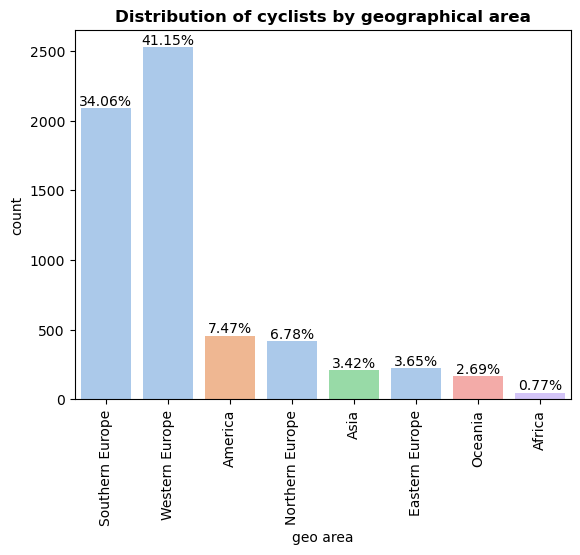

In [40]:
#hue set to continent to assign the same color for the european groups
ax=sbn.countplot(x='geo area', data=cyclists, palette='pastel', hue='continent', legend=False)

#Total occurrences to determine the %
total = len(cyclists['geo area'])

#% over the bars
for p in ax.patches:
    height = p.get_height()  #height of the bar
    percentage = 100 * height / total  #determine the %
    ax.text(
        p.get_x() + p.get_width() / 2,  #Position the text in the middle of the bar
        height,  #Position on the bar end
        f'{percentage:.2f}%',
        ha='center',           # Horizontal alignment
        va='bottom'            # Vertical alignment
    )

plt.title("Distribution of cyclists by geographical area", fontweight='bold')
plt.xticks(rotation=90)
plt.show()
plt.close()

The are still two major groups but there subdivision is quite better than before.

In [41]:
cyclists[cyclists['continent'].isna()] #1 MV because scott-davies has no nationality information

,_url,name,birth_year,weight,height,nationality,continent,geo area
9,scott-davies,Scott Davies,<NA>,NaN,<NA>,NaN,NaN,NaN


## BMI (_New feature_)

This new feature basically combines the 'weight' and the 'height' feature in order to compute the _BodyMassIndex_. <br> [Reference](https://it.wikipedia.org/wiki/Indice_di_massa_corporea)

In [42]:
def generateBMI(dataset, weightcol, heightcol):
    dataset['BMI'] = (dataset[weightcol] / ((dataset[heightcol]/100) ** 2)).round(2)

In [43]:
generateBMI(cyclists, 'weight', 'height')
cyclists

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
0,bruno-surra,Bruno Surra,1964,NaN,<NA>,Italy,Europe,Southern Europe,<NA>
1,gerard-rue,Gérard Rué,1965,74.0,182,France,Europe,Western Europe,22.34
2,jan-maas,Jan Maas,1996,69.0,189,Netherlands,Europe,Western Europe,19.32
3,nathan-van-hooydonck,Nathan Van Hooydonck,1995,78.0,192,Belgium,Europe,Western Europe,21.16
4,jose-felix-parra,José Félix Parra,1997,55.0,171,Spain,Europe,Southern Europe,18.81
...,...,...,...,...,...,...,...,...,...
6129,juan-jose-martinez-diaz,Juan José Martínez,1966,NaN,<NA>,Spain,Europe,Southern Europe,<NA>
6130,inigo-elosegui,Iñigo Elosegui,1998,75.0,188,Spain,Europe,Southern Europe,21.22
6131,paolo-alberati,Paolo Alberati,1973,NaN,<NA>,Italy,Europe,Southern Europe,<NA>
6132,jackson-rodriguez,Jackson Rodríguez,1985,58.0,170,Venezuela,America,America,20.07


Description of attribute 'BMI':


count       3071.0
mean     21.211784
std        1.36741
min          16.41
25%          20.31
50%          21.15
75%          22.09
max          27.77
Name: BMI, dtype: Float64


Unique values:
<FloatingArray>
[ <NA>, 22.34, 19.32, 21.16, 18.81, 21.39,  19.6,  19.8, 19.59, 20.52,
 ...
 25.76, 22.75, 23.34, 24.19, 22.69, 19.28,  25.7, 22.01, 24.98, 18.51]
Length: 433, dtype: Float64

Null values: 3063 over 6134 records - (49.93%)

Top 5 most frequent values:
BMI
20.68    49
21.6     46
20.45    46
20.52    38
21.22    35
Name: count, dtype: Int64


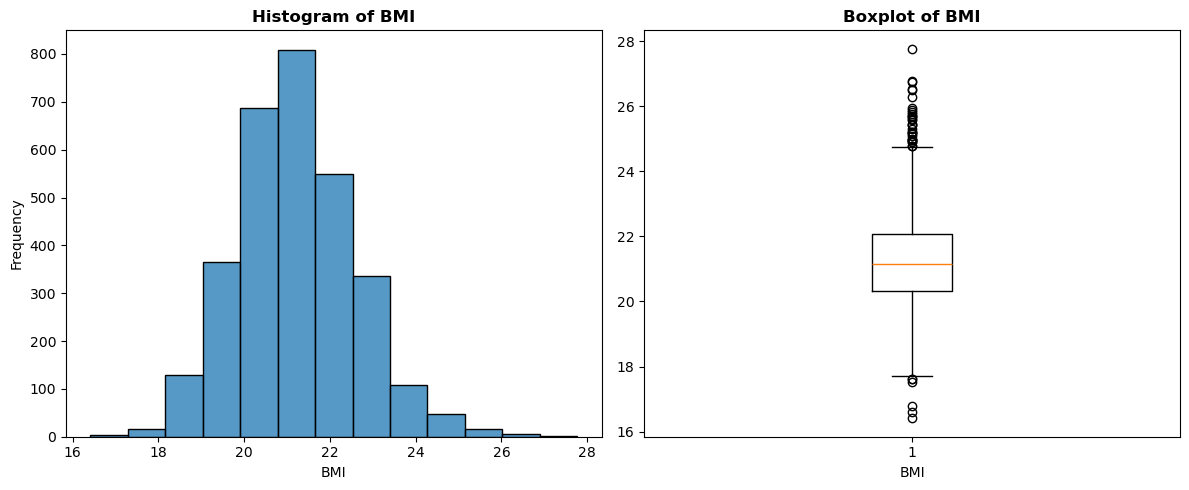

Outliers in BMI: [26.75, 24.96, 27.77, 24.9, 25.45, 16.41, 17.62, 16.79, 17.51, 17.63, 16.6, 25.01, 25.95, 24.97, 25.59, 26.3, 26.53, 25.1, 25.43, 25.31, 25.14, 25.22, 25.17, 26.78, 26.49, 24.78, 25.88, 24.98, 25.76, 25.66, 25.61, 25.44, 25.7, 24.91, 25.83, 25.69]


In [44]:
stats_and_distribution(cyclists, 'BMI', 'numerical')

There are a lot of missing values due to the fact that about 50% of the rows have missing weight or height. As expected, there are outliers due to the small number of underweight cyclists. There is also a great number of overweight cyclists. 
[BMI Ranges](https://www.nhsinform.scot/healthy-living/food-and-nutrition/healthy-eating-and-weight-management/body-mass-index-bmi/#:~:text=BMI%20ranges&text=under%2018.5%20%E2%80%93%20This%20is%20described,This%20is%20described%20as%20obesity) <br>
| BMI Category          | BMI Range     |
|-----------------------|---------------|
| Under Weight          | < 18.5        |
| Normal Weight         | 18.5 - 24.9   |
| Overweight            | 25 - 29.9     |
| Obesity I Degree      | 30 - 34.9     |

#### Height - Weight - BMI by geo area

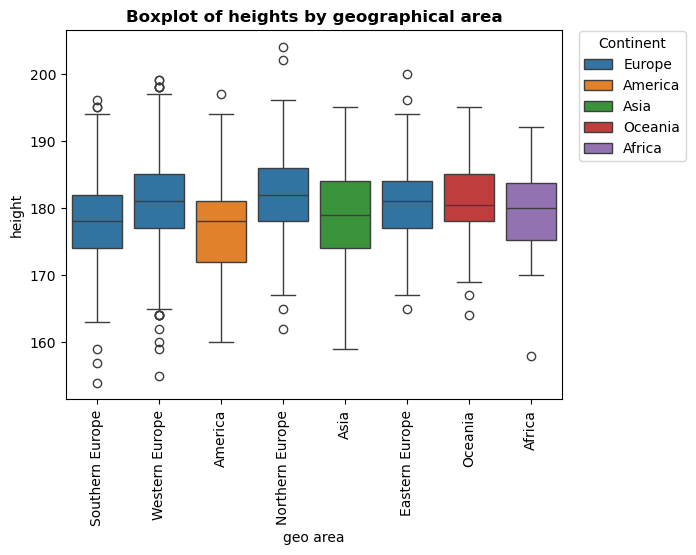

In [45]:
sbn.boxplot(data=cyclists, x='geo area', y='height', hue='continent')
plt.legend(bbox_to_anchor=(1.02, 1.015), loc='upper left', title='Continent')
plt.xticks(rotation=90)
plt.title('Boxplot of heights by geographical area', fontweight='bold')
plt.show()

There are no significant differences in height according to the geographical area of the cyclists. We can see that cyclists from northern europe countries are slightly taller. For the western europe group there is more varability, given the fact that there are more cyclists.

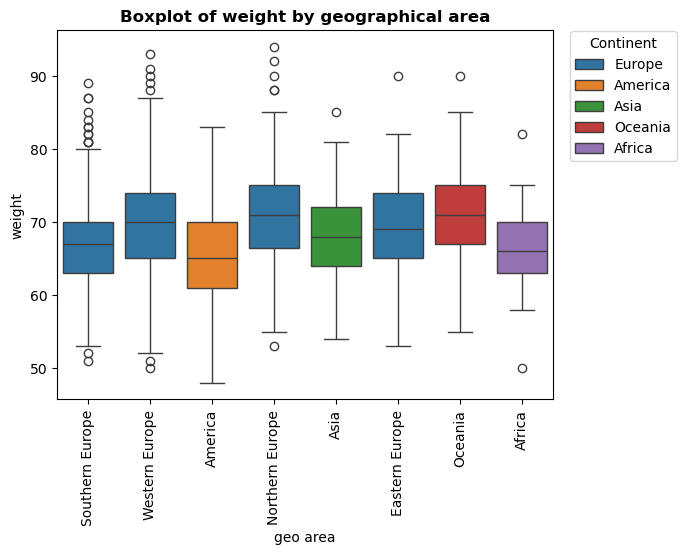

In [46]:
sbn.boxplot(data=cyclists, x='geo area', y='weight', hue='continent')
plt.legend(bbox_to_anchor=(1.02, 1.015), loc='upper left', title='Continent')
plt.xticks(rotation=90)
plt.title('Boxplot of weight by geographical area', fontweight='bold')
plt.show()

We find that African and American cyclists tend to be lighter. The Southern European and Western European groups have many outliers due to high weights because they are the most "populated" groups. The high weights in Northern Europe may be related to the fact that these cyclists tend to be taller, and height and weight are quite correlated features.

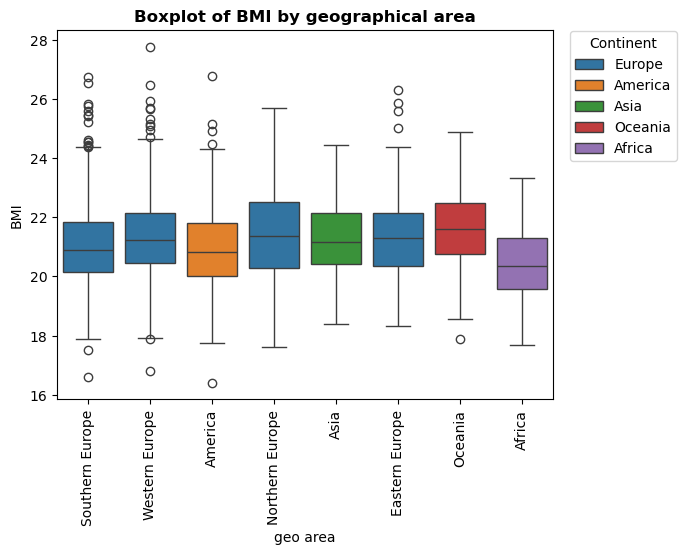

In [47]:
sbn.boxplot(data=cyclists, x='geo area', y='BMI', hue='continent')
plt.legend(bbox_to_anchor=(1.02, 1.015), loc='upper left', title='Continent')
plt.xticks(rotation=90)
plt.title('Boxplot of BMI by geographical area', fontweight='bold')
plt.show()

On average, African cyclists have a lower BMI, while European cyclists have more outliers in the upper parts of the box plots, indicating overweight cyclists.

# Correlation analysis

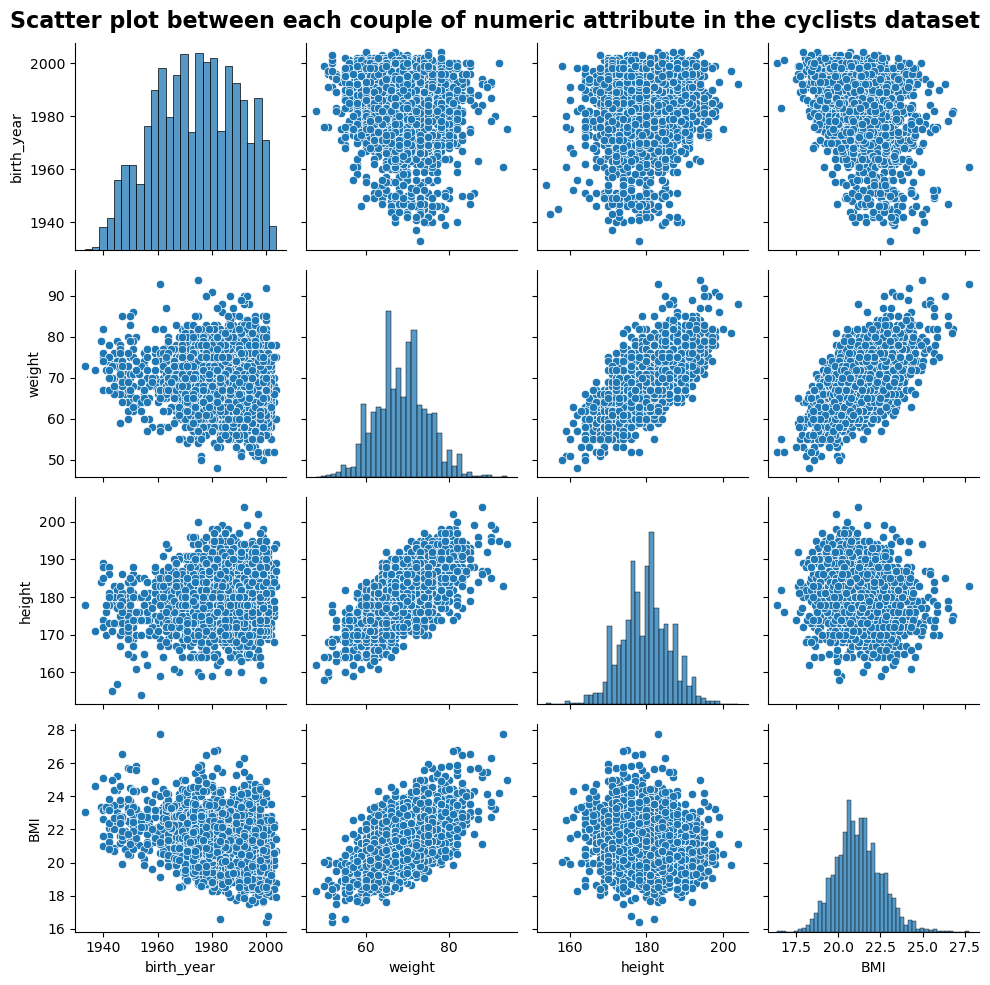

In [48]:
pairplot=sbn.pairplot(cyclists)
pairplot.figure.suptitle("Scatter plot between each couple of numeric attribute in the cyclists dataset", 
                      fontweight='bold', size=16)
plt.tight_layout()
plt.show()
plt.close()

From the scatterplot we immediately notice a correlation between weight-height and weight-BMI.

In [49]:
correlation_matrix=correlations(cyclists.select_dtypes(include="number"))
correlation_matrix

,birth_year,weight,height,BMI,correlation_type
birth_year,1.000000,-0.063740,0.094976,-0.182390,kendall
weight,-0.063740,1.000000,0.539760,0.459364,kendall
height,0.094976,0.539760,1.000000,-0.035217,kendall
BMI,-0.182390,0.459364,-0.035217,1.000000,kendall
birth_year,1.000000,-0.104242,0.154252,-0.303064,pearson
weight,-0.104242,1.000000,0.720732,0.642693,pearson
height,0.154252,0.720732,1.000000,-0.065367,pearson
BMI,-0.303064,0.642693,-0.065367,1.000000,pearson
birth_year,1.000000,-0.091220,0.137001,-0.263694,spearman
weight,-0.091220,1.000000,0.705189,0.628971,spearman


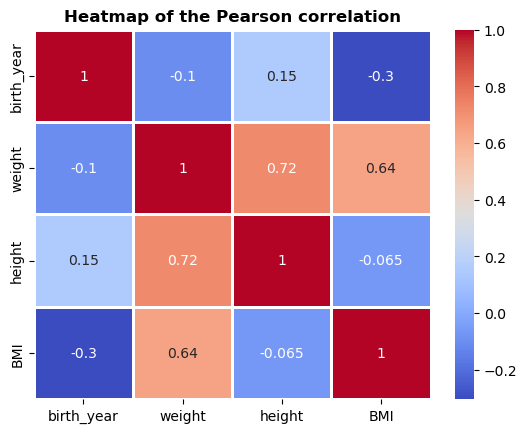

In [50]:
sbn.heatmap(correlation_matrix[correlation_matrix['correlation_type']=='pearson'].drop('correlation_type', axis=1), annot=True, cmap="coolwarm", linewidths=1)
plt.title("Heatmap of the Pearson correlation", fontweight='bold')
plt.show()
plt.close()

We immediately notice a high correlation between height and weight, as expected, and also a high correlation between weight and BMI.

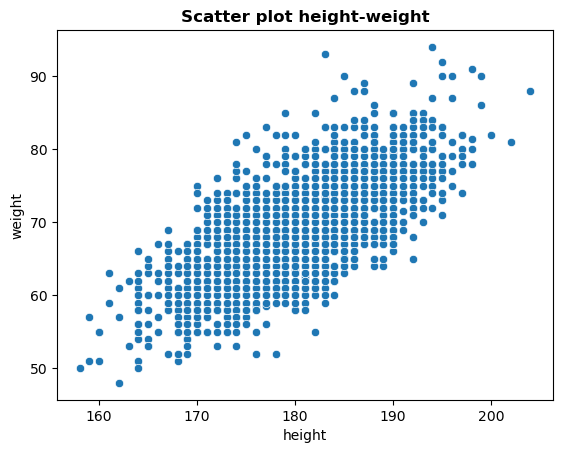

In [51]:
sbn.scatterplot(data=cyclists, x="height", y="weight")
plt.title("Scatter plot height-weight", fontweight='bold')
plt.show()
plt.close()

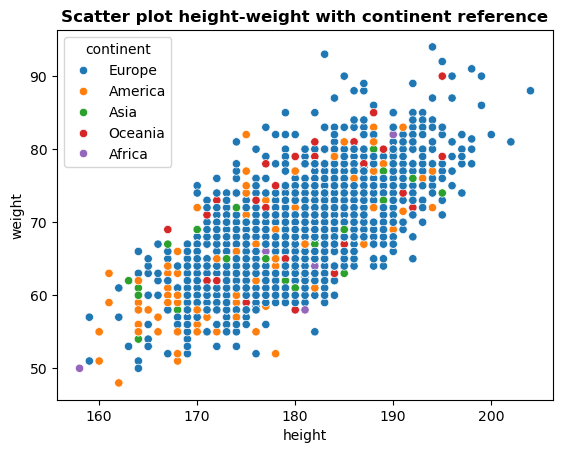

In [52]:
sbn.scatterplot(data=cyclists, x="height", y="weight", hue="continent")
plt.title("Scatter plot height-weight with continent reference", fontweight='bold')
plt.show()
plt.close()

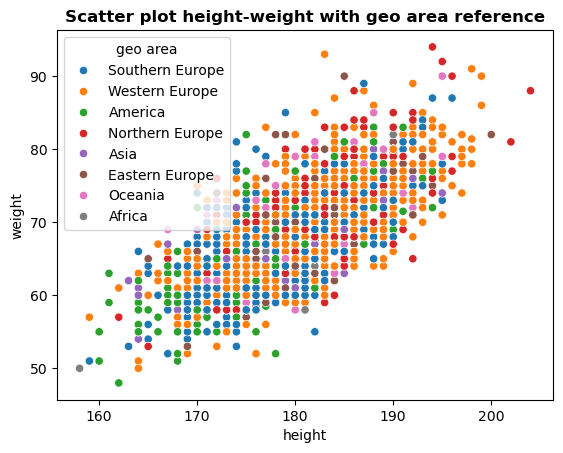

In [53]:
sbn.scatterplot(data=cyclists, x="height", y="weight", hue="geo area")
plt.title("Scatter plot height-weight with geo area reference", fontweight='bold')
plt.show()
plt.close()

These scatter plots, labelled by continent or geographical area, do not show any particular grouping. Weight and height are highly correlated, in fact the points tend to form a linear band.

# Imputations

## Nationality

As there is only one row with a missing nationality, we can use an external source of information. To be sure of the real identity of this cyclist, we check the races in which he has participated.

In [54]:
cyclists[cyclists['nationality'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
9,scott-davies,Scott Davies,<NA>,NaN,<NA>,NaN,NaN,NaN,<NA>


In [55]:
races[races['cyclist']=='scott-davies'].head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta
2063,giro-d-italia/2019/stage-14,Giro d'Italia,80.0,100.0,131000.0,4187.0,4.0,896,NaN,2019-05-25 04:31:35,99,scott-davies,NaN,True,False,False,team-giant-shimano-2014,1752.0
6495,vuelta-a-espana/2020/stage-7,La Vuelta ciclista a España,80.0,100.0,159700.0,2657.0,2.0,692,NaN,2020-10-27 04:05:14,124,scott-davies,NaN,True,False,False,carrera-inoxpran-1985,1018.0
12865,amstel-gold-race/2018/result,Amstel Gold Race,225.0,500.0,263000.0,3496.0,2.0,1139,NaN,2018-04-15 06:39:57,96,scott-davies,NaN,False,False,False,liquigas-2007,290.0
12972,vuelta-a-espana/2020/stage-11,La Vuelta ciclista a España,80.0,100.0,170000.0,5098.0,5.0,692,NaN,2020-10-31 05:26:30,100,scott-davies,NaN,True,False,False,carrera-inoxpran-1985,1937.0
13349,paris-nice/2019/stage-3,Paris - Nice,50.0,60.0,200000.0,896.0,1.0,1099,NaN,2019-03-12 05:16:25,50,scott-davies,NaN,True,False,False,team-giant-shimano-2014,0.0


We have verified that he is the cyclist we are looking for.
Scott Davis [Wikipedia Page](https://en.wikipedia.org/wiki/Scott_Davies_(cyclist)) [ProCyclingStats](https://www.procyclingstats.com/rider/scott-davies)

Scott Davies is the 9th record of the cyclists dataset.

In [56]:
cyclists.loc[9, ['birth_year', 'nationality', 'height', 'weight' ]] = [1995, 'United Kingdom', 183, 68]

In [57]:
cyclists[cyclists['_url']== 'scott-davies']

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
9,scott-davies,Scott Davies,1995,68.0,183,United Kingdom,NaN,NaN,<NA>


In [58]:
cyclists[cyclists['continent'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
9,scott-davies,Scott Davies,1995,68.0,183,United Kingdom,NaN,NaN,<NA>


In [59]:
cyclists[cyclists['geo area'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
9,scott-davies,Scott Davies,1995,68.0,183,United Kingdom,NaN,NaN,<NA>


Update the continent and geo area features after the imputation.

In [60]:
addContinent(cyclists, 'nationality')
addGeoArea(cyclists, 'nationality')

## Birth Year

In [61]:
cyclists[cyclists['birth_year'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
601,vladimir-malakov,Vladimir Malakov,<NA>,NaN,<NA>,Russia,Asia,Asia,<NA>
894,antonio-zanini,Antonio Zanini,<NA>,NaN,<NA>,Italy,Europe,Southern Europe,<NA>
2408,filippo-simonetti,Filippo Simonetti,<NA>,NaN,<NA>,Italy,Europe,Southern Europe,<NA>
2515,carlos-garcia,Carlos García,<NA>,NaN,<NA>,Spain,Europe,Southern Europe,<NA>
2536,alexandr-osipov,Alexandr Osipov,<NA>,NaN,<NA>,Russia,Asia,Asia,<NA>
3046,nicolai-kosyakov,Nicolai Kosyakov,<NA>,NaN,<NA>,Russia,Asia,Asia,<NA>
3551,nevens-guy,Guy Nevens,<NA>,NaN,<NA>,Belgium,Europe,Western Europe,<NA>
4142,oscar-pumar,Oscar Pumar,<NA>,NaN,<NA>,Venezuela,America,America,<NA>
4384,javier-luquin,Javier Luquin,<NA>,NaN,<NA>,Spain,Europe,Southern Europe,<NA>
4756,thierry-lauder,Thierry Lauder,<NA>,NaN,<NA>,France,Europe,Western Europe,<NA>


There are 13 values for which we do not have the birth year value. We can try to reconstruct using external sources. <br>
Vladimir Malakhov [Wiki](https://en.wikipedia.org/wiki/Vladimir_Malakhov_(cyclist)) [ProCyclingStats](https://www.procyclingstats.com/rider/vladimir-malakov) <br>
Antonio Zanini [ProCyclingStats](https://www.procyclingstats.com/rider/antonio-zanini) <br>
Filippo Simonetti (No Info on BirthYear, Weight, Height) <br>
Carlos Garcia (No Info on BirthYear, Weight, Height) [ProCyclingStats](https://www.procyclingstats.com/rider/carlos-garcia) <br>
Alexandr Osipov (No Info on BirthYear, Weight, Height) [FirstCycling](https://firstcycling.com/rider.php?r=23320#racedata) <br>
Nicolai Kosyakov (No Info on BirthYear, Weight, Height) [ProCyclingStats](https://www.procyclingstats.com/rider/nicolai-kosyakov) <br>
Nevens Guy (No Info on BirthYear, Weight, Height) [ProCyclingStats](https://www.procyclingstats.com/rider/nevens-guy) <br>
Omar Pumar (No Info on BirthYear, Weight, Height) [ProCyclingStats](https://www.procyclingstats.com/rider/omar-pumar/1995) <br>
Javier Luquin (No Info on BirthYear, Weight, Height) <br>
Thierry Lauder (No Info on BirthYear, Weight, Height) [ProCyclingStats](https://www.procyclingstats.com/rider/thierry-lauder) <br>
Sergei Jermachenko (No Info on BirthYear, Weight, Height) [ProCyclingStats](https://www.procyclingstats.com/rider/sergei-jermachenko) <br>
Batik Odriozola (No Info on BirthYear, Weight, Height) [ProCyclingStats](https://www.procyclingstats.com/rider/batik-odriozola)

Unfortunately, we were unable to find information for most of the missing years of birth. The following cells refer to the check carried out to verify the correspondence between the races recorded for these cyclists in external sources and those recorded in our races dataset.

In [62]:
races[races['cyclist']=='antonio-zanini'].head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta
21373,ronde-van-vlaanderen/1990/result,Ronde van Vlaanderen / Tour des Flandres,275.0,NaN,265000.0,NaN,NaN,888,NaN,1990-04-01 07:00:50,96,antonio-zanini,NaN,False,False,False,NaN,805.0
555652,paris-roubaix/1990/result,Paris - Roubaix,275.0,NaN,265000.0,NaN,NaN,763,NaN,1990-04-08 08:13:30,86,antonio-zanini,NaN,False,False,False,NaN,2188.0


In [63]:
races[races['cyclist']=='vladimir-malakov'].head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta
30249,vuelta-a-espana/1985/stage-12,Vuelta a España,80.0,NaN,16000.0,1099.0,NaN,925,NaN,1985-05-05 00:40:25,61,vladimir-malakov,NaN,True,False,False,NaN,331.0
37684,vuelta-a-espana/1985/stage-19,Vuelta a España,80.0,NaN,175000.0,1616.0,NaN,925,NaN,1985-05-12 04:15:11,0,vladimir-malakov,NaN,True,False,False,NaN,0.0
79444,vuelta-a-espana/1985/stage-18,Vuelta a España,80.0,NaN,200000.0,4268.0,NaN,925,NaN,1985-05-11 05:44:07,48,vladimir-malakov,NaN,True,False,False,NaN,1014.0
112356,vuelta-a-espana/1985/stage-5,Vuelta a España,80.0,NaN,238000.0,3500.0,NaN,925,NaN,1985-04-28 07:13:51,13,vladimir-malakov,NaN,True,False,False,NaN,1.0
176522,vuelta-a-espana/1985/stage-17,Vuelta a España,80.0,NaN,43000.0,531.0,NaN,925,NaN,1985-05-10 01:05:40,55,vladimir-malakov,NaN,True,False,False,NaN,368.0


In [64]:
races[races['cyclist']=='thierry-lauder'].head()

,_url,name,points,uci_points,length,climb_total,profile,startlist_quality,average_temperature,date,position,cyclist,cyclist_age,is_tarmac,is_cobbled,is_gravel,cyclist_team,delta
158401,dauphine/2000/prologue,Criterium du Dauphiné Libére,50.0,NaN,3600.0,NaN,NaN,494,NaN,2000-06-04 00:11:13,99,thierry-lauder,NaN,True,False,False,NaN,137.0


In [65]:
#Vladimir Malakov
cyclists.loc[601, ['birth_year', 'nationality']] = [1958, 'Russia']
#Antonio Zanini
cyclists.loc[894, ['birth_year', 'nationality']] = [1965, 'Italy']

In [66]:
names_with_null_birth_year = cyclists[cyclists['birth_year'].isna()]['_url'].tolist()
races[races['cyclist'].isin(names_with_null_birth_year)]['cyclist_age'].notna().any()

False

Unfortunately, the cyclists for whom we have no further information do not have a not NaN 'cyclist_age' field in the corresponding race rows.

## Weight

The two columns with the most missing values are height and weight. Let's try to find a strategy to reconstruct the proper values for that column.

In [67]:
#save the dataset before the imputation to compare the distributions
cyclists_preImputation=cyclists.copy()

In [68]:
cyclists[cyclists['weight'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
0,bruno-surra,Bruno Surra,1964,NaN,<NA>,Italy,Europe,Southern Europe,<NA>
6,willy-moonen,Willy Moonen,1947,NaN,<NA>,Belgium,Europe,Western Europe,<NA>
10,stian-remme,Stian Remme,1982,NaN,<NA>,Norway,Europe,Northern Europe,<NA>
13,evgueny-anachkine,Evgueny Anachkine,1970,NaN,<NA>,Russia,Asia,Asia,<NA>
14,maurizio-biondo,Maurizio Biondo,1981,NaN,<NA>,Italy,Europe,Southern Europe,<NA>
...,...,...,...,...,...,...,...,...,...
6124,henri-vandenabeele,Henri Vandenabeele,2000,NaN,181,Belgium,Europe,Western Europe,<NA>
6127,hendrik-van-dyck,Hendrik Van Dyck,1974,NaN,<NA>,Belgium,Europe,Western Europe,<NA>
6128,francisco-jose-pacheco,Francisco José Pacheco,1982,NaN,<NA>,Spain,Europe,Southern Europe,<NA>
6129,juan-jose-martinez-diaz,Juan José Martínez,1966,NaN,<NA>,Spain,Europe,Southern Europe,<NA>


In [69]:
def imputationComparison(original_df, imputed_df, column):
    #Two plots in the same row
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sbn.histplot(original_df, x=column, ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram of "{column}" pre-imputation', fontweight='bold')
    axes[0].set_xlabel(column)
    axes[0].set_ylabel('Frequency')

    sbn.histplot(imputed_df, x=column, ax=axes[1], kde=True)
    axes[1].set_title(f'Histogram of "{column}" after-imputation', fontweight='bold')
    axes[1].set_xlabel(column)
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
    plt.close()

### Simple mean

In [70]:
imputer=SimpleImputer(strategy="mean")
imputer.fit(cyclists[['weight']])
cyclists['weight']=imputer.transform(cyclists[['weight']]).squeeze()

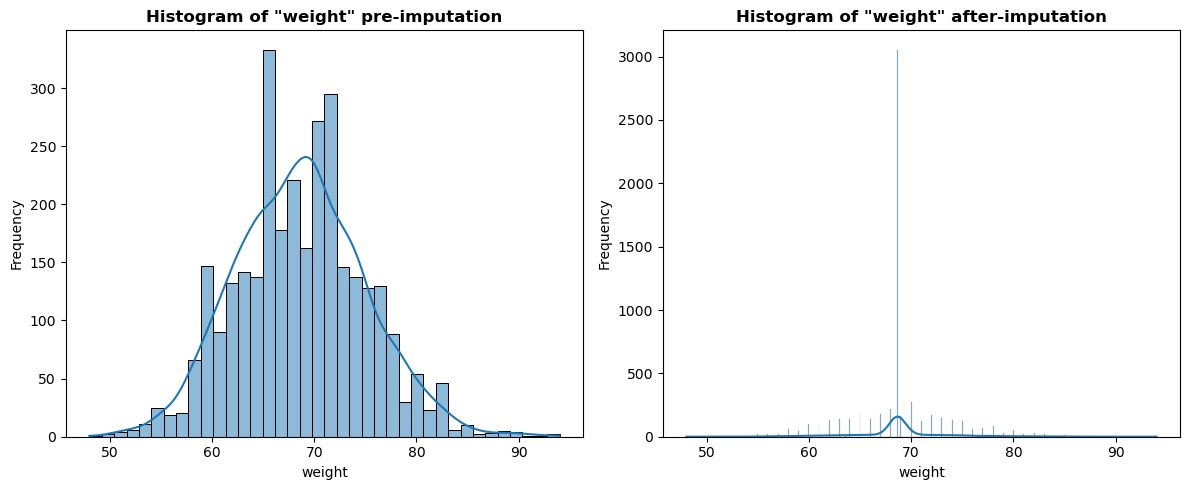

In [71]:
imputationComparison(cyclists_preImputation, cyclists, 'weight')

### Mean considering the nationality

In [72]:
cyclists=cyclists_preImputation.copy()

In [73]:
cyclists[cyclists['weight'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
0,bruno-surra,Bruno Surra,1964,NaN,<NA>,Italy,Europe,Southern Europe,<NA>
6,willy-moonen,Willy Moonen,1947,NaN,<NA>,Belgium,Europe,Western Europe,<NA>
10,stian-remme,Stian Remme,1982,NaN,<NA>,Norway,Europe,Northern Europe,<NA>
13,evgueny-anachkine,Evgueny Anachkine,1970,NaN,<NA>,Russia,Asia,Asia,<NA>
14,maurizio-biondo,Maurizio Biondo,1981,NaN,<NA>,Italy,Europe,Southern Europe,<NA>
...,...,...,...,...,...,...,...,...,...
6124,henri-vandenabeele,Henri Vandenabeele,2000,NaN,181,Belgium,Europe,Western Europe,<NA>
6127,hendrik-van-dyck,Hendrik Van Dyck,1974,NaN,<NA>,Belgium,Europe,Western Europe,<NA>
6128,francisco-jose-pacheco,Francisco José Pacheco,1982,NaN,<NA>,Spain,Europe,Southern Europe,<NA>
6129,juan-jose-martinez-diaz,Juan José Martínez,1966,NaN,<NA>,Spain,Europe,Southern Europe,<NA>


In [74]:
grouped_mean_for_nationality = cyclists.groupby('nationality')['weight'].transform('mean')
cyclists['weight']=cyclists['weight'].fillna(grouped_mean_for_nationality)

No value for this imputation strategy if there is only a single row for that nationality which has no weight value.

In [75]:
cyclists[cyclists['weight'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
102,primoz-cerin,Primož Čerin,1962,NaN,<NA>,Yugoslavia,Europe,Southern Europe,<NA>
5557,sigmund-hermann,Sigmund Hermann,1959,NaN,<NA>,Liechtenstein,Europe,Western Europe,<NA>
5707,timothy-jones,Timothy David Jones,1975,NaN,<NA>,Zimbabwe,Africa,Africa,<NA>


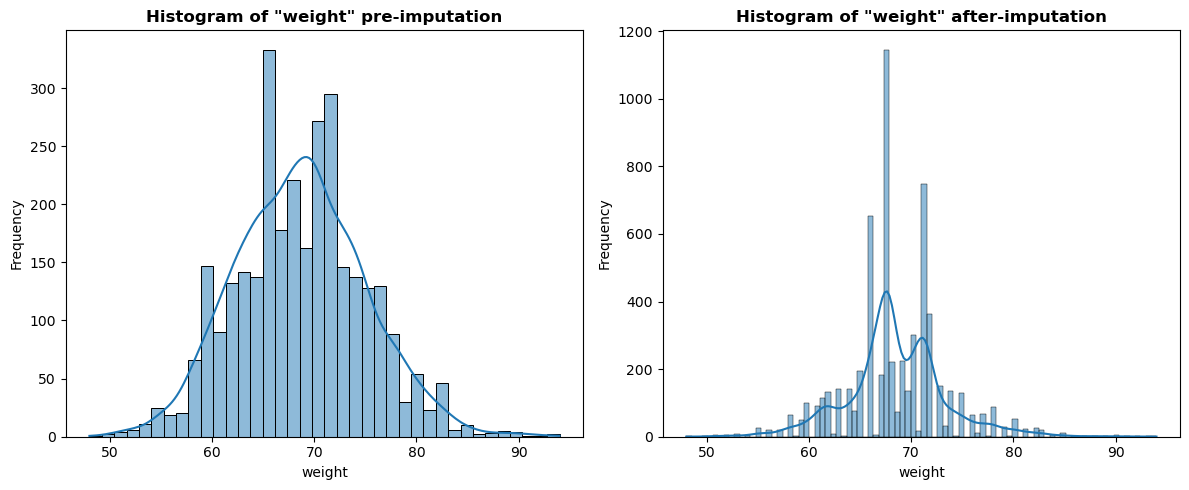

In [76]:
imputationComparison(cyclists_preImputation, cyclists, 'weight')

### Mean considering nationality and birth year

In [77]:
cyclists=cyclists_preImputation.copy()
grouped_mean_for_nationality = cyclists.groupby(['nationality','birth_year'])['weight'].transform('mean')
cyclists['weight']=cyclists['weight'].fillna(grouped_mean_for_nationality)

In [78]:
cyclists[cyclists['weight'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
10,stian-remme,Stian Remme,1982,NaN,<NA>,Norway,Europe,Northern Europe,<NA>
26,alain-gallopin,Alain Gallopin,1957,NaN,<NA>,France,Europe,Western Europe,<NA>
41,gaetano-baronchelli,Gaetano Baronchelli,1952,NaN,<NA>,Italy,Europe,Southern Europe,<NA>
59,christian-muselet,Christian Muselet,1952,NaN,<NA>,France,Europe,Western Europe,<NA>
93,paulo-jose-dos-santos-ferreira,Paulo José dos Santos Ferreira,1962,NaN,<NA>,Portugal,Europe,Southern Europe,<NA>
...,...,...,...,...,...,...,...,...,...
6088,eric-antonio-fagundez,Eric Antonio Fagúndez,1998,NaN,180,Uruguay,America,America,<NA>
6091,dirk-baert,Dirk Baert,1949,NaN,<NA>,Belgium,Europe,Western Europe,<NA>
6093,raul-alexander-montana-herrera,Raúl Alexander Montaña,1971,NaN,<NA>,Colombia,America,America,<NA>
6096,frans-van-vlierberghe,Frans Van Vlierberghe,1954,NaN,<NA>,Belgium,Europe,Western Europe,<NA>


No value for this imputation strategy if there is only a single row for that couple <nationality, birth year> which has no weight value.

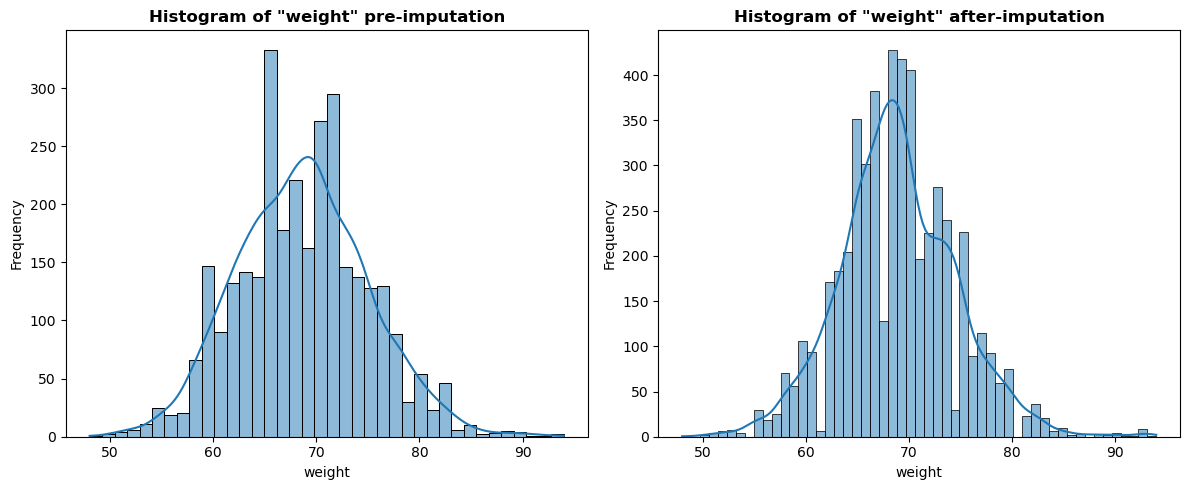

In [79]:
imputationComparison(cyclists_preImputation, cyclists, 'weight')

### Mean considering continent

In [80]:
cyclists=cyclists_preImputation.copy()
grouped_mean_for_nationality = cyclists.groupby(['continent'])['weight'].transform('mean')
cyclists['weight']=cyclists['weight'].fillna(grouped_mean_for_nationality)

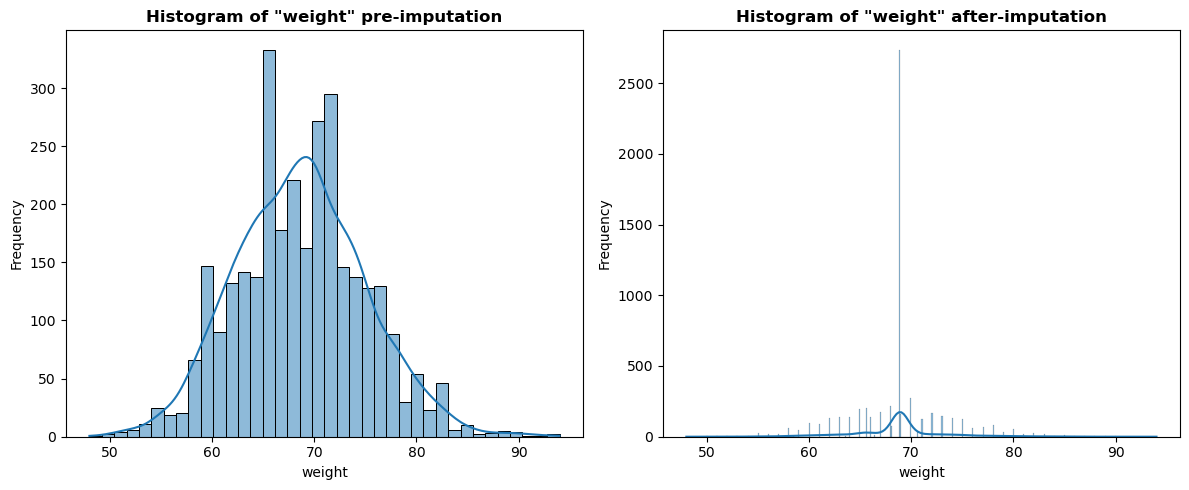

In [81]:
imputationComparison(cyclists_preImputation, cyclists, 'weight')

Not a good choice because, even if all the rows have a continent reference, the imputation is affected by the high number of rows related to european cyclists.

### Mean considering continent and birth year

In [82]:
cyclists=cyclists_preImputation.copy()
grouped_mean_for_nationality = cyclists.groupby(['continent','birth_year'])['weight'].transform('mean')
cyclists['weight']=cyclists['weight'].fillna(grouped_mean_for_nationality)

In [83]:
cyclists[cyclists['weight'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
151,darren-lill,Darren Lill,1982,NaN,<NA>,South Africa,Africa,Africa,<NA>
284,ruben-dario-beltran,Ruben Dario Beltran,1964,NaN,<NA>,Colombia,America,America,<NA>
315,oleg-iarochenko,Oleg Iarochenko,1962,NaN,<NA>,Russia,Asia,Asia,<NA>
316,andrei-vedernikov,Andrei Vedernikov,1959,NaN,<NA>,Russia,Asia,Asia,<NA>
384,asiat-saitov,Asiat Saitov,1965,NaN,<NA>,Russia,Asia,Asia,<NA>
...,...,...,...,...,...,...,...,...,...
5968,nathan-dahlberg,Nathan Dahlberg,1964,NaN,<NA>,New Zealand,Oceania,Oceania,<NA>
5975,victor-demidenko,Víctor Demidenko,1962,NaN,<NA>,Russia,Asia,Asia,<NA>
5988,eric-heiden,Eric Heiden,1958,NaN,<NA>,United States,America,America,<NA>
6072,sergei-jermachenko,Sergei Jermachenko,<NA>,NaN,<NA>,Russia,Asia,Asia,<NA>


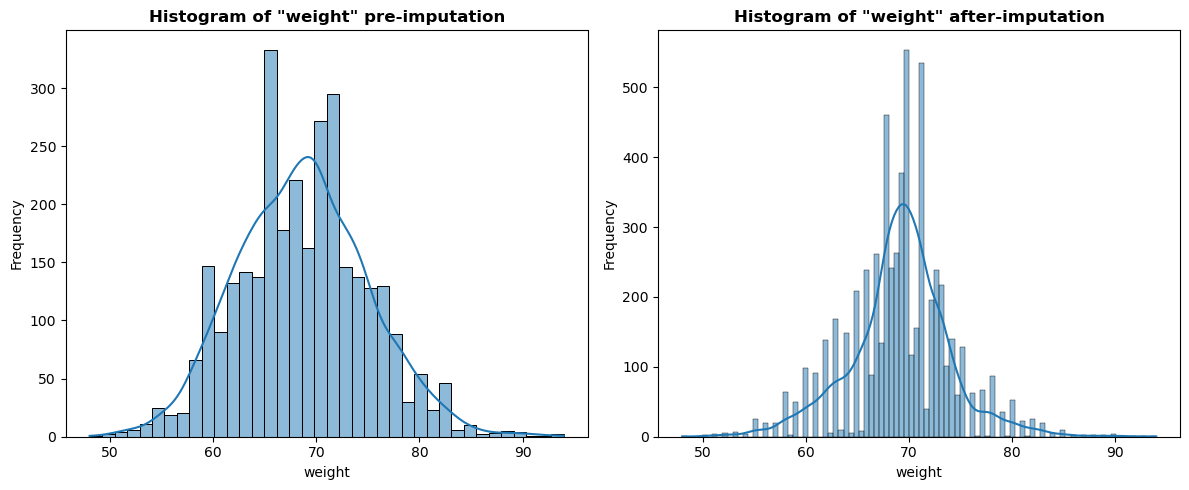

In [84]:
imputationComparison(cyclists_preImputation, cyclists, 'weight')

### Mean considering geo area

In [85]:
cyclists=cyclists_preImputation.copy()
grouped_mean_for_nationality = cyclists.groupby(['geo area'])['weight'].transform('mean')
cyclists['weight']=cyclists['weight'].fillna(grouped_mean_for_nationality)

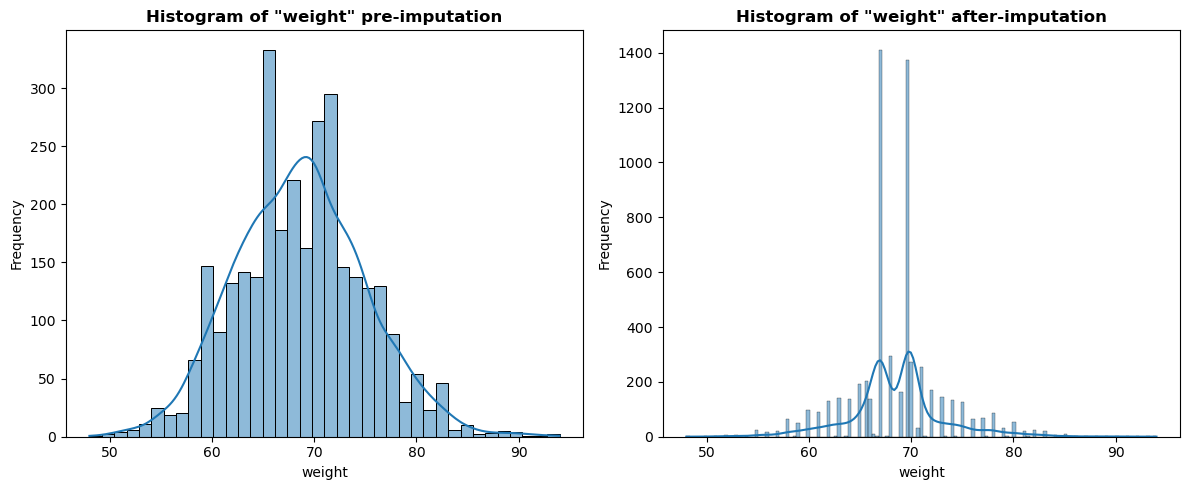

In [86]:
imputationComparison(cyclists_preImputation, cyclists, 'weight')

Also considering the geo area is not a good choice since most of the cyclists belong to the 'Southern europe' and 'Western_europe' area. The two peaks in the right hand size graphs are related to the 2 means for the 2 areas.

### Mean considering geo area and birth year

In [87]:
cyclists=cyclists_preImputation.copy()
grouped_mean_for_nationality = cyclists.groupby(['geo area','birth_year'])['weight'].transform('mean')
cyclists['weight']=cyclists['weight'].fillna(grouped_mean_for_nationality)

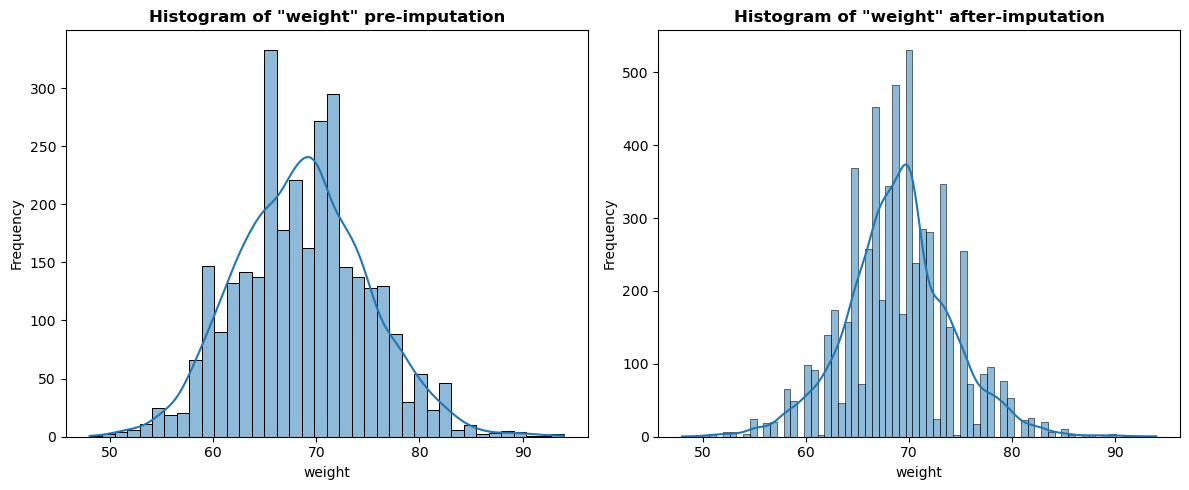

In [88]:
imputationComparison(cyclists_preImputation, cyclists, 'weight')

In [89]:
cyclists[cyclists['weight'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
151,darren-lill,Darren Lill,1982,NaN,<NA>,South Africa,Africa,Africa,<NA>
208,mauro-simonetti,Mauro Simonetti,1948,NaN,<NA>,Italy,Europe,Southern Europe,<NA>
284,ruben-dario-beltran,Ruben Dario Beltran,1964,NaN,<NA>,Colombia,America,America,<NA>
315,oleg-iarochenko,Oleg Iarochenko,1962,NaN,<NA>,Russia,Asia,Asia,<NA>
316,andrei-vedernikov,Andrei Vedernikov,1959,NaN,<NA>,Russia,Asia,Asia,<NA>
...,...,...,...,...,...,...,...,...,...
6047,dariusz-bigos,Dariusz Bigos,1969,NaN,<NA>,Poland,Europe,Eastern Europe,<NA>
6060,juan-santiago-zurano,Juan Santiago Zurano,1948,NaN,<NA>,Spain,Europe,Southern Europe,<NA>
6070,andres-gandarias,Andrés Gandarias,1943,NaN,<NA>,Spain,Europe,Southern Europe,<NA>
6072,sergei-jermachenko,Sergei Jermachenko,<NA>,NaN,<NA>,Russia,Asia,Asia,<NA>


There are rows where there is only one value between weight and height. Perhaps we can use this information to better reconstruct the missing value. However, this could only be applied to 72+8 rows out of about 3000 rows with missing values! So it is not a good strategy.

**Observations:** <br>
As already said the huge number of missing values, around 50%, makes difficult to perform an imputation that does not affect too much the initial distribution of the data. Through various weight imputation tests, we found that using the mean strategy with different group granularity can lead to not so bad approximations of the distribution. In particular, the solution that took into account groups of cyclists with the same 'geo-area' and 'year of birth' seemed to be one of the best. The main problem with these acceptable solutions is the fact that it is not possible to impute all the missing values, because there could be no group matching the fields of the row with the NaN value for the weight (e.g. no cyclist with the same nationality and year of birth as the one who has a NaN). <br>
Let's see if there is a better way of imputing the missing values, exploiting the distribution of the weights. Most of the columns are categorical so using a K-NN strategy is not the best solution.

### Draw random values from a normal distribution
As we have seen in the previous section, the weight follows more or less a gaussian distribution. Hence we can exploit this technique for doing the imputation for the missing values.

In [90]:
cyclists=cyclists_preImputation.copy()

mean=cyclists['weight'].mean()
std_dev=cyclists['weight'].std()

#Generation of random values "fitting" the normal distribution
random_values = np.random.normal(loc=mean, scale=std_dev, size=cyclists['weight'].isna().sum())

cyclists.loc[cyclists['weight'].isna(), 'weight'] = random_values

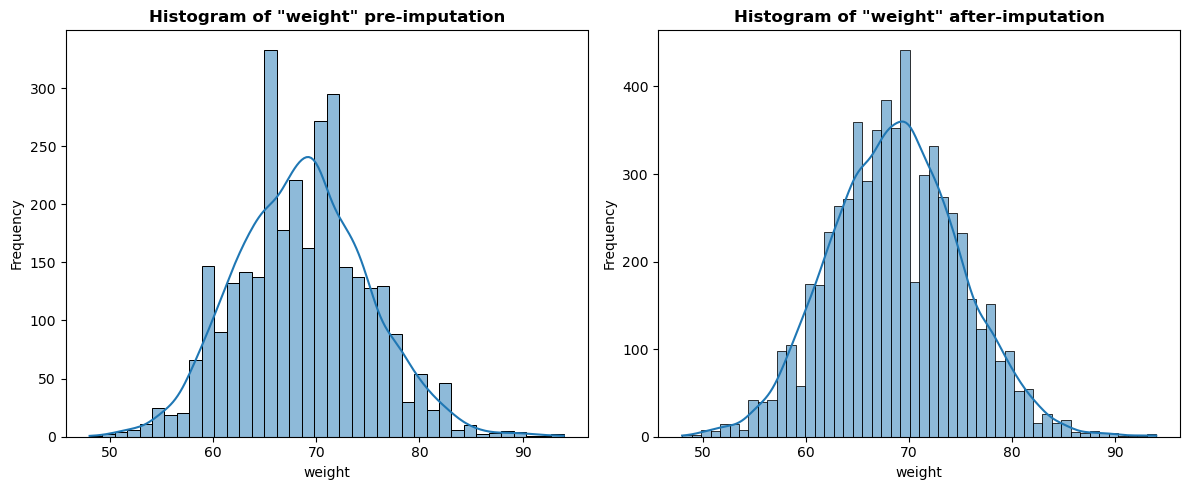

In [91]:
imputationComparison(cyclists_preImputation, cyclists, 'weight')

As we can see the distribution after this imputation strategy, continues to preserve a distribution which is quite similar to the original one.

Description of attribute 'weight':


count    3079.000000
mean       68.658525
std         6.347162
min        48.000000
25%        64.000000
50%        69.000000
75%        73.000000
max        94.000000
Name: weight, dtype: float64


Unique values:
[ nan 74.  69.  78.  55.  67.  71.5 73.  68.  60.  65.  71.  62.  63.
 59.  83.  76.  70.  80.  72.  79.  61.  64.  82.  56.  77.  66.  75.
 58.  53.  57.  91.  81.  88.  85.  84.  86.  67.5 89.  52.  51.  54.
 58.5 48.  90.  63.5 74.5 66.5 78.1 77.5 81.4 50.  87.  62.5 93.  73.5
 79.5 65.1 92.  94. ]

Null values: 3055 over 6134 records - (49.80%)

Top 5 most frequent values:
weight
70.0    272
68.0    220
65.0    193
67.0    177
72.0    169
Name: count, dtype: int64


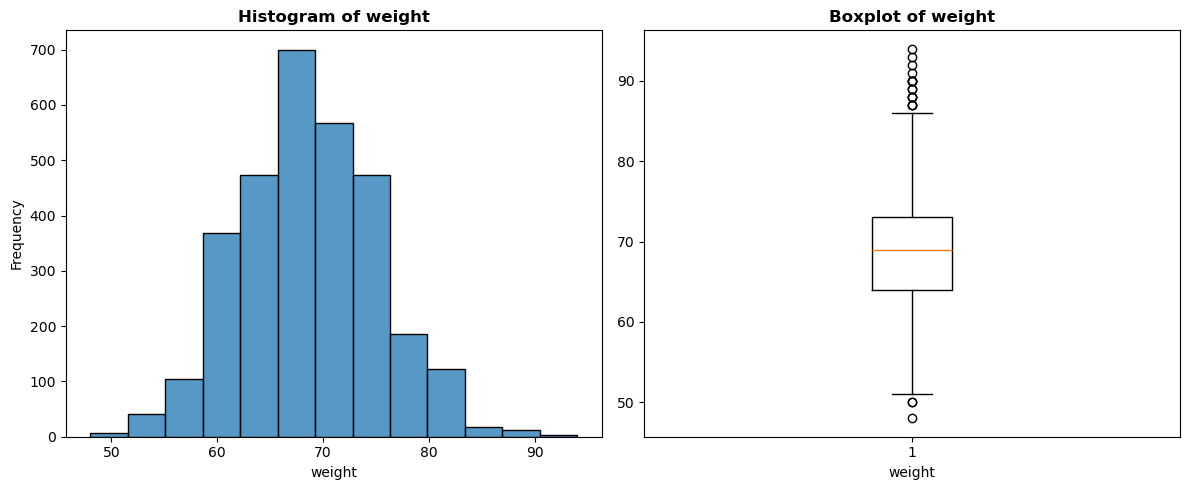

Outliers in weight: [48.0, 50.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0]


In [92]:
stats_and_distribution(cyclists_preImputation,'weight', 'numerical')

Description of attribute 'weight':


count    6134.000000
mean       68.744620
std         6.310985
min        48.000000
25%        64.481801
50%        68.821900
75%        73.000000
max        94.000000
Name: weight, dtype: float64


Unique values:
[71.81125086 74.         69.         ... 66.82706008 63.68391467
 79.67044958]

Null values: 0 over 6134 records - (0.00%)

Top 5 most frequent values:
weight
70.0    272
68.0    220
65.0    193
67.0    177
72.0    169
Name: count, dtype: int64


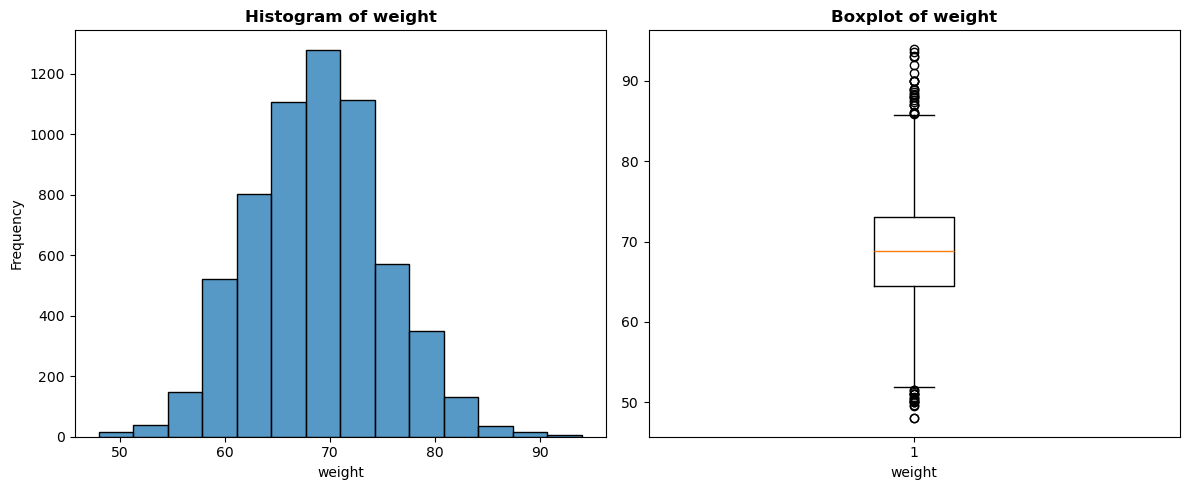

Outliers in weight: [49.67329992590007, 48.085675521045076, 48.0, 50.68237415986677, 50.57836306776993, 51.54094817703051, 51.0, 50.27552245012657, 50.0, 50.427810962721836, 50.11623974300106, 51.500671306001834, 51.219666245965385, 86.17453574800513, 87.37690655005042, 87.6064489928684, 49.4931916738019, 85.92388077068254, 86.0, 87.0, 88.0, 89.0, 88.2006817925814, 91.0, 90.0, 93.11243769452386, 88.92569757727657, 88.57432480066996, 93.0, 88.39768341475354, 92.0, 93.5789935786236, 94.0, 49.99540150699417]


In [93]:
stats_and_distribution(cyclists,'weight', 'numerical')

After imputation, there is a greater concentration of values in the central part of the distribution, so more cases are classified as outliers.

### Draw random values from a normal distribution considering the geo area

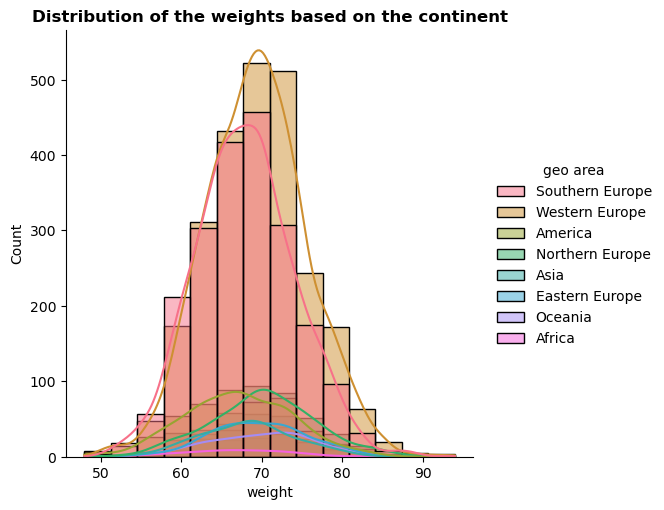

In [94]:
sbn.set_palette("husl", n_colors=8) #8 geo areas
sbn.displot(cyclists, x='weight',kind="hist", row_order="desc", kde=True, bins='sturges', hue='geo area')
plt.title("Distribution of the weights based on the continent", fontweight='bold')
plt.show()
sbn.reset_defaults()
plt.close()

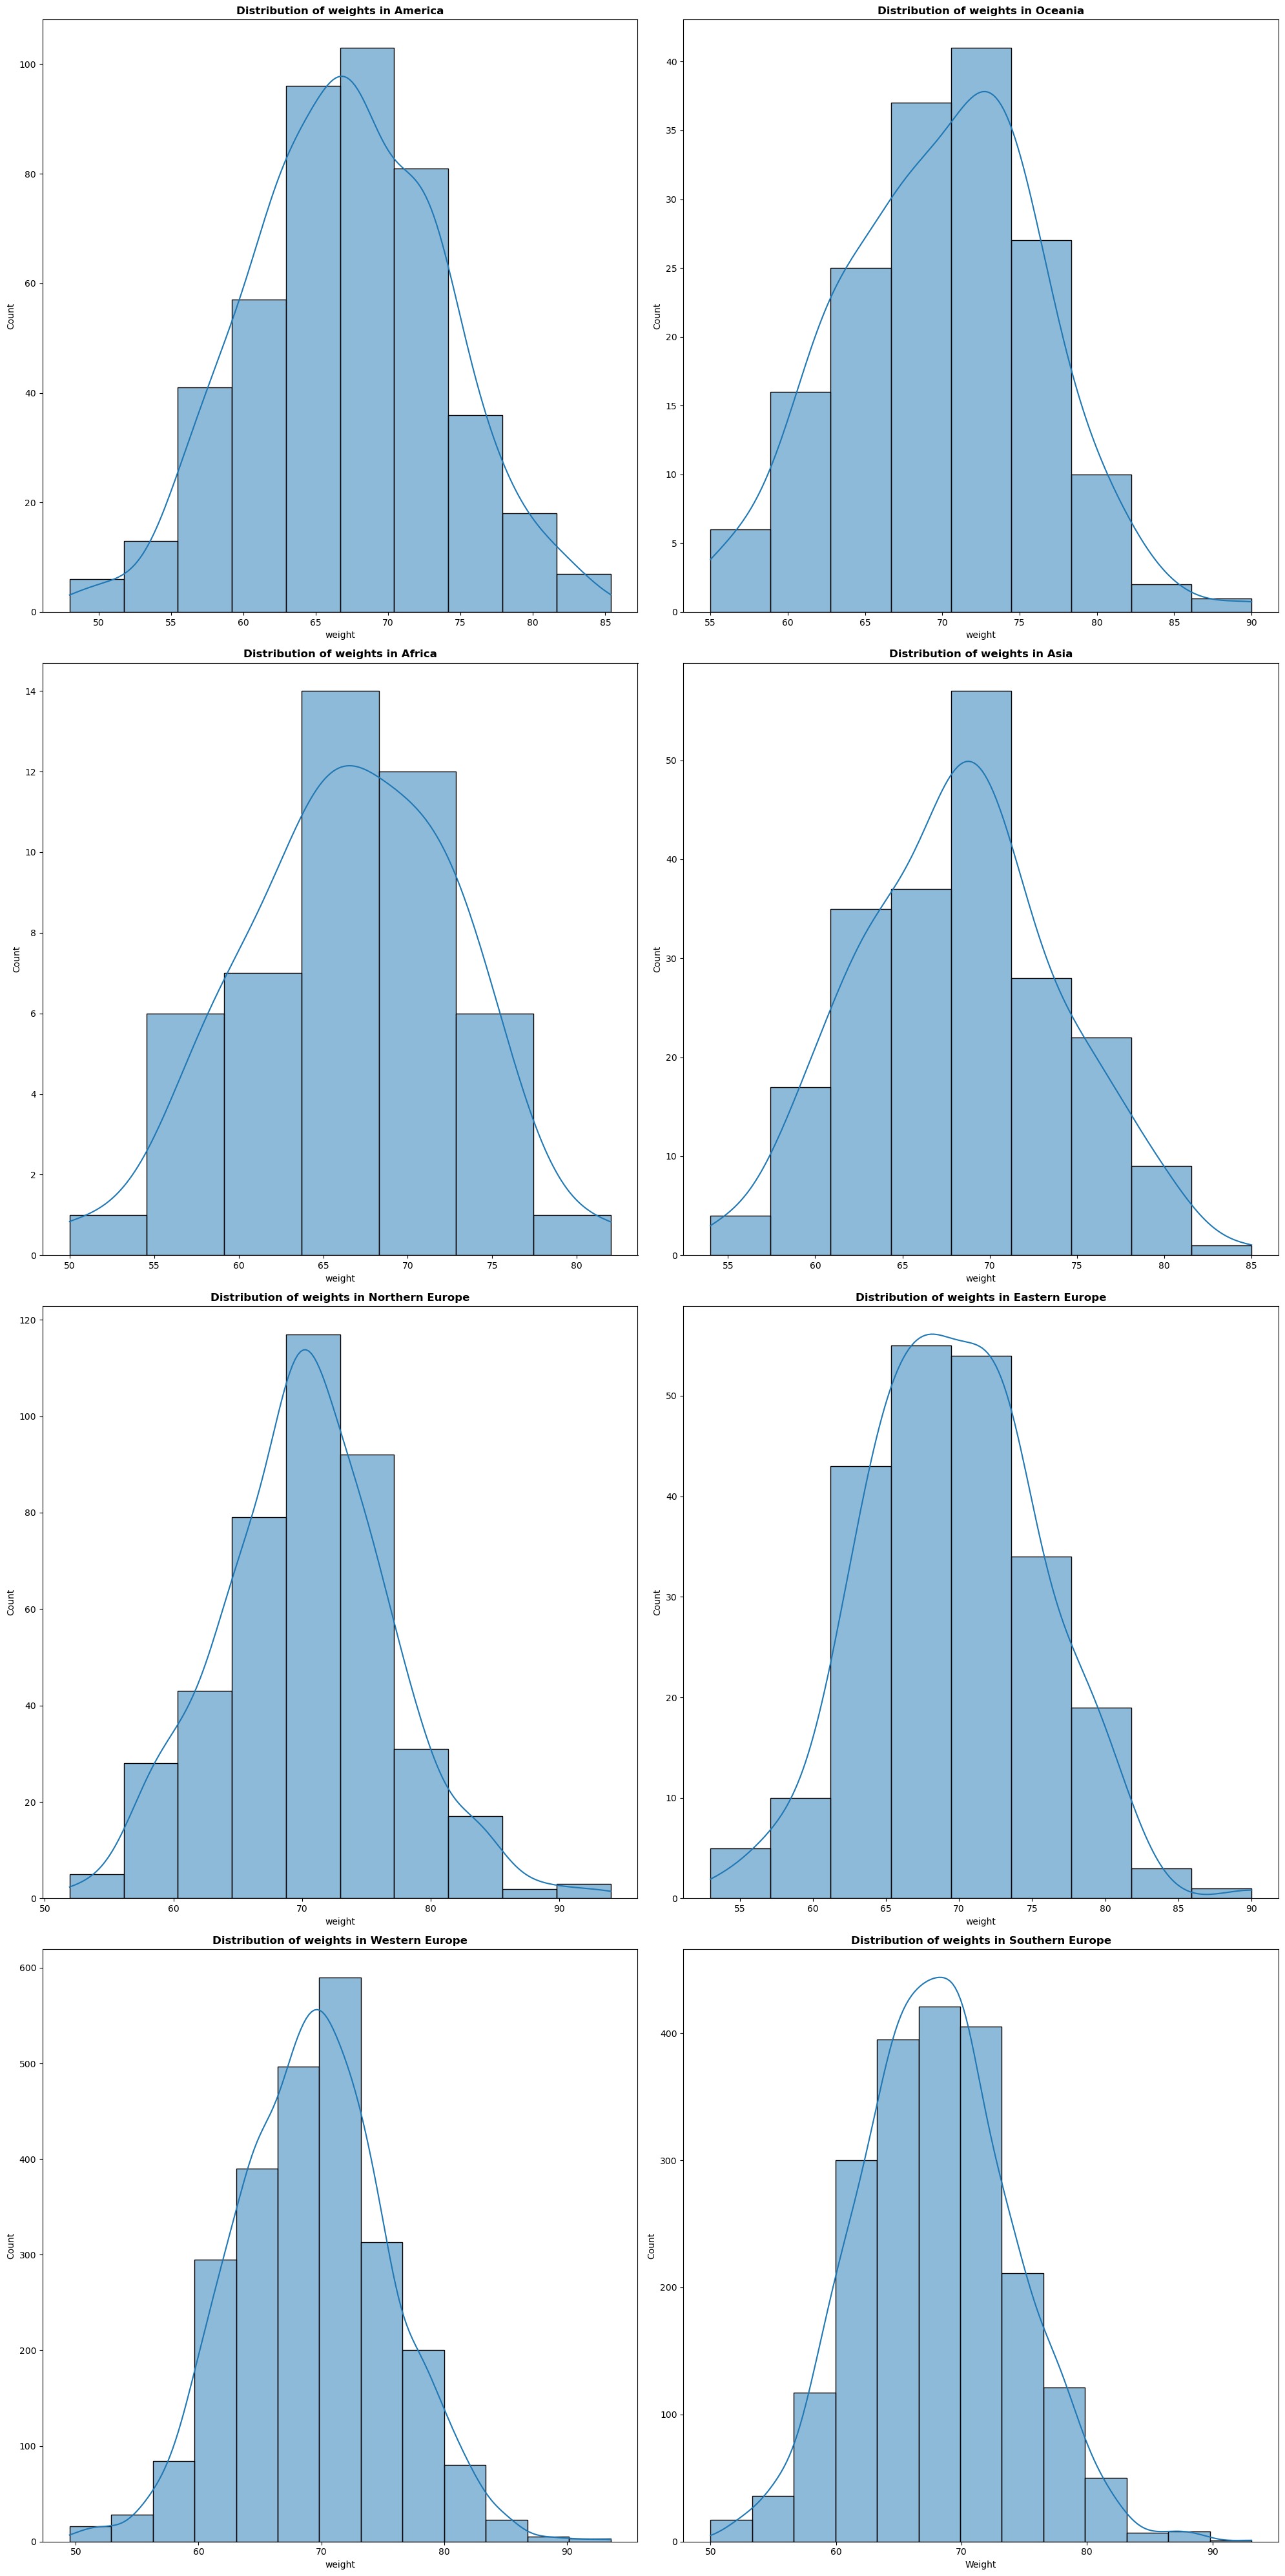

In [95]:
fig, axes = plt.subplots(4, 2, figsize=(20, 40)) 

#geographical area previously defined
regions = ["America", "Oceania", "Africa", "Asia", "Northern Europe", "Eastern Europe", "Western Europe", "Southern Europe"]

#Loop through regions, filter the rows in the cyclists dataset and plot the distribution
for i, region in enumerate(regions):
    region_data = cyclists[cyclists["geo area"] == region]
    sbn.histplot(region_data, x="weight", kde=True, bins="sturges", ax=axes.flat[i])
    axes.flat[i].set_title(f"Distribution of weights in {region}",fontweight='bold')

plt.xlabel("Weight")

plt.tight_layout()
plt.show()

In [96]:
#Print the number of cyclists in each region
for i, region in enumerate(regions):
    region_data = cyclists[cyclists["geo area"] == region]
    print(f"Number of cyclists in {region}: ", region_data.shape[0])

Number of cyclists in America:  458
Number of cyclists in Oceania:  165
Number of cyclists in Africa:  47
Number of cyclists in Asia:  210
Number of cyclists in Northern Europe:  417
Number of cyclists in Eastern Europe:  224
Number of cyclists in Western Europe:  2524
Number of cyclists in Southern Europe:  2089


Number of european cyclists:  5254


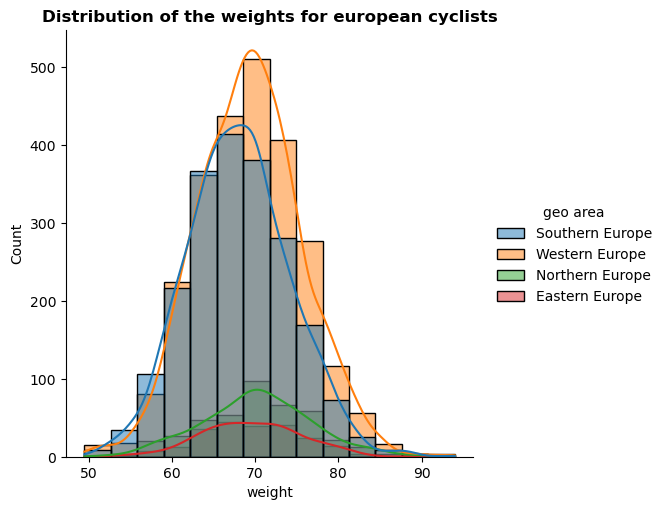

In [97]:
european_cyclists_w=cyclists[cyclists['continent']=="Europe"]
print("Number of european cyclists: ",european_cyclists_w.shape[0])
sbn.displot(european_cyclists_w, x='weight',kind="hist", row_order="desc", kde=True, bins='sturges', hue='geo area')
plt.title("Distribution of the weights for european cyclists", fontweight='bold')
plt.show()
plt.close()

As we can see from the distribution shown above, the weight follows a normal shape even if we consider a division of the cyclists according to the geographical area. So we try again the imputation method based on the random generation, taking into account also the 'geo area' field of the cyclists, in order to mitigate the impact on the mean and standard deviation of the two largest classes "Southern Europe" and "Western Europe".

In [98]:
#Function to apply the np.random.normal imputation on a column, taking into consideration the 
#values of another "class/category" column
def conditional_normal_imputation(dataframe, column_to_be_inputed, label_column):
    # Apply imputation within each group (rows with the same column_value for the feature column_name)
    labels=dataframe[label_column].dropna().unique()
    print("Labels: ",labels)
    for label in labels:
        filtered_dataframe=dataframe[dataframe[label_column]==label]
        #Mean and standard deviation for the values of 'column_to_be_inputed' with a specific label in 'label_column'
        mean_val = filtered_dataframe[column_to_be_inputed].mean()
        std_val = filtered_dataframe[column_to_be_inputed].std()
        print(f"----------")
        print(f"Label '{label}' --> mean {mean_val} standard dev {std_val}")

        # Generate random values for the NaN entries in the 'column_to_be_inputed' for the filtered_dataframe 
        missing_count = filtered_dataframe[column_to_be_inputed].isna().sum()
        print(f"Missing values count for the column {column_to_be_inputed} with label '{label}' --> {missing_count}")
        random_values = np.random.normal(loc=mean_val, scale=std_val, size=missing_count)
        
        # Imputation
        dataframe.loc[(dataframe[label_column] == label) & (dataframe[column_to_be_inputed].isna()), column_to_be_inputed] = random_values

In [99]:
cyclists=cyclists_preImputation.copy()
conditional_normal_imputation(cyclists, 'weight', 'geo area')

Labels:  ['Southern Europe' 'Western Europe' 'America' 'Northern Europe' 'Asia'
 'Eastern Europe' 'Oceania' 'Africa']
----------
Label 'Southern Europe' --> mean 66.91228070175438 standard dev 5.8348084392709785
Missing values count for the column weight with label 'Southern Europe' --> 1234
----------
Label 'Western Europe' --> mean 69.77000821692687 standard dev 6.110277371433603
Missing values count for the column weight with label 'Western Europe' --> 1307
----------
Label 'America' --> mean 65.65490196078431 standard dev 6.553874664675218
Missing values count for the column weight with label 'America' --> 203
----------
Label 'Northern Europe' --> mean 70.86111111111111 standard dev 6.792326179474742
Missing values count for the column weight with label 'Northern Europe' --> 129
----------
Label 'Asia' --> mean 68.13333333333334 standard dev 5.858785977856532
Missing values count for the column weight with label 'Asia' --> 75
----------
Label 'Eastern Europe' --> mean 69.693037974

After the imputation are there NaNs? False


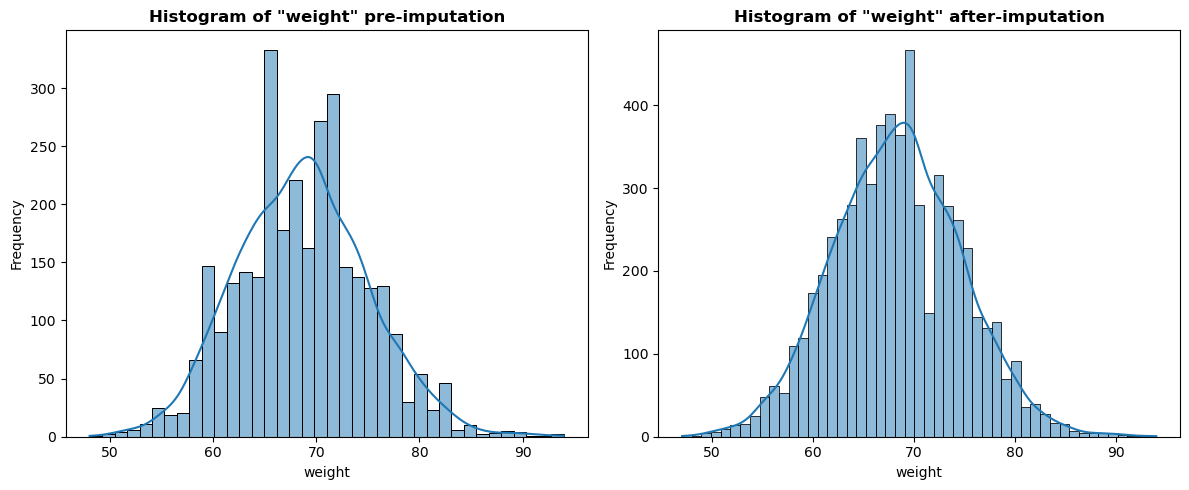

In [100]:
print("After the imputation are there NaNs?",cyclists['weight'].isna().any())
imputationComparison(cyclists_preImputation, cyclists, 'weight')

Description of attribute 'weight':


count    3079.000000
mean       68.658525
std         6.347162
min        48.000000
25%        64.000000
50%        69.000000
75%        73.000000
max        94.000000
Name: weight, dtype: float64


Unique values:
[ nan 74.  69.  78.  55.  67.  71.5 73.  68.  60.  65.  71.  62.  63.
 59.  83.  76.  70.  80.  72.  79.  61.  64.  82.  56.  77.  66.  75.
 58.  53.  57.  91.  81.  88.  85.  84.  86.  67.5 89.  52.  51.  54.
 58.5 48.  90.  63.5 74.5 66.5 78.1 77.5 81.4 50.  87.  62.5 93.  73.5
 79.5 65.1 92.  94. ]

Null values: 3055 over 6134 records - (49.80%)

Top 5 most frequent values:
weight
70.0    272
68.0    220
65.0    193
67.0    177
72.0    169
Name: count, dtype: int64


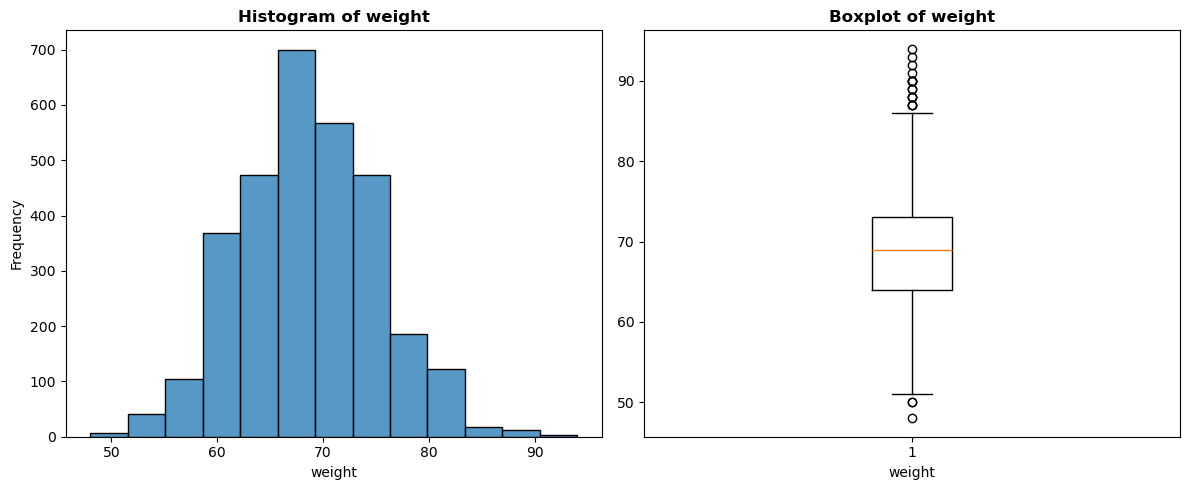

Outliers in weight: [48.0, 50.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0]


In [101]:
stats_and_distribution(cyclists_preImputation,'weight', 'numerical')

Description of attribute 'weight':


count    6134.000000
mean       68.408184
std         6.325244
min        47.087577
25%        64.000000
50%        68.223407
75%        72.801645
max        94.000000
Name: weight, dtype: float64


Unique values:
[61.91317966 74.         69.         ... 64.24207836 67.995738
 75.71777107]

Null values: 0 over 6134 records - (0.00%)

Top 5 most frequent values:
weight
70.0    272
68.0    220
65.0    193
67.0    177
72.0    169
Name: count, dtype: int64


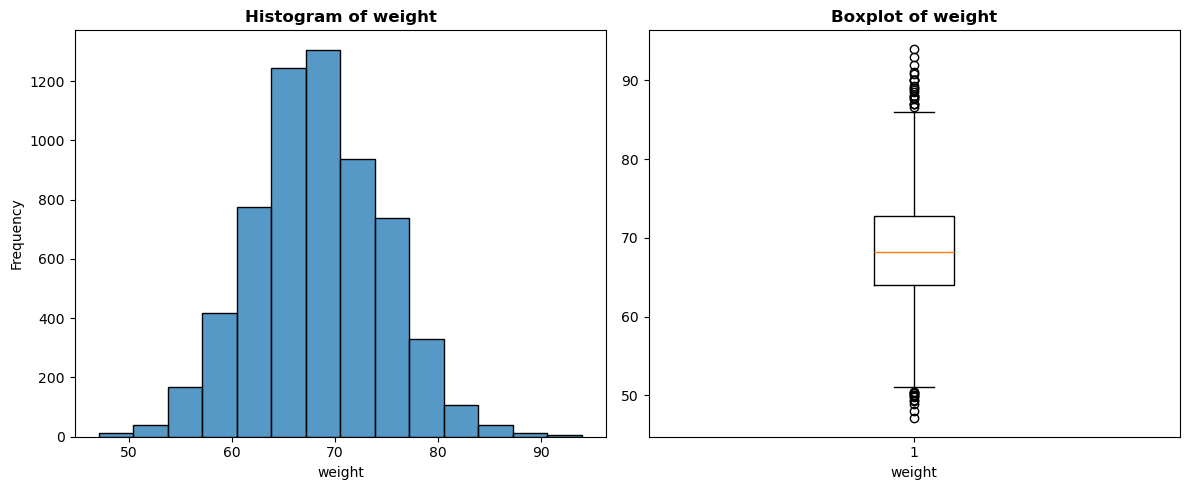

Outliers in weight: [47.08757651796033, 48.919257958201925, 49.95056130679515, 48.0, 49.819508762917835, 50.39782758518045, 50.35946679140851, 50.0, 50.346800579634674, 49.36332214388493, 50.25608095807189, 49.22714604944856, 87.70769226779053, 86.60515284975094, 87.0, 88.0, 89.22095600066162, 89.0, 90.0, 90.74408439461116, 91.0, 88.57047851190163, 88.79075297766988, 87.6008580563265, 93.0, 92.0, 94.0]


In [102]:
stats_and_distribution(cyclists,'weight', 'numerical')

## Height

The two columns with the most missing values are height and weight. Let's try to find a strategy to reconstruct the proper values for that column.

In [103]:
#save the dataset before the imputation to compare the distributions (weight inputed with the last technique)
cyclists_preHeightImputation=cyclists.copy() #Copy used to reset the imputation of the column height

In [104]:
cyclists_preHeightImputation[cyclists_preHeightImputation['height'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
0,bruno-surra,Bruno Surra,1964,61.913180,<NA>,Italy,Europe,Southern Europe,<NA>
6,willy-moonen,Willy Moonen,1947,73.470430,<NA>,Belgium,Europe,Western Europe,<NA>
10,stian-remme,Stian Remme,1982,66.450413,<NA>,Norway,Europe,Northern Europe,<NA>
13,evgueny-anachkine,Evgueny Anachkine,1970,75.052500,<NA>,Russia,Asia,Asia,<NA>
14,maurizio-biondo,Maurizio Biondo,1981,63.670772,<NA>,Italy,Europe,Southern Europe,<NA>
...,...,...,...,...,...,...,...,...,...
6123,francisque-teyssier,Francisque Teyssier,1969,72.108128,<NA>,France,Europe,Western Europe,<NA>
6127,hendrik-van-dyck,Hendrik Van Dyck,1974,59.121188,<NA>,Belgium,Europe,Western Europe,<NA>
6128,francisco-jose-pacheco,Francisco José Pacheco,1982,64.242078,<NA>,Spain,Europe,Southern Europe,<NA>
6129,juan-jose-martinez-diaz,Juan José Martínez,1966,67.995738,<NA>,Spain,Europe,Southern Europe,<NA>


### Simple mean

In [105]:
imputer=SimpleImputer(strategy="mean")
imputer.fit(cyclists[['height']])
cyclists['height']=imputer.transform(cyclists[['height']]).squeeze()

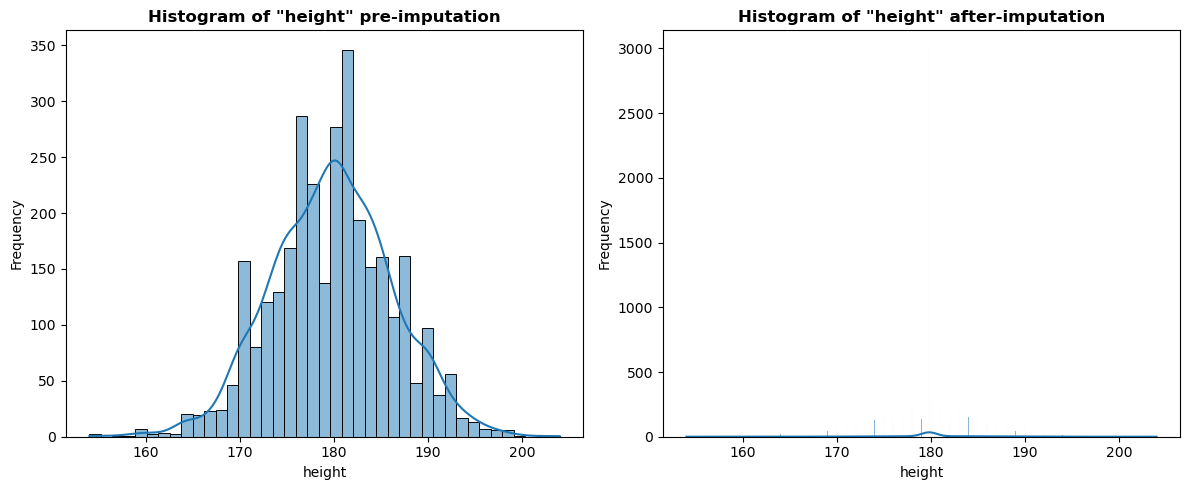

In [106]:
imputationComparison(cyclists_preImputation, cyclists, 'height')

### Mean considering the nationality

In [107]:
cyclists=cyclists_preHeightImputation.copy()
grouped_mean_for_nationality = cyclists.groupby('nationality')['height'].transform(
    lambda x: round(x.mean()) if not pd.isna(x.mean()) else np.nan
) #this .transform lambda is required to properly manage NaN or float mean value in a column of type Int64

cyclists['height']=cyclists['height'].fillna(grouped_mean_for_nationality)

In [108]:
cyclists[cyclists['height'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
102,primoz-cerin,Primož Čerin,1962,76.846128,<NA>,Yugoslavia,Europe,Southern Europe,<NA>
5557,sigmund-hermann,Sigmund Hermann,1959,63.437871,<NA>,Liechtenstein,Europe,Western Europe,<NA>
5707,timothy-jones,Timothy David Jones,1975,61.801839,<NA>,Zimbabwe,Africa,Africa,<NA>


There are 3 rows with still a NaN because there are no other reference rows (with height not NaN) for that nationality.

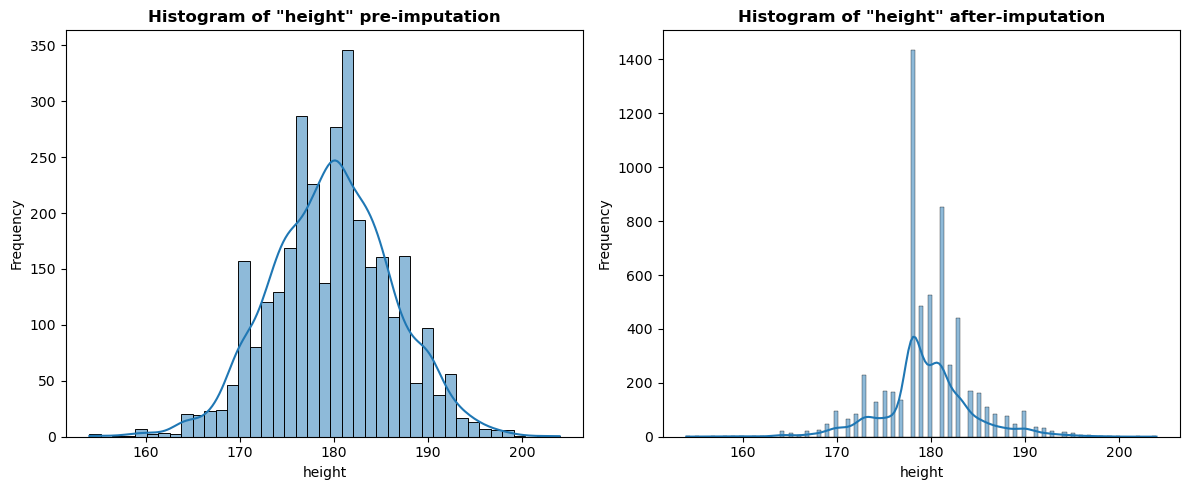

In [109]:
imputationComparison(cyclists_preImputation, cyclists, 'height')

### Mean considering nationality and birth year

In [110]:
cyclists=cyclists_preHeightImputation.copy()
grouped_mean_for_nationality = cyclists.groupby(['nationality', 'birth_year'])['height'].transform(
    lambda x: round(x.mean()) if not pd.isna(x.mean()) else np.nan
) #this .transform lambda is required to properly manage NaN or float mean value in a column of type Int64

cyclists['height']=cyclists['height'].fillna(grouped_mean_for_nationality)

In [111]:
cyclists[cyclists['height'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
10,stian-remme,Stian Remme,1982,66.450413,<NA>,Norway,Europe,Northern Europe,<NA>
26,alain-gallopin,Alain Gallopin,1957,60.702010,<NA>,France,Europe,Western Europe,<NA>
41,gaetano-baronchelli,Gaetano Baronchelli,1952,64.603560,<NA>,Italy,Europe,Southern Europe,<NA>
59,christian-muselet,Christian Muselet,1952,64.927470,<NA>,France,Europe,Western Europe,<NA>
93,paulo-jose-dos-santos-ferreira,Paulo José dos Santos Ferreira,1962,68.226654,<NA>,Portugal,Europe,Southern Europe,<NA>
...,...,...,...,...,...,...,...,...,...
6080,batik-odriozola,Batik Odriozola,<NA>,63.420512,<NA>,Spain,Europe,Southern Europe,<NA>
6087,erwin-biets,Erwin Biets,1968,76.903817,<NA>,Belgium,Europe,Western Europe,<NA>
6093,raul-alexander-montana-herrera,Raúl Alexander Montaña,1971,68.998193,<NA>,Colombia,America,America,<NA>
6096,frans-van-vlierberghe,Frans Van Vlierberghe,1954,65.832910,<NA>,Belgium,Europe,Western Europe,<NA>


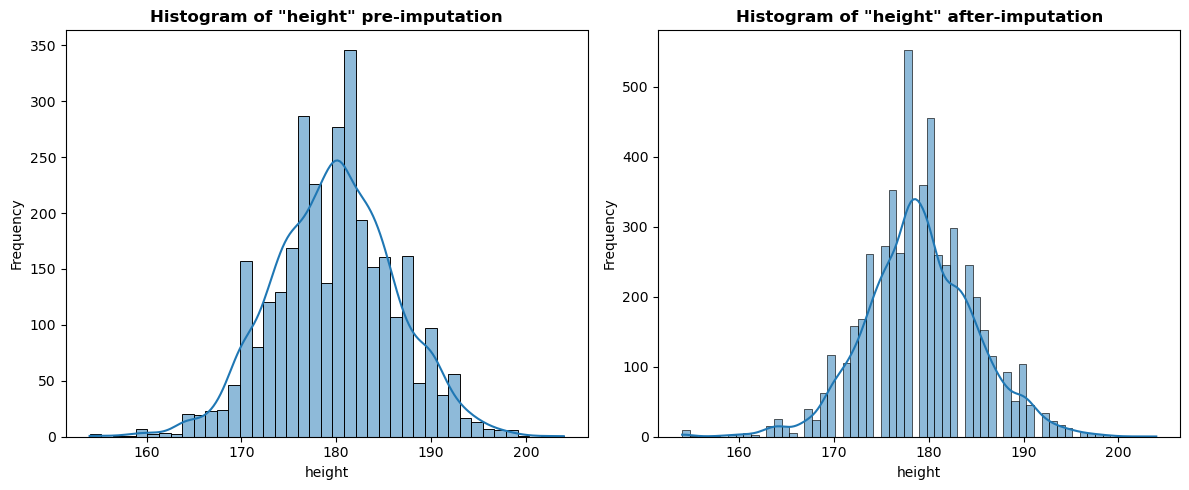

In [112]:
imputationComparison(cyclists_preImputation, cyclists, 'height')

### Mean considering continent

In [113]:
cyclists=cyclists_preHeightImputation.copy()
grouped_mean_for_nationality = cyclists.groupby('continent')['height'].transform(
    lambda x: round(x.mean()) if not pd.isna(x.mean()) else np.nan
) #this .transform lambda is required to properly manage NaN or float mean value in a column of type Int64

cyclists['height']=cyclists['height'].fillna(grouped_mean_for_nationality)

In [114]:
cyclists[cyclists['height'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI


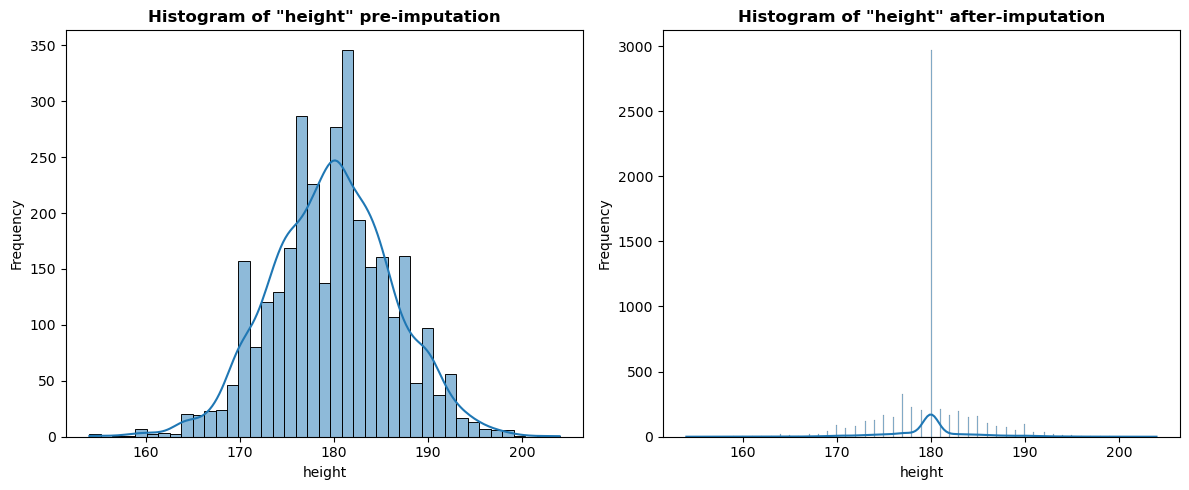

In [115]:
imputationComparison(cyclists_preImputation, cyclists, 'height')

Not a good choice because it is affected by the high number of rows related to european cyclists.

### Mean considering continent and birth year

In [116]:
cyclists=cyclists_preHeightImputation.copy()
grouped_mean_for_nationality = cyclists.groupby(['continent', 'birth_year'])['height'].transform(
    lambda x: round(x.mean()) if not pd.isna(x.mean()) else np.nan
) #this .transform lambda is required to properly manage NaN or float mean value in a column of type Int64
cyclists['height']=cyclists['height'].fillna(grouped_mean_for_nationality)

In [117]:
cyclists[cyclists['height'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
151,darren-lill,Darren Lill,1982,62.666118,<NA>,South Africa,Africa,Africa,<NA>
284,ruben-dario-beltran,Ruben Dario Beltran,1964,64.253191,<NA>,Colombia,America,America,<NA>
315,oleg-iarochenko,Oleg Iarochenko,1962,62.469634,<NA>,Russia,Asia,Asia,<NA>
316,andrei-vedernikov,Andrei Vedernikov,1959,63.469364,<NA>,Russia,Asia,Asia,<NA>
384,asiat-saitov,Asiat Saitov,1965,68.736304,<NA>,Russia,Asia,Asia,<NA>
...,...,...,...,...,...,...,...,...,...
5968,nathan-dahlberg,Nathan Dahlberg,1964,66.284724,<NA>,New Zealand,Oceania,Oceania,<NA>
5975,victor-demidenko,Víctor Demidenko,1962,61.606169,<NA>,Russia,Asia,Asia,<NA>
5988,eric-heiden,Eric Heiden,1958,67.604431,<NA>,United States,America,America,<NA>
6072,sergei-jermachenko,Sergei Jermachenko,<NA>,62.614004,<NA>,Russia,Asia,Asia,<NA>


There are still rows with NaN.

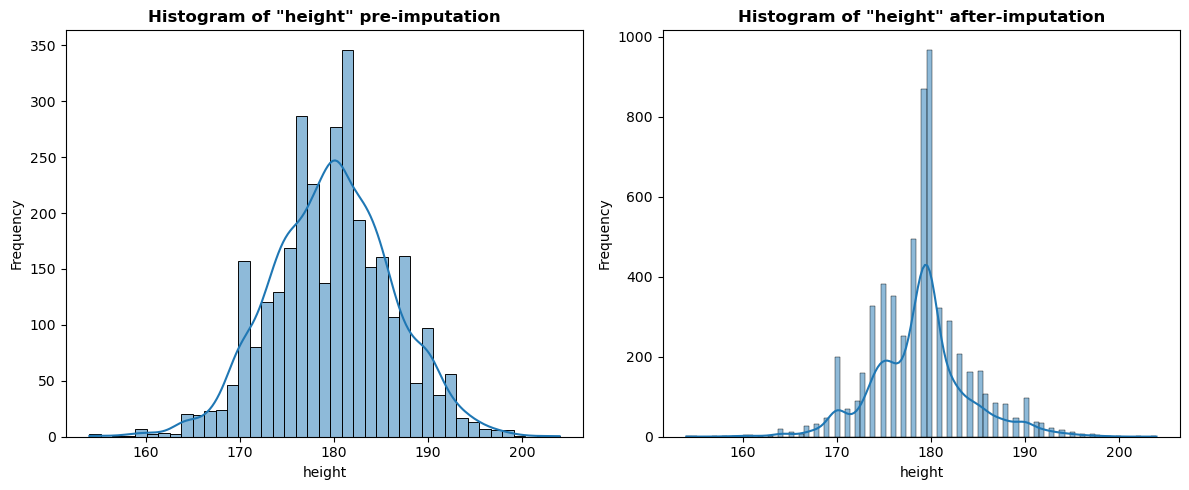

In [118]:
imputationComparison(cyclists_preImputation, cyclists, 'height')

### Mean considering geo area

In [119]:
cyclists=cyclists_preHeightImputation.copy()
grouped_mean_for_nationality = cyclists.groupby('geo area')['height'].transform(
    lambda x: round(x.mean()) if not pd.isna(x.mean()) else np.nan
) #this .transform lambda is required to properly manage NaN or float mean value in a column of type Int64

cyclists['height']=cyclists['height'].fillna(grouped_mean_for_nationality)

In [120]:
cyclists[cyclists['height'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI


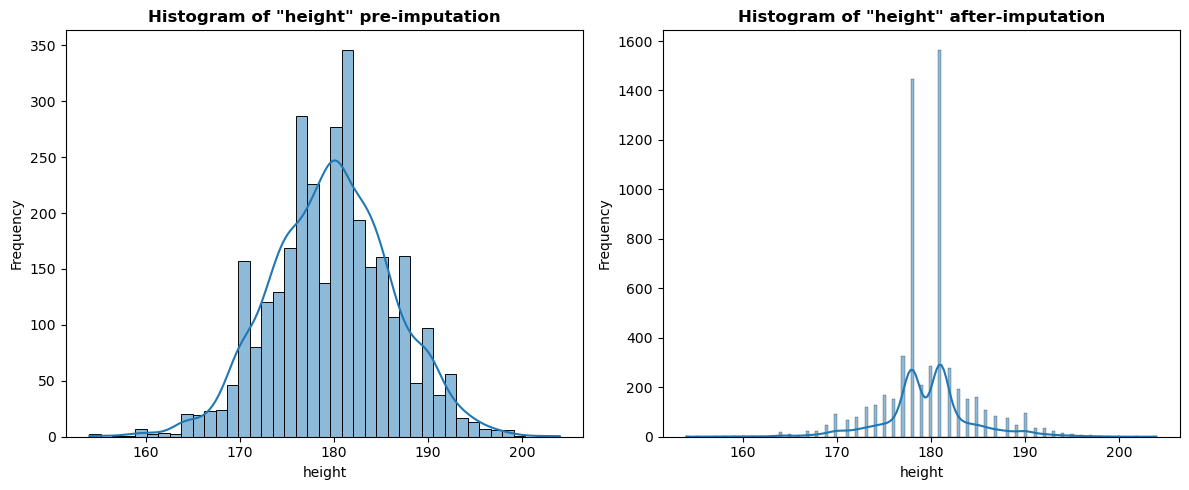

In [121]:
imputationComparison(cyclists_preImputation, cyclists, 'height')

Also considering the geo area is not a good choice since most of the cyclists belong to the 'Southern europe' and 'Western_europe' area. The two peaks in the right hand size graphs are related to the 2 means for the 2 areas.

### Mean considering geo area and birth year

In [122]:
cyclists=cyclists_preHeightImputation.copy()
grouped_mean_for_nationality = cyclists.groupby(['geo area', 'birth_year'])['height'].transform(
    lambda x: round(x.mean()) if not pd.isna(x.mean()) else np.nan
) #this .transform lambda is required to properly manage NaN or float mean value in a column of type Int64

cyclists['height']=cyclists['height'].fillna(grouped_mean_for_nationality)

In [123]:
cyclists[cyclists['height'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI
151,darren-lill,Darren Lill,1982,62.666118,<NA>,South Africa,Africa,Africa,<NA>
208,mauro-simonetti,Mauro Simonetti,1948,69.360625,<NA>,Italy,Europe,Southern Europe,<NA>
284,ruben-dario-beltran,Ruben Dario Beltran,1964,64.253191,<NA>,Colombia,America,America,<NA>
315,oleg-iarochenko,Oleg Iarochenko,1962,62.469634,<NA>,Russia,Asia,Asia,<NA>
316,andrei-vedernikov,Andrei Vedernikov,1959,63.469364,<NA>,Russia,Asia,Asia,<NA>
...,...,...,...,...,...,...,...,...,...
6047,dariusz-bigos,Dariusz Bigos,1969,76.328776,<NA>,Poland,Europe,Eastern Europe,<NA>
6060,juan-santiago-zurano,Juan Santiago Zurano,1948,72.335210,<NA>,Spain,Europe,Southern Europe,<NA>
6070,andres-gandarias,Andrés Gandarias,1943,60.612226,<NA>,Spain,Europe,Southern Europe,<NA>
6072,sergei-jermachenko,Sergei Jermachenko,<NA>,62.614004,<NA>,Russia,Asia,Asia,<NA>


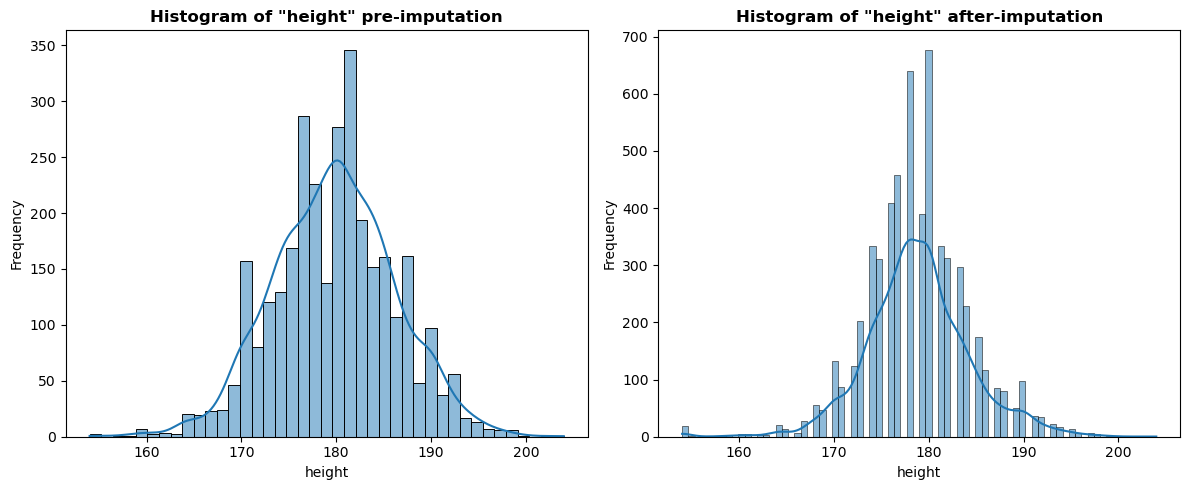

In [124]:
imputationComparison(cyclists_preImputation, cyclists, 'height')

**Observations:** <br>
As already said the huge number of missing values, around 50%, makes difficult to perform an imputation that does not affect too much the initial distribution of the data. Through various weight imputation tests, we found that using the mean strategy with different group granularity can lead to not so bad approximations of the distribution. In particular, the solution that took into account groups of cyclists with the same 'geo-area' and 'year of birth' seemed to be one of the best. The main problem with these acceptable solutions is the fact that it is not possible to impute all the missing values, because there could be no group matching the fields of the row with the NaN value for the weight (e.g. no cyclist with the same nationality and year of birth as the one who has a NaN). <br>
Let's see if there is a better way of imputing the missing values, exploiting the distribution of the heights. Most of the columns are categorical so using a K-NN strategy is not the best solution.

### Draw random values from a normal distribution
As we have seen in the previous section, the height follows more or less a gaussian distribution. Hence we can exploit this technique for doing the imputation for the missing values.

In [125]:
cyclists=cyclists_preHeightImputation.copy()

mean=cyclists['height'].mean()
std_dev=cyclists['height'].std()

#Generation of random values "fitting" the normal distribution
random_values = np.round(np.random.normal(loc=mean, scale=std_dev, size=cyclists['height'].isna().sum()))

cyclists.loc[cyclists['height'].isna(), 'height'] = random_values

In [126]:
cyclists[cyclists['height'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI


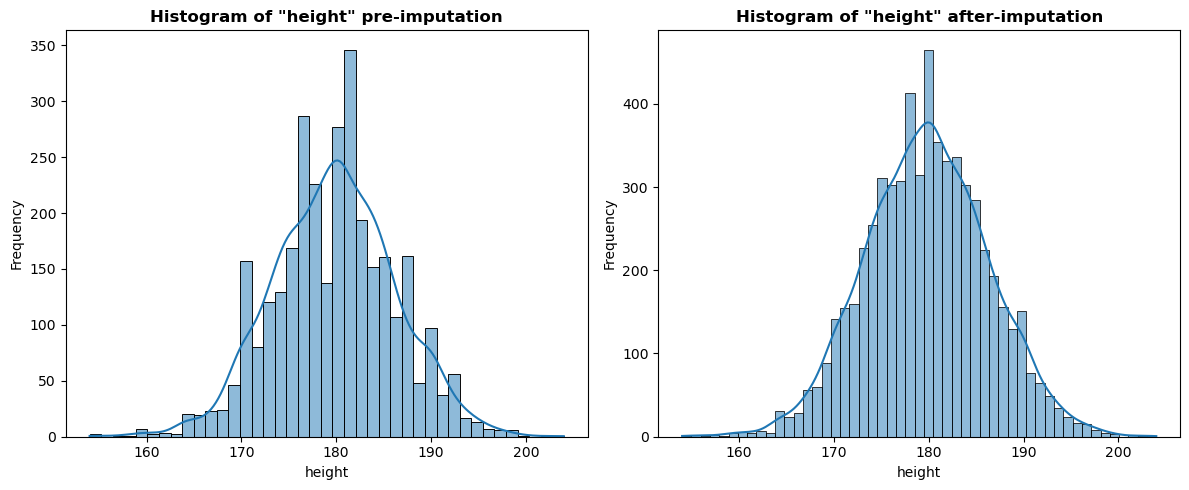

In [127]:
imputationComparison(cyclists_preImputation, cyclists, 'height')

We can notice that this strategy had an impact on the initial distribution, making the final shape more simmetric.

Description of attribute 'height':


count        3144.0
mean     179.816158
std        6.442673
min           154.0
25%           175.0
50%           180.0
75%           184.0
max           204.0
Name: height, dtype: Float64


Unique values:
<IntegerArray>
[<NA>,  182,  189,  192,  171,  177,  191,  183,  175,  178,  181,  172,  174,
  180,  164,  170,  184,  185,  186,  190,  179,  193,  167,  173,  176,  166,
  187,  188,  195,  169,  198,  194,  168,  199,  204,  154,  165,  159,  160,
  196,  162,  161,  163,  155,  158,  197,  202,  157,  200]
Length: 49, dtype: Int64

Null values: 2990 over 6134 records - (48.74%)

Top 5 most frequent values:
height
180    277
178    226
183    194
181    181
175    169
Name: count, dtype: Int64


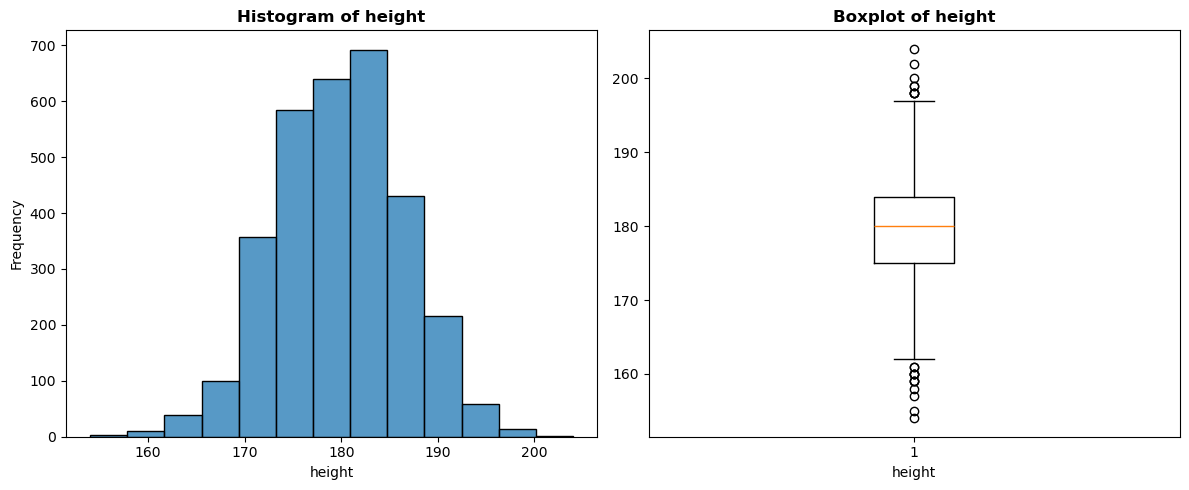

Outliers in height: [160, 161, 198, 199, 200, 202, 204, 154, 155, 157, 158, 159]


In [128]:
stats_and_distribution(cyclists_preImputation, 'height', 'numerical')

Description of attribute 'height':


count        6134.0
mean     179.813825
std        6.523014
min           154.0
25%           175.0
50%           180.0
75%           184.0
max           204.0
Name: height, dtype: Float64


Unique values:
<IntegerArray>
[187, 182, 189, 192, 171, 177, 172, 191, 183, 175, 178, 174, 181, 173, 185,
 180, 164, 170, 184, 179, 186, 190, 193, 167, 176, 166, 188, 195, 169, 162,
 198, 197, 194, 168, 199, 165, 163, 204, 154, 196, 159, 160, 161, 203, 155,
 200, 158, 156, 157, 202]
Length: 50, dtype: Int64

Null values: 0 over 6134 records - (0.00%)

Top 5 most frequent values:
height
180    465
178    413
181    354
183    336
182    331
Name: count, dtype: Int64


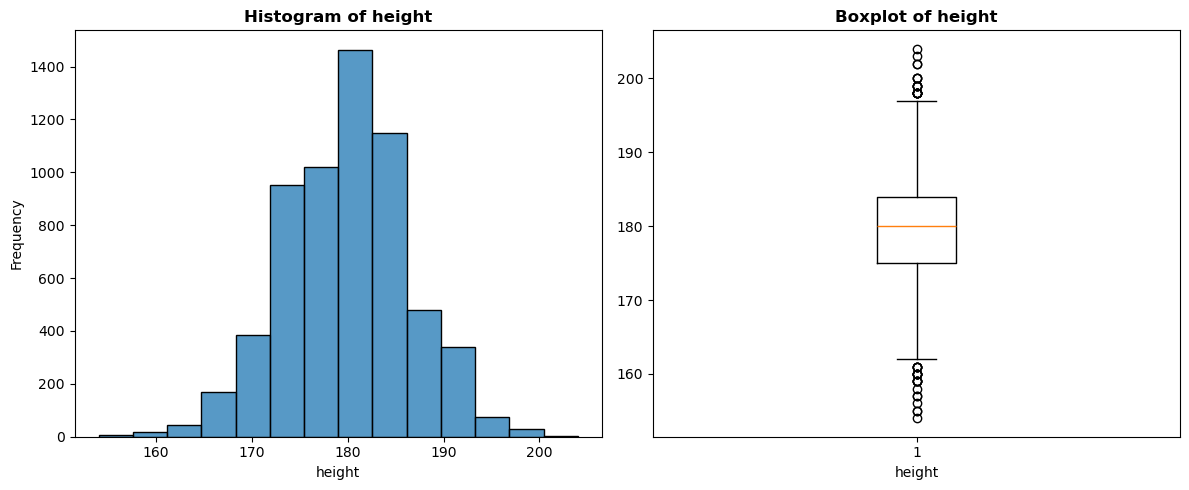

Outliers in height: [160, 161, 198, 199, 200, 202, 203, 204, 154, 155, 156, 157, 158, 159]


In [129]:
stats_and_distribution(cyclists, 'height', 'numerical')

Notice that the **np.random.normal** procedure produces float values and we do a cast to Int64; this approximation may have an impact on the final distribution of the height. <br>
Let's see if the situation is better if we consider different distributions according the geo area.

### Draw random values from a normal distribution considering the geo area

Let us see if we can obtain a better result if we use the same strategy as above, but "segmented" on the geo area field.

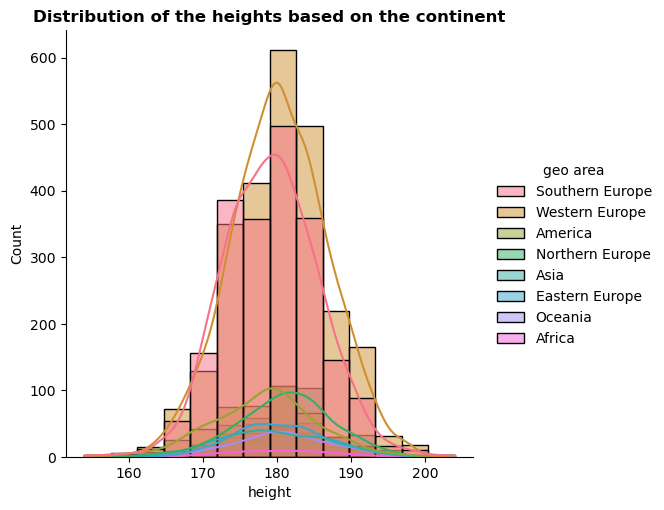

In [130]:
sbn.set_palette("husl", n_colors=8) #8 geo areas
sbn.displot(cyclists, x='height',kind="hist", row_order="desc", kde=True, bins='sturges', hue='geo area')
plt.title("Distribution of the heights based on the continent", fontweight='bold')
plt.show()
sbn.reset_defaults()
plt.close()

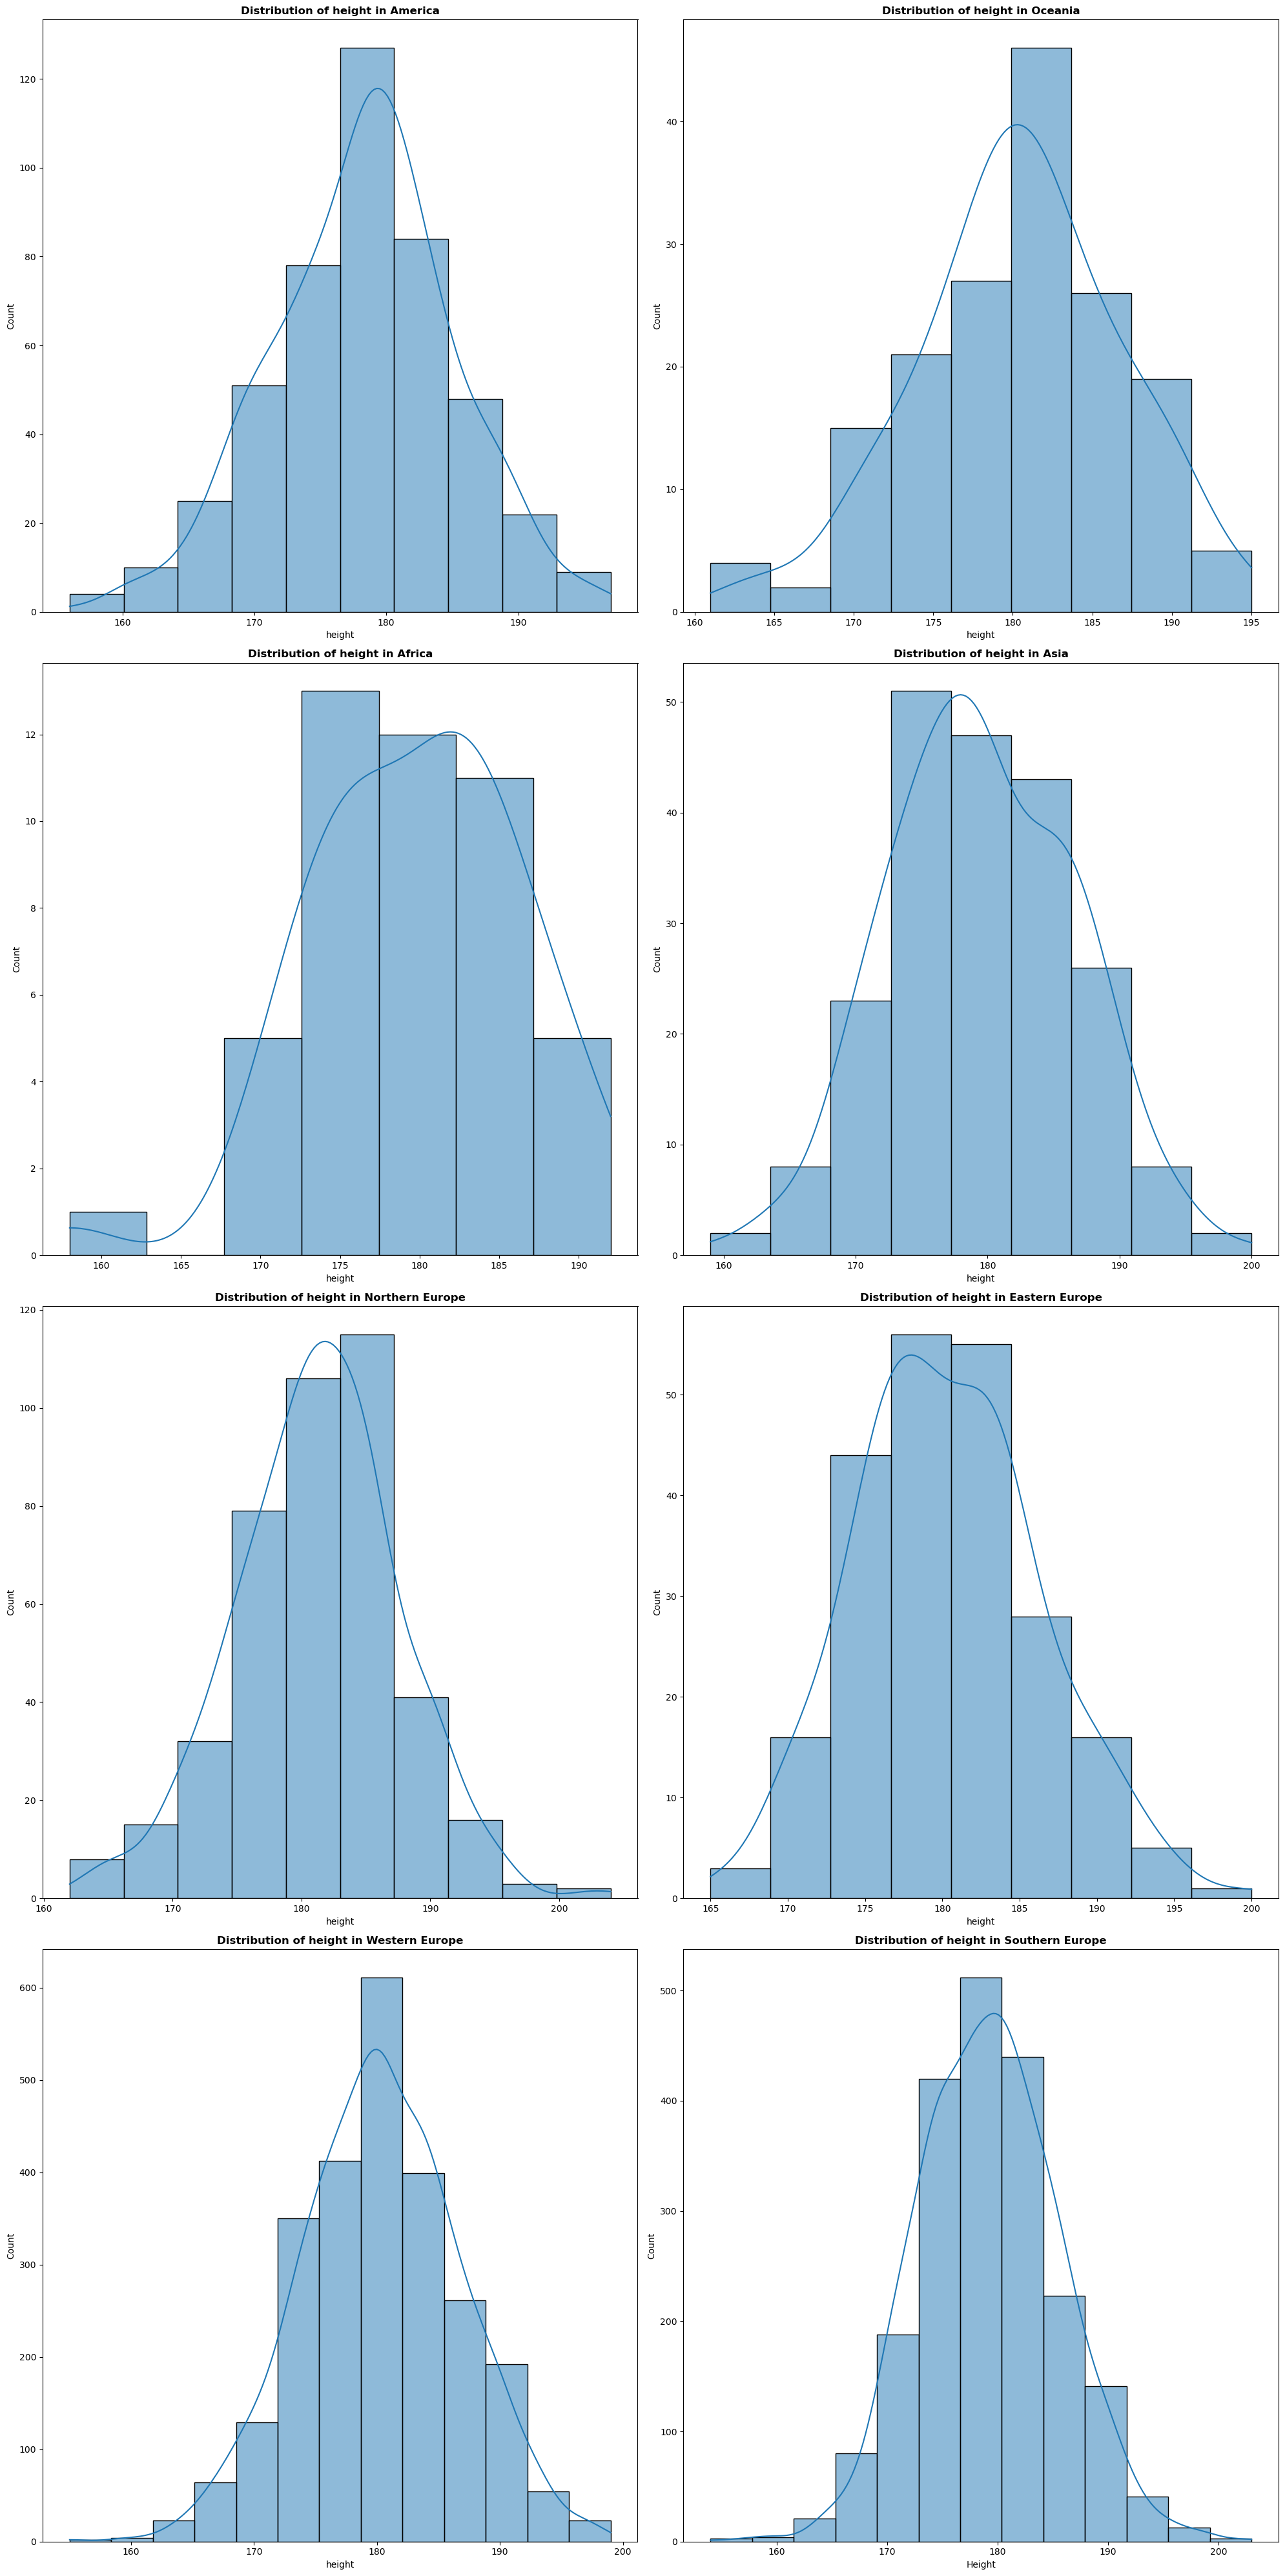

In [131]:
fig, axes = plt.subplots(4, 2, figsize=(20, 40))

#we use the geographical areas previously defined
#Loop through regions, filter the rows in the cyclists dataset and plot the distribution
for i, region in enumerate(regions):
    region_data = cyclists[cyclists["geo area"] == region]
    sbn.histplot(region_data, x="height", kde=True, bins="sturges", ax=axes.flat[i])
    axes.flat[i].set_title(f"Distribution of height in {region}", fontweight='bold')
plt.xlabel("Height")
plt.tight_layout()
plt.show()

The shape of this distribution of african cyclists is influenced by the number of bins, here calculated using the sturges rule, and by the small number of rows related to african cyclists.

In [132]:
#Print the number of cyclists in each region
for i, region in enumerate(regions):
    region_data = cyclists[cyclists["geo area"] == region]
    print(f"Number of cyclists in {region}: ", region_data.shape[0])

Number of cyclists in America:  458
Number of cyclists in Oceania:  165
Number of cyclists in Africa:  47
Number of cyclists in Asia:  210
Number of cyclists in Northern Europe:  417
Number of cyclists in Eastern Europe:  224
Number of cyclists in Western Europe:  2524
Number of cyclists in Southern Europe:  2089


Number of european cyclists:  5254


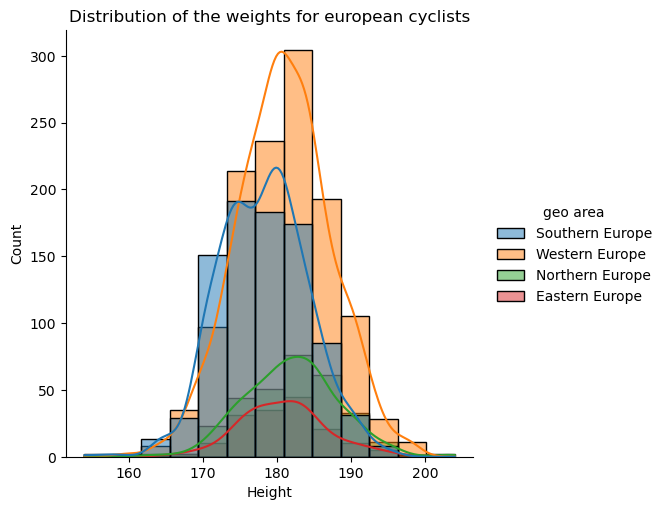

In [133]:
print("Number of european cyclists: ",european_cyclists_w.shape[0])
sbn.displot(european_cyclists_w, x='height',kind="hist", row_order="desc", kde=True, bins='sturges', hue='geo area')
plt.title("Distribution of the weights for european cyclists")
plt.xlabel("Height")
plt.show()
plt.close()

We try again the imputation method based on the random generation, taking into account also the 'geo area' field of the cyclists, in order to mitigate the impact on the mean and standard deviation of the two largest classes "Southern Europe" and "Western Europe".

In [134]:
#Function to apply the np.random.normal imputation on a column, taking into consideration the 
#values of another "class/category" column
def conditional_int_normal_imputation(dataframe, column_to_be_inputed, label_column):
    # Apply imputation within each group (rows with the same column_value for the feature column_name)
    labels=dataframe[label_column].dropna().unique()
    print("Labels: ",labels)
    for label in labels:
        filtered_dataframe=dataframe[dataframe[label_column]==label]
        #Mean and standard deviation for the values of 'column_to_be_inputed' with a specific label in 'label_column'
        mean_val = filtered_dataframe[column_to_be_inputed].mean()
        std_val = filtered_dataframe[column_to_be_inputed].std()
        print(f"----------")
        print(f"Label '{label}' --> mean {mean_val} standard dev {std_val}")

        # Generate random values for the NaN entries in the 'column_to_be_inputed' for the filtered_dataframe 
        missing_count = filtered_dataframe[column_to_be_inputed].isna().sum()
        print(f"Missing values count for the column {column_to_be_inputed} with label '{label}' --> {missing_count}")
        random_values = np.round(np.random.normal(loc=mean_val, scale=std_val, size=missing_count))
        
        # Imputation
        dataframe.loc[(dataframe[label_column] == label) & (dataframe[column_to_be_inputed].isna()), column_to_be_inputed] = random_values

In [135]:
cyclists=cyclists_preHeightImputation.copy()
conditional_int_normal_imputation(cyclists, 'height', 'geo area')

Labels:  ['Southern Europe' 'Western Europe' 'America' 'Northern Europe' 'Asia'
 'Eastern Europe' 'Oceania' 'Africa']
----------
Label 'Southern Europe' --> mean 178.19009216589862 standard dev 5.920624011719613
Missing values count for the column height with label 'Southern Europe' --> 1221
----------
Label 'Western Europe' --> mean 180.88492706645056 standard dev 6.325302863951284
Missing values count for the column height with label 'Western Europe' --> 1290
----------
Label 'America' --> mean 177.09056603773584 standard dev 7.006443575190414
Missing values count for the column height with label 'America' --> 193
----------
Label 'Northern Europe' --> mean 181.99344262295082 standard dev 6.214897976585095
Missing values count for the column height with label 'Northern Europe' --> 112
----------
Label 'Asia' --> mean 178.6978417266187 standard dev 6.775547120813361
Missing values count for the column height with label 'Asia' --> 71
----------
Label 'Eastern Europe' --> mean 180.90683

After the imputation are there NaNs? False


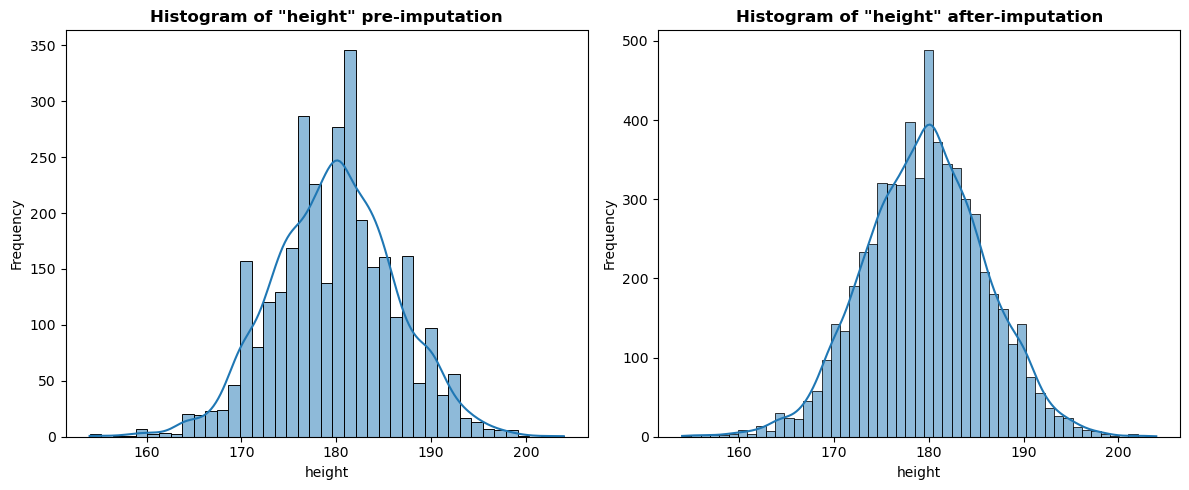

In [136]:
print("After the imputation are there NaNs?",cyclists['height'].isna().any())
imputationComparison(cyclists_preImputation, cyclists, 'height')

Imputation seems to have artificially increased the concentration around the mean, reduced the variance.

Description of attribute 'height':


count        3144.0
mean     179.816158
std        6.442673
min           154.0
25%           175.0
50%           180.0
75%           184.0
max           204.0
Name: height, dtype: Float64


Unique values:
<IntegerArray>
[<NA>,  182,  189,  192,  171,  177,  191,  183,  175,  178,  181,  172,  174,
  180,  164,  170,  184,  185,  186,  190,  179,  193,  167,  173,  176,  166,
  187,  188,  195,  169,  198,  194,  168,  199,  204,  154,  165,  159,  160,
  196,  162,  161,  163,  155,  158,  197,  202,  157,  200]
Length: 49, dtype: Int64

Null values: 2990 over 6134 records - (48.74%)

Top 5 most frequent values:
height
180    277
178    226
183    194
181    181
175    169
Name: count, dtype: Int64


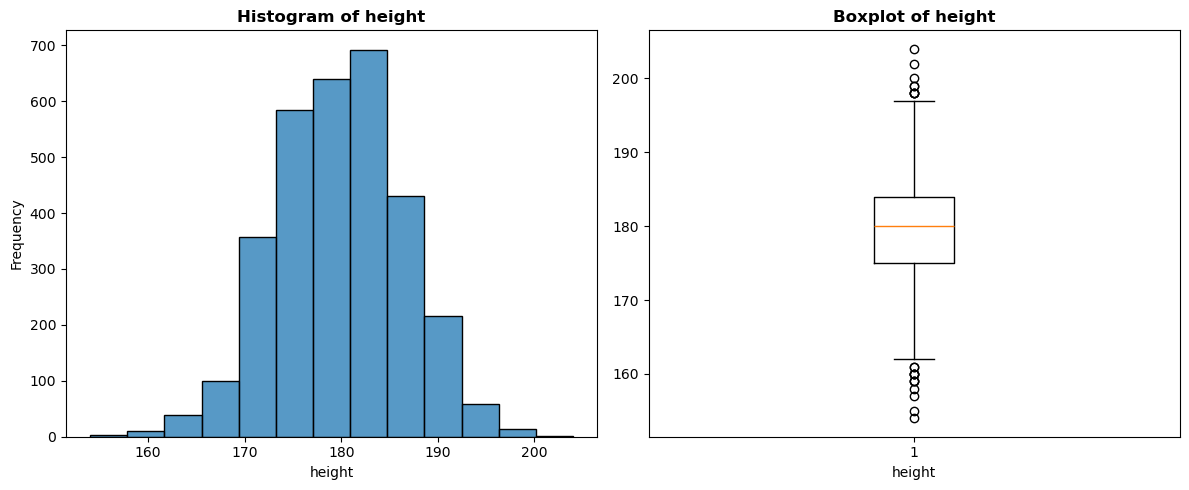

Outliers in height: [160, 161, 198, 199, 200, 202, 204, 154, 155, 157, 158, 159]


In [137]:
stats_and_distribution(cyclists_preImputation, 'height', 'numerical')

Description of attribute 'height':


count        6134.0
mean     179.624226
std        6.366553
min           154.0
25%           175.0
50%           180.0
75%           184.0
max           204.0
Name: height, dtype: Float64


Unique values:
<IntegerArray>
[176, 182, 189, 192, 171, 177, 185, 191, 183, 175, 178, 184, 181, 172, 187,
 174, 179, 180, 164, 170, 173, 186, 190, 193, 167, 188, 195, 168, 166, 165,
 169, 197, 196, 198, 194, 163, 199, 204, 154, 159, 160, 156, 162, 161, 155,
 158, 157, 202, 200]
Length: 49, dtype: Int64

Null values: 0 over 6134 records - (0.00%)

Top 5 most frequent values:
height
180    489
178    398
181    372
182    345
183    340
Name: count, dtype: Int64


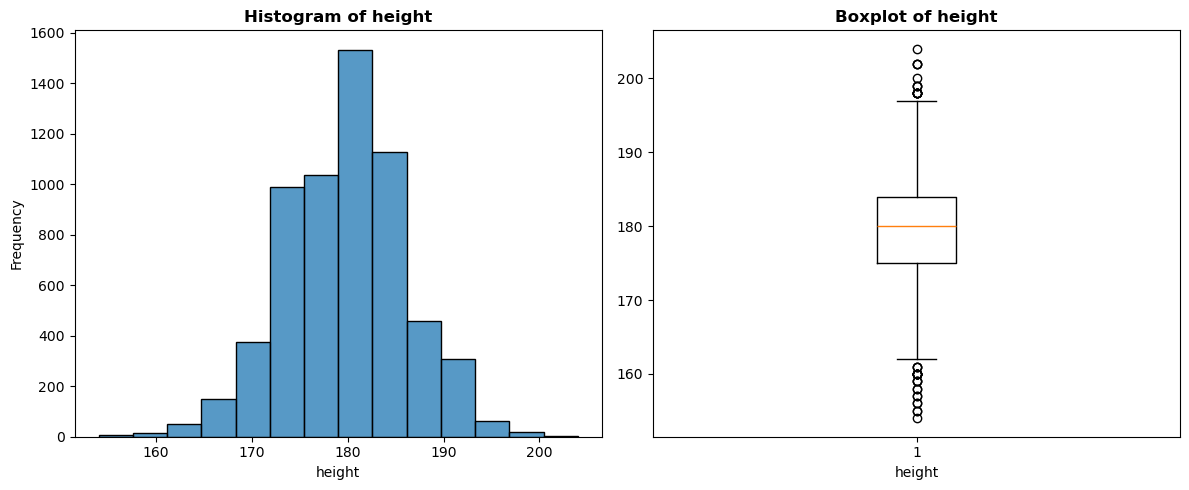

Outliers in height: [160, 161, 198, 199, 200, 202, 204, 154, 155, 156, 157, 158, 159]


In [138]:
stats_and_distribution(cyclists, 'height', 'numerical')

## BMI (_After Height & Weight_)

In [139]:
cyclists[cyclists['weight'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI


In [140]:
cyclists[cyclists['height'].isna()]

,_url,name,birth_year,weight,height,nationality,continent,geo area,BMI


After the imputation of both values, no rows with NaN weight/height are left.

In [141]:
generateBMI(cyclists, 'weight', 'height')

In fact, we observed that the method based on sampling from a normal distribution forced the initial distribution to follow a more normal shape. So this method had an effect on the original distribution, as we always expected, given the fact that we have the 50% of missing values. The 'random' generation of _weight_ and _height_ for most of the rows with NaNs means that the BMI is often based on two 'artificial' values. For this reason, we can also observe a significant reduction in the weight-height correlation compared to the original one.

In [142]:
print(f"Pearson's correlation height-weight pre imputation: {cyclists_preImputation['height'].corr(cyclists_preImputation['weight'])}")
print(f"Pearson's correlation height-weight after imputation: {cyclists['height'].corr(cyclists['weight'])}")

Pearson's correlation height-weight pre imputation: 0.7206850137382007
Pearson's correlation height-weight after imputation: 0.3826636421515671


In [143]:
print(f"Pearson's correlation BMI-weight pre imputation: {cyclists_preImputation['BMI'].corr(cyclists_preImputation['weight'])}")
print(f"Pearson's correlation BMI-weight after imputation: {cyclists['BMI'].corr(cyclists['weight'])}")

Pearson's correlation BMI-weight pre imputation: 0.6426926983541067
Pearson's correlation BMI-weight after imputation: 0.7014957354200054


In [144]:
print(f"Pearson's correlation BMI-height pre imputation: {cyclists_preImputation['BMI'].corr(cyclists_preImputation['height'])}")
print(f"Pearson's correlation BMI-height after imputation: {cyclists['BMI'].corr(cyclists['height'])}")

Pearson's correlation BMI-height pre imputation: -0.06536653251669178
Pearson's correlation BMI-height after imputation: -0.386055427128834


The problem with the correlation is more evident for 'height'.<br>
In order to choose the best way to make the inference of the BMI, we try to directly make the imputation of the NaN BMI without imputing the 2 other features.

Description of attribute 'BMI':


count       3071.0
mean     21.211784
std        1.36741
min          16.41
25%          20.31
50%          21.15
75%          22.09
max          27.77
Name: BMI, dtype: Float64


Unique values:
<FloatingArray>
[ <NA>, 22.34, 19.32, 21.16, 18.81, 21.39,  19.6,  19.8, 19.59, 20.52,
 ...
 25.76, 22.75, 23.34, 24.19, 22.69, 19.28,  25.7, 22.01, 24.98, 18.51]
Length: 433, dtype: Float64

Null values: 3063 over 6134 records - (49.93%)

Top 5 most frequent values:
BMI
20.68    49
21.6     46
20.45    46
20.52    38
21.22    35
Name: count, dtype: Int64


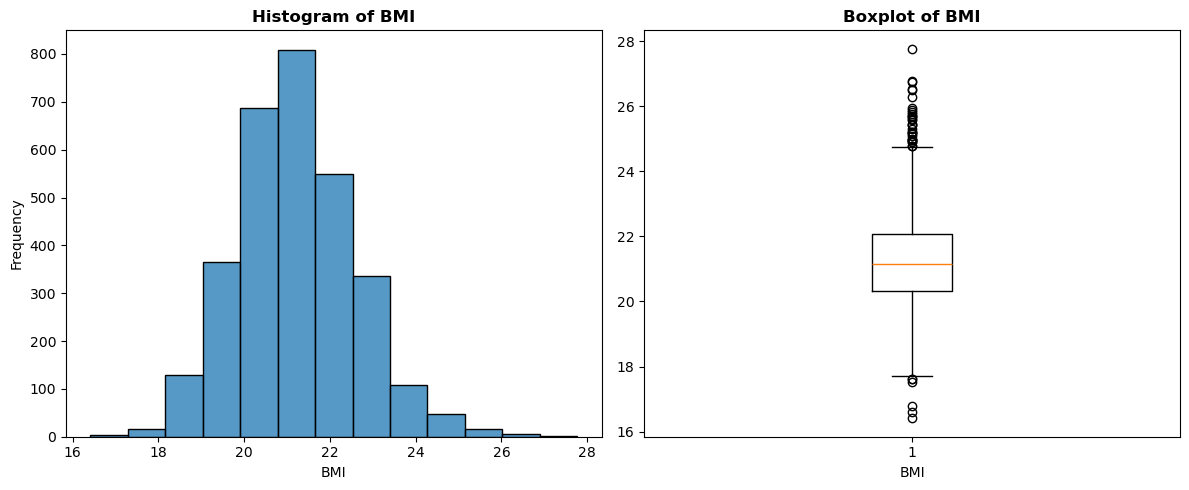

Outliers in BMI: [26.75, 24.96, 27.77, 24.9, 25.45, 16.41, 17.62, 16.79, 17.51, 17.63, 16.6, 25.01, 25.95, 24.97, 25.59, 26.3, 26.53, 25.1, 25.43, 25.31, 25.14, 25.22, 25.17, 26.78, 26.49, 24.78, 25.88, 24.98, 25.76, 25.66, 25.61, 25.44, 25.7, 24.91, 25.83, 25.69]


In [145]:
stats_and_distribution(cyclists_preImputation, 'BMI', 'numerical')

Description of attribute 'BMI':


count       6134.0
mean     21.229425
std       1.977456
min          13.55
25%          20.01
50%          21.16
75%          22.36
max          30.78
Name: BMI, dtype: Float64


Unique values:
<FloatingArray>
[19.99, 22.34, 19.32, 21.16, 18.81, 21.39, 21.47,  19.6,  19.8, 20.31,
 ...
 28.34, 16.59, 27.47, 23.52, 16.64, 15.47, 27.83,  17.4, 17.35, 16.01]
Length: 993, dtype: Float64

Null values: 0 over 6134 records - (0.00%)

Top 5 most frequent values:
BMI
21.6     54
20.68    52
20.45    52
21.22    42
20.9     41
Name: count, dtype: Int64


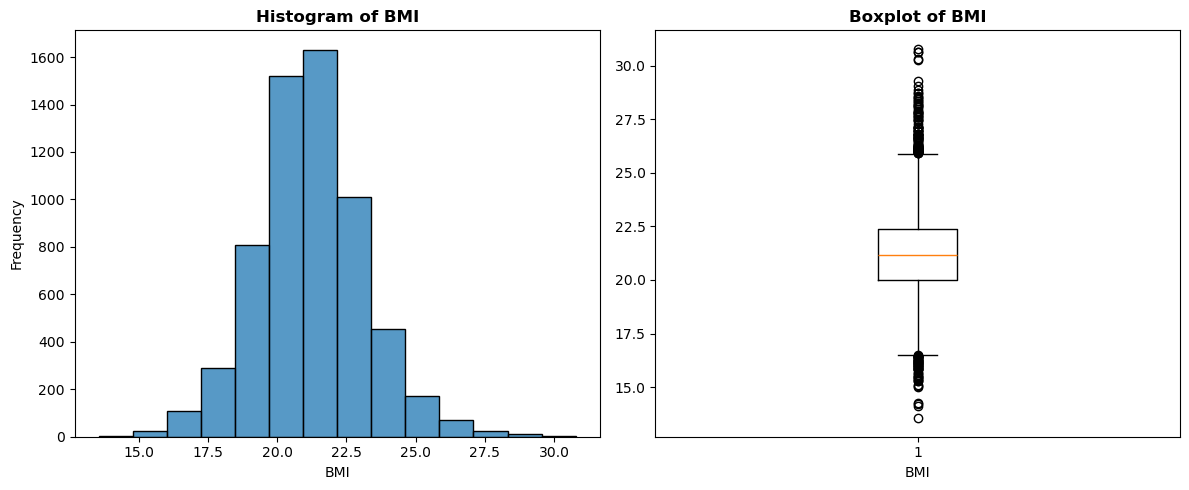

Outliers in BMI: [26.93, 13.55, 14.28, 15.66, 16.43, 15.86, 15.51, 16.45, 16.28, 16.39, 15.46, 16.24, 16.14, 16.41, 26.81, 26.05, 26.11, 26.25, 26.78, 27.87, 27.25, 26.16, 26.3, 26.6, 27.8, 28.72, 29.29, 30.63, 28.55, 26.21, 26.59, 26.09, 15.82, 15.57, 15.07, 15.11, 26.22, 16.25, 16.32, 16.46, 16.17, 16.42, 16.07, 16.04, 27.47, 28.34, 25.96, 25.97, 26.82, 26.96, 26.07, 26.67, 26.04, 27.15, 27.14, 27.1, 26.53, 26.08, 28.42, 28.36, 28.85, 28.07, 27.42, 26.75, 28.18, 26.0, 30.61, 30.29, 30.78, 30.25, 26.38, 14.22, 15.9, 15.47, 15.87, 15.37, 26.28, 26.2, 27.07, 27.58, 27.08, 27.83, 15.95, 15.34, 15.41, 15.3, 16.38, 16.3, 16.01, 16.09, 16.13, 16.48, 16.12, 16.23, 16.05, 26.61, 26.49, 27.85, 26.24, 25.91, 25.94, 25.98, 25.95, 25.99, 26.55, 26.13, 26.66, 26.74, 26.01, 27.7, 26.69, 26.19, 27.52, 27.95, 28.48, 27.48, 27.59, 28.2, 27.77, 29.05, 28.56, 28.12, 28.24, 28.13, 26.15, 27.76, 26.4, 27.01, 14.13, 14.99, 15.85, 15.99, 15.92, 15.28, 15.67, 27.65, 26.17]


In [146]:
stats_and_distribution(cyclists, 'BMI', 'numerical')

As we can see, after imputation we can see more outliers in both parts of the box plot. In fact, for the rows where both '_height_' and '_weight_' are missing, the BMI is in a sense obtained by combining two artificial values, so it may not be so relevant. As we said, let's try to impute the sole BMI.

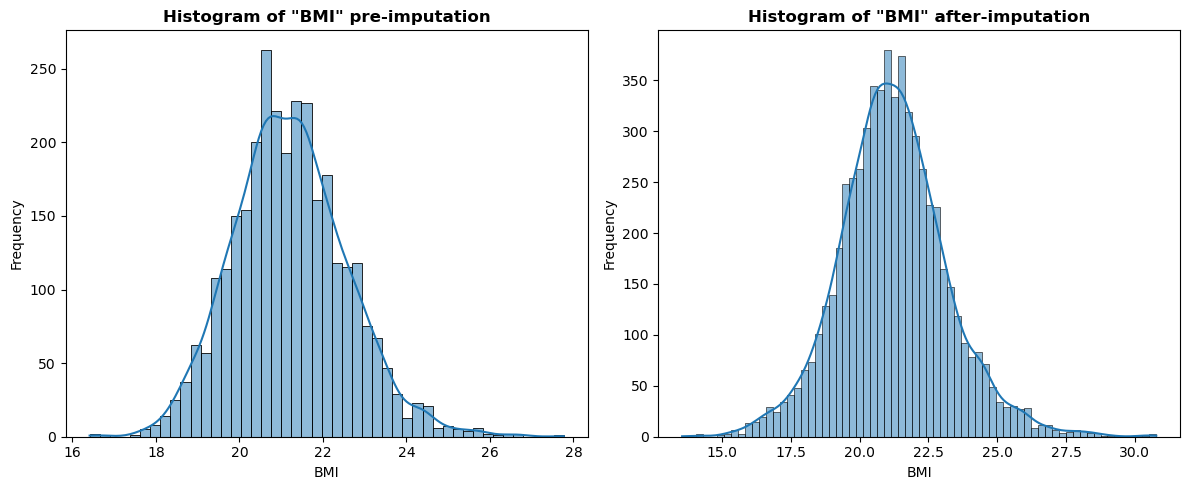

In [147]:
imputationComparison(cyclists_preImputation, cyclists, 'BMI')

### Draw random values from a normal distribution considering the geo area

Direct imputation for the NaNs BMI values without reconstructing the two components, weight and height.

In [148]:
cyclists_afterImputation=cyclists.copy() #BMI determined by combining weight and height separately imputed
cyclists=cyclists_preImputation.copy() #BMI determined by direct imputation, without passing through weight and height
#reset the dataframe before the imputation phase, in order to have again the missing values in the BMI column

Let's analize the BMI distribution according to the geo area field.

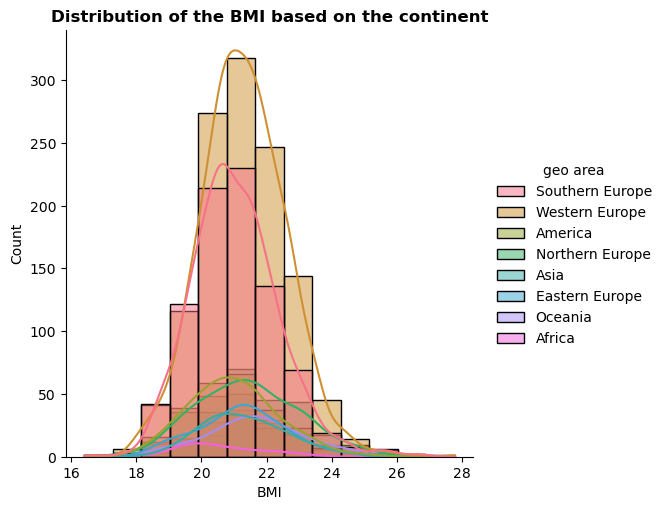

In [149]:
sbn.set_palette("husl", n_colors=8) #8 heo areas
sbn.displot(cyclists, x='BMI',kind="hist", row_order="desc", kde=True, bins='sturges', hue='geo area')
plt.title("Distribution of the BMI based on the continent", fontweight='bold')
plt.show()
sbn.reset_defaults()
plt.close()

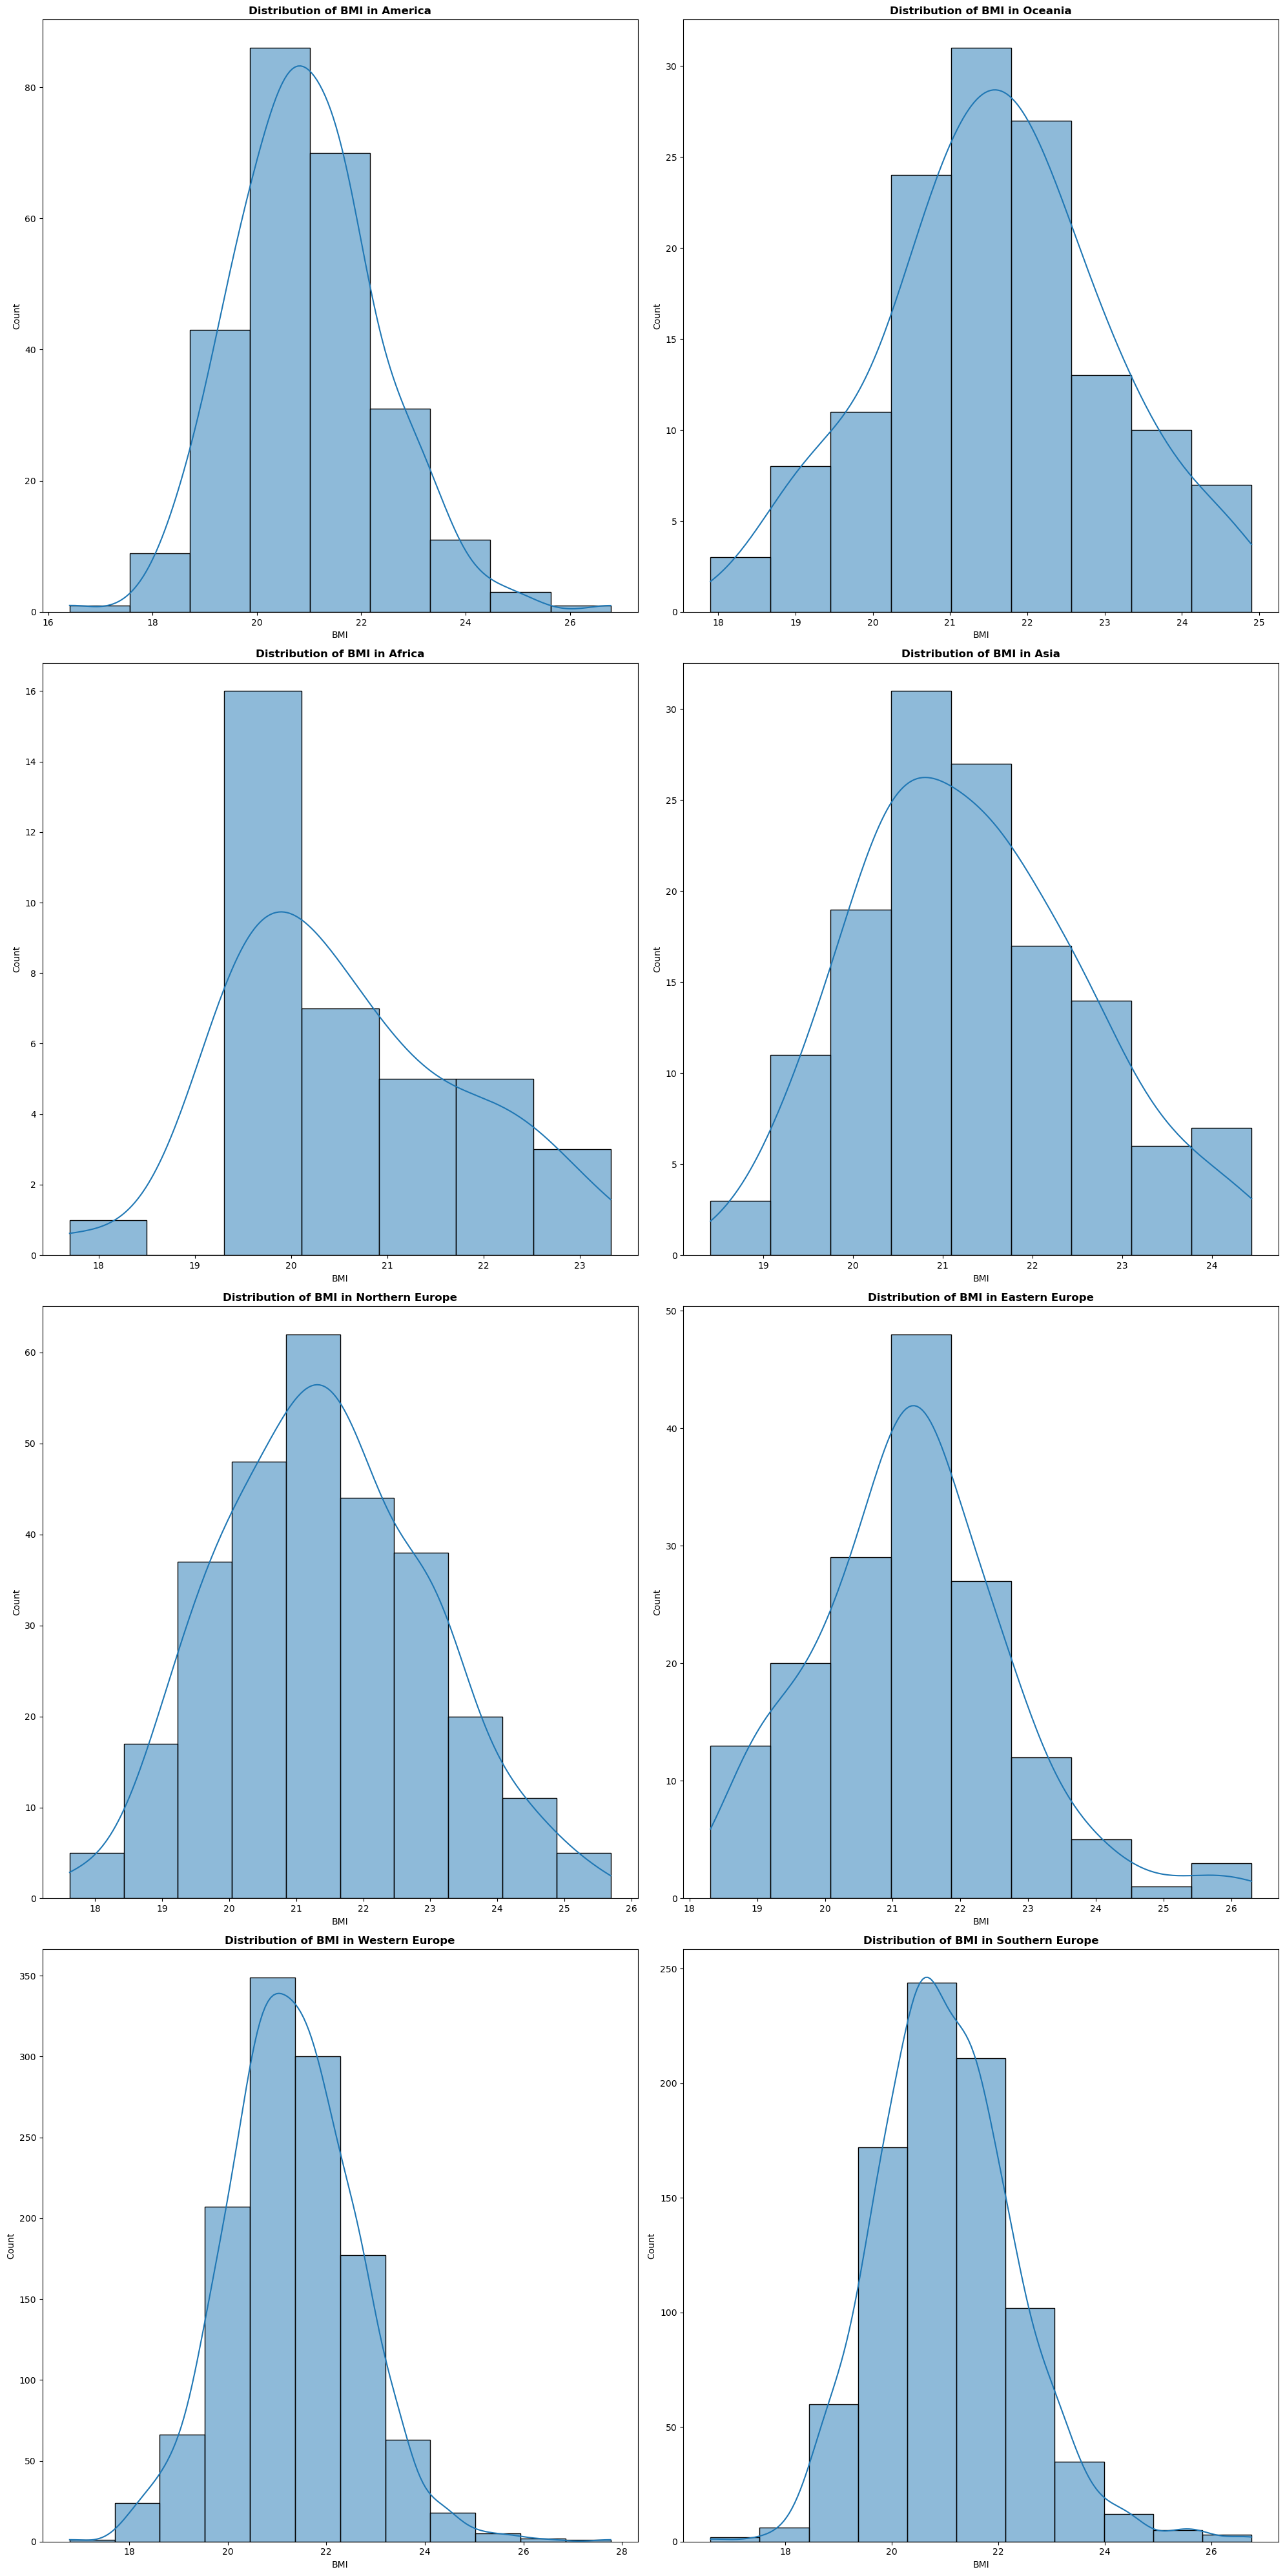

In [150]:
fig, axes = plt.subplots(4, 2, figsize=(20, 40))  # Adjust size if needed

#we use the geographical areas previously defined
#Loop through regions, filter the rows in the cyclists dataset and plot the distribution
for i, region in enumerate(regions):
    region_data = cyclists[cyclists["geo area"] == region]
    sbn.histplot(region_data, x="BMI", kde=True, bins="sturges", ax=axes.flat[i])
    axes.flat[i].set_title(f"Distribution of BMI in {region}", fontweight='bold')
plt.xlabel("BMI")
plt.tight_layout()
plt.show()

In [151]:
#Print the number of cyclists in each region
for i, region in enumerate(regions):
    region_data = cyclists[cyclists["geo area"] == region]
    print(f"Number of cyclists in {region}: ", region_data.shape[0])

Number of cyclists in America:  458
Number of cyclists in Oceania:  165
Number of cyclists in Africa:  47
Number of cyclists in Asia:  210
Number of cyclists in Northern Europe:  417
Number of cyclists in Eastern Europe:  224
Number of cyclists in Western Europe:  2524
Number of cyclists in Southern Europe:  2089


In [152]:
conditional_normal_imputation(cyclists, 'BMI', 'geo area')

Labels:  ['Southern Europe' 'Western Europe' 'America' 'Northern Europe' 'Asia'
 'Eastern Europe' 'Oceania' 'Africa']
----------
Label 'Southern Europe' --> mean 21.03657276995305 standard dev 1.3193305607990586
Missing values count for the column BMI with label 'Southern Europe' --> 1237
----------
Label 'Western Europe' --> mean 21.291986809563088 standard dev 1.3068867194656308
Missing values count for the column BMI with label 'Western Europe' --> 1311
----------
Label 'America' --> mean 20.97149019607843 standard dev 1.420372627339057
Missing values count for the column BMI with label 'America' --> 203
----------
Label 'Northern Europe' --> mean 21.414599303135883 standard dev 1.554042021508716
Missing values count for the column BMI with label 'Northern Europe' --> 130
----------
Label 'Asia' --> mean 21.309925925925924 standard dev 1.2750929122109462
Missing values count for the column BMI with label 'Asia' --> 75
----------
Label 'Eastern Europe' --> mean 21.3026582278481 stand

After the imputation are there NaNs? False


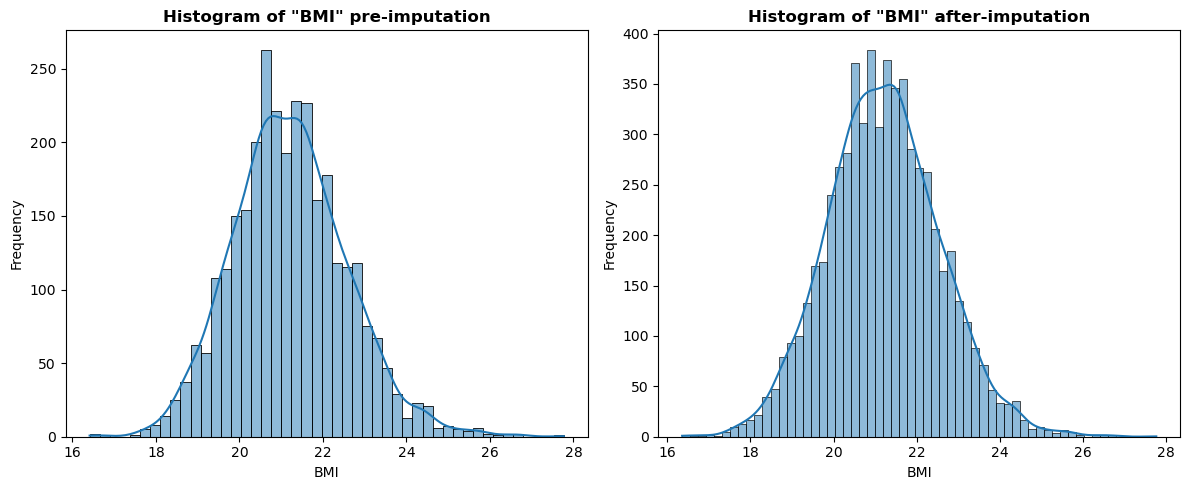

In [153]:
print("After the imputation are there NaNs?",cyclists['BMI'].isna().any())
imputationComparison(cyclists_preImputation, cyclists, 'BMI')

It seems that the initial distribution is quite preserved. We immediatly notice that this strategy is better than the one in which we have imputed the _weight_ and _height_ individually and then we combined them to form the BMI.

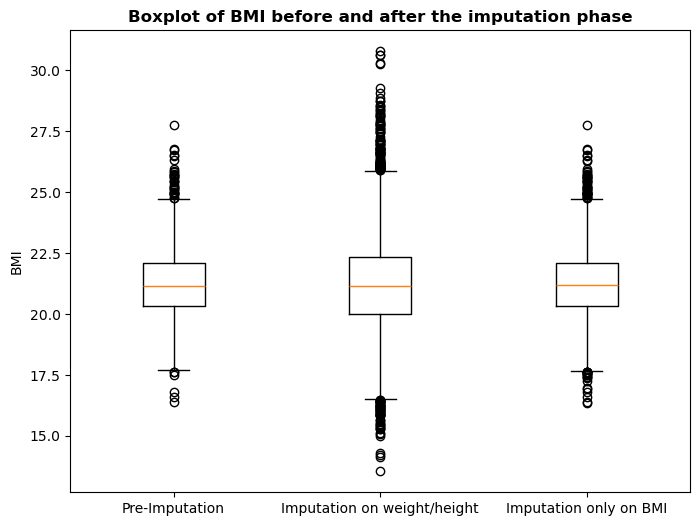

In [156]:
plt.figure(figsize=(8, 6))

#Unique boxplot with multiple datasets representing the initial situation and the imputation strategies
plt.boxplot(
    [cyclists_preImputation['BMI'].dropna(), cyclists_afterImputation['BMI'], cyclists['BMI']],
    labels=['Pre-Imputation', 'Imputation on weight/height','Imputation only on BMI']
)
plt.title("Boxplot of BMI before and after the imputation phase", fontweight='bold')
plt.ylabel("BMI")
plt.show()
plt.close()

The box plot confirms also that with this approach we have not introduced many outliers as in the middle one.

Description of attribute 'BMI':


count       3071.0
mean     21.211784
std        1.36741
min          16.41
25%          20.31
50%          21.15
75%          22.09
max          27.77
Name: BMI, dtype: Float64


Unique values:
<FloatingArray>
[ <NA>, 22.34, 19.32, 21.16, 18.81, 21.39,  19.6,  19.8, 19.59, 20.52,
 ...
 25.76, 22.75, 23.34, 24.19, 22.69, 19.28,  25.7, 22.01, 24.98, 18.51]
Length: 433, dtype: Float64

Null values: 3063 over 6134 records - (49.93%)

Top 5 most frequent values:
BMI
20.68    49
21.6     46
20.45    46
20.52    38
21.22    35
Name: count, dtype: Int64


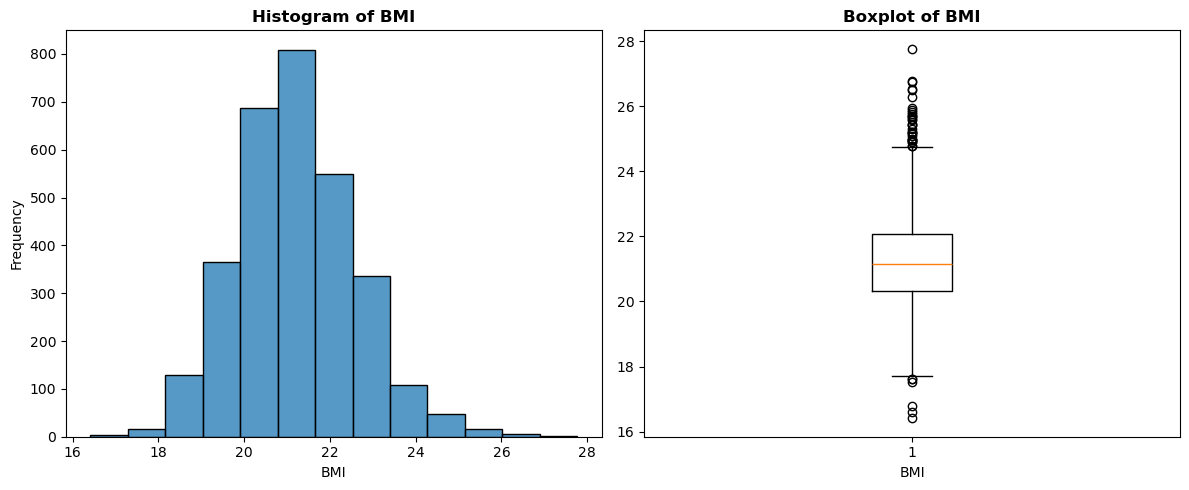

Outliers in BMI: [26.75, 24.96, 27.77, 24.9, 25.45, 16.41, 17.62, 16.79, 17.51, 17.63, 16.6, 25.01, 25.95, 24.97, 25.59, 26.3, 26.53, 25.1, 25.43, 25.31, 25.14, 25.22, 25.17, 26.78, 26.49, 24.78, 25.88, 24.98, 25.76, 25.66, 25.61, 25.44, 25.7, 24.91, 25.83, 25.69]


In [157]:
stats_and_distribution(cyclists_preImputation,'BMI', 'numerical')

Description of attribute 'BMI':


count       6134.0
mean     21.210396
std       1.356886
min      16.354805
25%          20.31
50%      21.189857
75%          22.09
max          27.77
Name: BMI, dtype: Float64


Unique values:
<FloatingArray>
[ 21.81252114312517,              22.34,              19.32,
              21.16,              18.81,              21.39,
 22.963329948523022,               19.6,               19.8,
  21.76363632794939,
 ...
 19.734544900505494, 21.019492524026454, 20.597016208241797,
  22.07128308000255, 21.224819461767275,  22.11232273277977,
 20.911654711308593, 21.782320575016687, 23.034365905224462,
 17.924978950590006]
Length: 3495, dtype: Float64

Null values: 0 over 6134 records - (0.00%)

Top 5 most frequent values:
BMI
20.68    49
21.6     46
20.45    46
20.52    38
21.22    35
Name: count, dtype: Int64


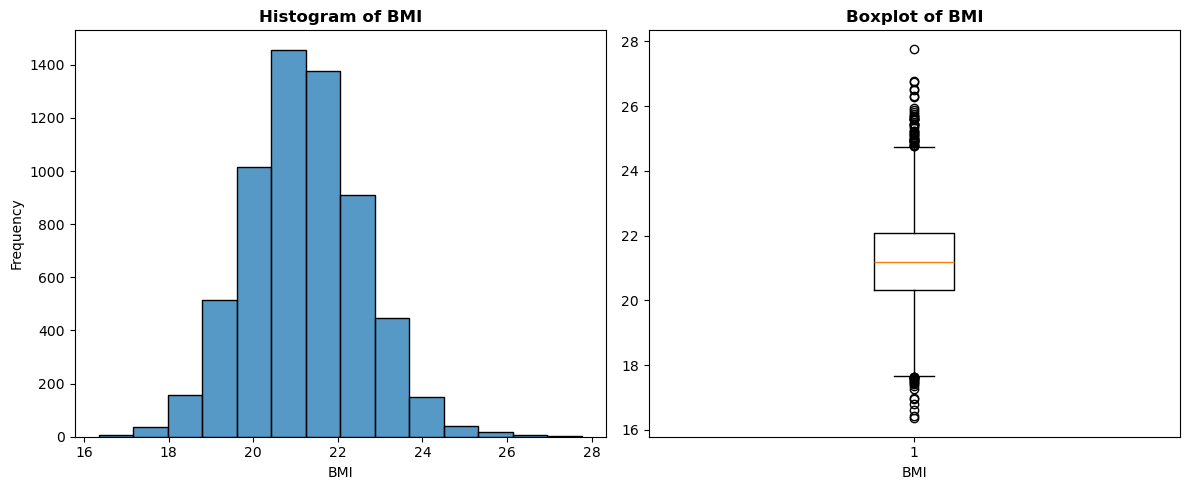

Outliers in BMI: [25.20022254995826, 26.53, 26.29494847074345, 26.49, 26.75, 25.36941027818859, 27.77, 24.96, 25.560439153833393, 24.9, 25.58605549480718, 16.79, 16.6, 17.612939045572052, 16.354805496766247, 17.565204979689348, 16.41, 17.6063456291257, 17.263427240941304, 17.412665529606812, 17.62, 17.486588904524456, 25.17, 25.456479242391318, 24.911001262515327, 24.922326209344472, 25.45, 24.807923763767764, 25.1, 26.78, 26.3, 25.14, 24.78, 24.91, 25.59, 25.88, 25.607467548760738, 24.98, 25.22, 25.83, 25.01, 25.76, 25.66, 24.786893547252976, 24.954337414105275, 25.121997134864937, 16.96844793244452, 16.94070251418933, 17.43167412484733, 17.51, 17.58658288618571, 17.364928022068078, 17.535927730973782, 17.63, 17.63495221807294, 25.44, 25.61, 25.95, 25.7, 25.048243994398607, 25.43, 24.86757680684844, 24.97, 25.31, 25.69]


In [158]:
stats_and_distribution(cyclists,'BMI', 'numerical')

It seems that there are fewer outliers compared to the previous approach (2 phase imputation), although there are still a good number of overweight/underweight cyclists.

In [159]:
print(f"Pearson's correlation height-weight pre imputation: {cyclists_preImputation['height'].corr(cyclists_preImputation['weight'])}")

Pearson's correlation height-weight pre imputation: 0.7206850137382007


As _height_ and _weight_ are highly correlated and BMI combines these two values, we can decide to keep only the BMI feature for our further analysis. In fact, the direct imputation of BMI provided more significant data.

In [160]:
cyclists.columns

Index(['_url', 'name', 'birth_year', 'weight', 'height', 'nationality',
       'continent', 'geo area', 'BMI'],
      dtype='object')

# Join with the dataset Races

The cyclist's weight and height are imputed using the last method tested, hence the sampling from the normal distribution.

In [161]:
join_result=pd.merge(races, cyclists, left_on='cyclist', right_on='_url', how='inner')
#drop the columns coming from the 'races' dataset that contain only race info
join_result.drop(columns=['name_x', 'points', 'uci_points', 'length', 'climb_total', 'profile', 'startlist_quality', 'average_temperature', 'is_tarmac', 'is_cobbled', 'is_gravel'], inplace=True)
#drop the columns coming from the 'cyclists' dataset that contain useless info
join_result.drop(columns=['name_y'], inplace=True)
#drop columns 
join_result.head()

,_url_x,date,position,cyclist,cyclist_age,cyclist_team,delta,_url_y,birth_year,weight,height,nationality,continent,geo area,BMI
0,tour-de-france/1978/stage-6,1978-07-05 04:02:24,0,sean-kelly,22.0,vini-ricordi-pinarello-sidermec-1986,0.0,sean-kelly,1956,77.0,180,Ireland,Europe,Northern Europe,23.77
1,tour-de-france/1978/stage-6,1978-07-05 04:02:24,1,gerrie-knetemann,27.0,norway-1987,0.0,gerrie-knetemann,1951,NaN,<NA>,Netherlands,Europe,Western Europe,19.959003
2,tour-de-france/1978/stage-6,1978-07-05 04:02:24,2,rene-bittinger,24.0,NaN,0.0,rene-bittinger,1954,69.0,174,France,Europe,Western Europe,22.79
3,tour-de-france/1978/stage-6,1978-07-05 04:02:24,3,joseph-bruyere,30.0,navigare-blue-storm-1993,0.0,joseph-bruyere,1948,NaN,<NA>,Belgium,Europe,Western Europe,23.086015
4,tour-de-france/1978/stage-6,1978-07-05 04:02:24,4,sven-ake-nilsson,27.0,spain-1991,0.0,sven-ake-nilsson,1951,63.0,172,Sweden,Europe,Northern Europe,21.3


In [162]:
print(f"Pre join RACES has {races.shape[0]} rows and CYCLISTS has {cyclists.shape[0]} rows. The join resul has {join_result.shape[0]} rows.")

Pre join RACES has 589865 rows and CYCLISTS has 6134 rows. The join resul has 589865 rows.


All cyclists in the 'races' dataset have a related row in the 'cyclists' dataset, otherwise the number of rows after the inner join will be less than the initial number. As already highlighted in the 'races' notebook, there are 39 cyclists in 'cyclists.csv' without any recorded race.

In [163]:
type(join_result)
join_result.dtypes

_url_x           object
date             object
position          int64
cyclist          object
cyclist_age     float64
cyclist_team     object
delta           float64
_url_y           object
birth_year        Int64
weight          float64
height            Int64
nationality      object
continent        object
geo area         object
BMI             Float64
dtype: object

In [164]:
for feature in join_result.columns:
    mv = join_result[feature].isna().sum()
    nrec = join_result.shape[0]
    per=mv*100/nrec
    print(f"Feature: {feature} --> {mv} MV over {nrec} records - ({per:.2f}%)")

Feature: _url_x --> 0 MV over 589865 records - (0.00%)
Feature: date --> 0 MV over 589865 records - (0.00%)
Feature: position --> 0 MV over 589865 records - (0.00%)
Feature: cyclist --> 0 MV over 589865 records - (0.00%)
Feature: cyclist_age --> 113 MV over 589865 records - (0.02%)
Feature: cyclist_team --> 159161 MV over 589865 records - (26.98%)
Feature: delta --> 0 MV over 589865 records - (0.00%)
Feature: _url_y --> 0 MV over 589865 records - (0.00%)
Feature: birth_year --> 45 MV over 589865 records - (0.01%)
Feature: weight --> 111382 MV over 589865 records - (18.88%)
Feature: height --> 110067 MV over 589865 records - (18.66%)
Feature: nationality --> 0 MV over 589865 records - (0.00%)
Feature: continent --> 0 MV over 589865 records - (0.00%)
Feature: geo area --> 0 MV over 589865 records - (0.00%)
Feature: BMI --> 0 MV over 589865 records - (0.00%)


## Cyclists performance (_New features_)

In [165]:
join_result.columns

Index(['_url_x', 'date', 'position', 'cyclist', 'cyclist_age', 'cyclist_team',
       'delta', '_url_y', 'birth_year', 'weight', 'height', 'nationality',
       'continent', 'geo area', 'BMI'],
      dtype='object')

**Definition of new features** describing the cyclist's performance in the races in which he has participated.
In particular, we have defined the cyclist's average and median positions. Note that the median is less sensitive to the presence of outliers/extreme placings. We also add the number of races in which a cyclist has participated.

In [166]:
join_result['median position'] = join_result.groupby('_url_y')['position'].transform(lambda x: round(x.median()))
join_result['AVG position'] = join_result.groupby('_url_y')['position'].transform(lambda x: round(x.mean()))
join_result['# cyclist races'] = join_result.groupby('_url_y')['_url_y'].transform("count")

In [167]:
#In join results these field are repeated for each race in which the cyclist has participated, so we extract only those fields.
cyclists_performance=join_result[['_url_y', 'BMI', 'median position', 'AVG position', '# cyclist races',
 'height','weight','nationality','continent', 'geo area', 'birth_year']].drop_duplicates().reset_index()
#reset the index that will be associated with the position in the 'races' dataset
cyclists_performance.drop("index", axis=1, inplace=True) #this column was the index associated in the race dataset, drop
cyclists_performance

,_url_y,BMI,median position,AVG position,# cyclist races,height,weight,nationality,continent,geo area,birth_year
0,sean-kelly,23.77,6,16,629,180,77.0,Ireland,Europe,Northern Europe,1956
1,gerrie-knetemann,19.959003,38,48,271,<NA>,NaN,Netherlands,Europe,Western Europe,1951
2,rene-bittinger,22.79,42,47,146,174,69.0,France,Europe,Western Europe,1954
3,joseph-bruyere,23.086015,8,16,48,<NA>,NaN,Belgium,Europe,Western Europe,1948
4,sven-ake-nilsson,21.3,25,33,145,172,63.0,Sweden,Europe,Northern Europe,1951
...,...,...,...,...,...,...,...,...,...,...,...
6090,ivan-raimondi,19.696783,173,173,1,<NA>,NaN,Italy,Europe,Southern Europe,1969
6091,jose-vincente-diaz,20.031931,17,17,1,<NA>,NaN,Colombia,America,America,1965
6092,jon-ander-insausti,25.45,54,54,1,187,89.0,Spain,Europe,Southern Europe,1992
6093,carlos-melero,20.011635,38,38,1,<NA>,NaN,Spain,Europe,Southern Europe,1948


### Number of participations

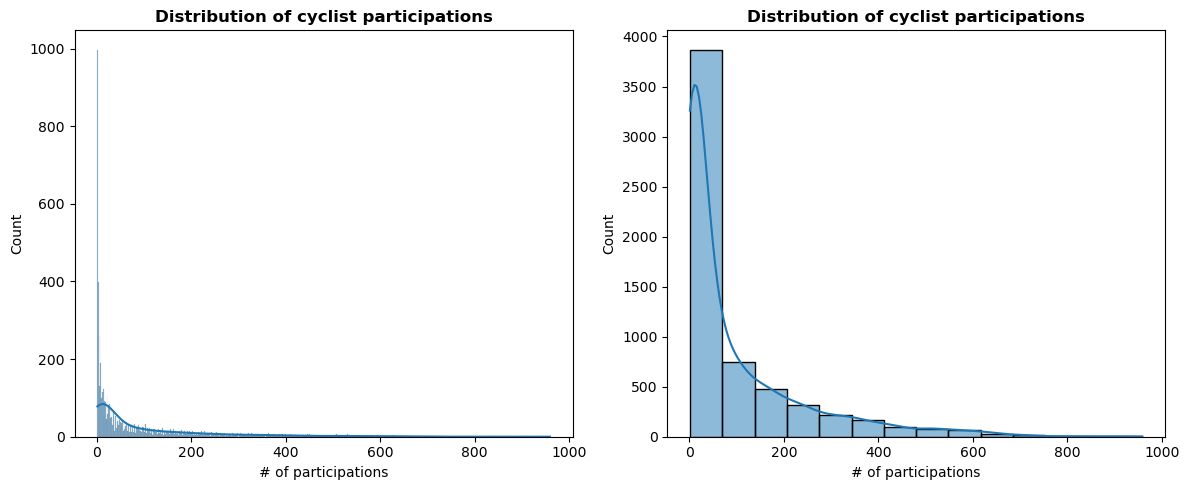

In [168]:
plt.figure(figsize=(12, 5))
#First plot --> a bin for each unique value
plt.subplot(1, 2, 1)
sbn.histplot(cyclists_performance['# cyclist races'], bins=cyclists_performance['# cyclist races'].nunique(), kde=True)
plt.title('Distribution of cyclist participations', fontweight='bold')
plt.xlabel('# of participations')

#First plot --> bins determined with the sturges rule
plt.subplot(1, 2, 2)
sbn.histplot(cyclists_performance['# cyclist races'], bins='sturges', kde=True)
plt.title('Distribution of cyclist participations', fontweight='bold')
plt.xlabel('# of participations')

plt.tight_layout()
plt.show()
plt.close()

As we have already seen in the other dataset, most cyclists have participated in very few races. The distribution of this feature is highly positively skewed.

Description of attribute '# cyclist races':


count    6095.000000
mean       96.778507
std       140.804582
min         1.000000
25%         5.000000
50%        30.000000
75%       133.000000
max       959.000000
Name: # cyclist races, dtype: float64


Unique values:
[629 271 146  48 145  62 101  35 177 179  68  42 230  27  34 180  51  36
 169 102  18  45  78 267 144  87  85  70 237 227 112 161 314 346  91  30
  55 121 130  80  25  23  89  97 183  54  11  52  15 334 137 203 157  19
  46  98  59 103 135  43 104  69  75 178 266 211  58  64 107  16  33  21
 151  28 105  82 109 653 386 451 437 883 567 321 439 155 614 520 627 359
 660 468 147 633 608 288 409 238 312 316 222 537 559 556 445 577 364 775
 328 613 515 575 352 701 293 400 942 473 257 512 418 711 432 436 392 251
 504 224 465 664 255 570 899 526 479 384 402 173 215 304 354 273 217 196
 295 350 305 264 194 529 511 378 530 239 505 268 225 188 651 331 612 557
 329 119 373 244 344 132 282  49 489 297 172 168 287 395 699 156 446 308
 278 235  76 367 302 363 434 202 220 518 365 358 421 213 315  56 262 353
 117 601 546 115 338  79 252  71 186  47  81 507 374 125  24 535 163 564
 477 581 320 335 411 323 214 528 207 281 332 249 276 485 185 600 496 642
 619 753 110 486 349 140 531 680 24

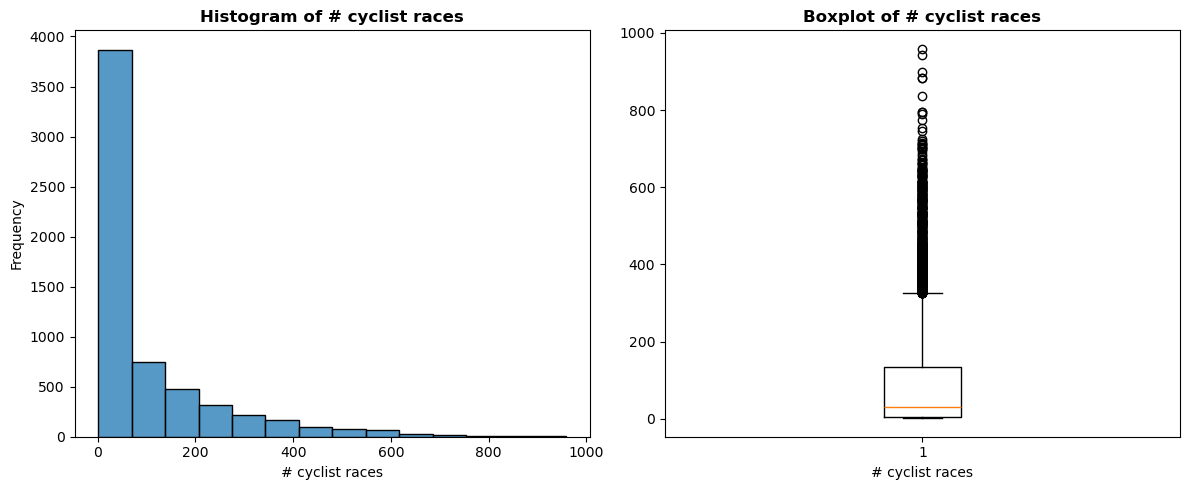

Outliers in # cyclist races: [512, 513, 514, 515, 518, 519, 520, 522, 526, 527, 528, 529, 530, 531, 533, 534, 535, 537, 538, 544, 545, 546, 547, 549, 550, 552, 554, 556, 557, 559, 562, 563, 564, 565, 567, 568, 569, 570, 571, 574, 575, 576, 577, 581, 582, 583, 585, 587, 590, 591, 592, 594, 595, 597, 598, 600, 601, 603, 605, 606, 608, 609, 610, 612, 613, 614, 615, 619, 625, 627, 628, 629, 633, 635, 638, 640, 641, 642, 645, 647, 648, 651, 653, 658, 660, 663, 664, 665, 670, 672, 673, 680, 687, 695, 699, 700, 701, 704, 710, 711, 715, 719, 726, 746, 753, 775, 790, 796, 836, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 343, 344, 346, 348, 349, 350, 351, 352, 353, 354, 355, 356, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 883, 372, 373, 374, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 899, 387, 389, 390, 388, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 

In [169]:
stats_and_distribution(cyclists_performance,'# cyclist races', 'numerical')

Since most cyclists have a very low number of related race participations, the cyclists with many participations are interpreted as outliers. It's a sort of power law distribution.

### AVG Position (_Global_)

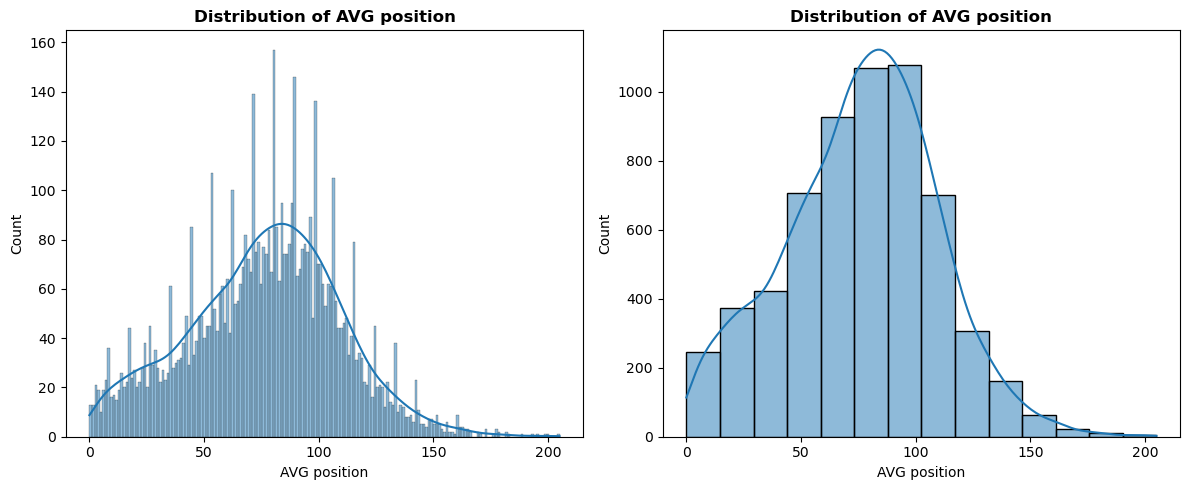

In [170]:
plt.figure(figsize=(12, 5))
#First plot --> a bin for each unique value
plt.subplot(1, 2, 1)
sbn.histplot(cyclists_performance['AVG position'], bins=cyclists_performance['AVG position'].nunique(), kde=True)
plt.title('Distribution of AVG position', fontweight='bold')
plt.xlabel('AVG position')

#Second plot --> bins determined using sturges
plt.subplot(1, 2, 2)
sbn.histplot(cyclists_performance['AVG position'], bins='sturges', kde=True)
plt.title('Distribution of AVG position', fontweight='bold')
plt.xlabel('AVG position')

plt.tight_layout()
plt.show()
plt.close()

Description of attribute 'AVG position':


count    6095.000000
mean       76.355373
std        33.147284
min         0.000000
25%        54.000000
50%        78.000000
75%        99.000000
max       205.000000
Name: AVG position, dtype: float64


Unique values:
[ 16  48  47  33  29  43  39  46  54  20  25  65  42  38  49  50  52  32
  26  53  57  63  17  28  27  74  36  22  62  45  55  41  56  61  71  51
  68  64  67  88  24  37  59  70  84  69  12  72  78  44  66  31  34  60
  75  79  95  81  73  77 106  83  86  94  93 107  76  98  85  91  82  80
  87  92  96 116 109  99 118 113 112 102 138 103 111 114 128 115 119 110
 100 101 127  90 130 105 104 108  35  89  58  97  14 125 117 123 122 124
 134  21  15  19  13  23  40  30  11   6 133 156 158 140 131 142 141 143
 126 120 129 137 132 160 150 139 146 135 144 152 121 162 173 136 153 145
   8 149 148 154   1   3 165 161   2 155   7   9   4  18  10   5 182 147
 157   0 164 163 170 159 179 205 177 178 193 195 151 200 189 176 166 171
 183 199]

Null values: 0 over 6095 records - (0.00%)

Top 5 most frequent values:
AVG position
84    95
88    95
96    89
82    85
80    84
Name: count, dtype: int64


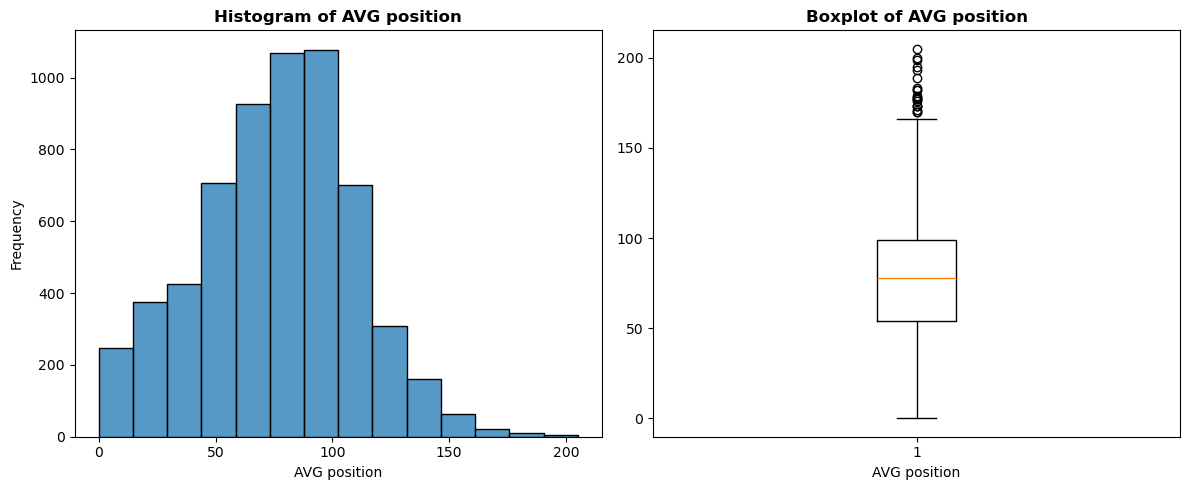

Outliers in AVG position: [193, 195, 199, 200, 170, 171, 205, 173, 176, 177, 178, 179, 182, 183, 189]


In [172]:
stats_and_distribution(cyclists_performance, 'AVG position', 'numerical')

The average AVG Position of the riders for whom we have at least one recorded placement is 76. From the distribution and the box plot we can see that only a few riders have a very low AVG position. In fact, the 1st quartile is position 48. This artificial column has a lot of outliers related to cyclists with very poor results or few bad races. <br>
Notice that the field 'AVG Position' is also related to the number of participant to the race events. It would be better to consider a weighted average, in order to give more weight to races with many participant rather that races with very few cyclists (being first over 100 cyclists is more significant than being 1 over 10 cyclists).

In [173]:
cyclists_performance[cyclists_performance['AVG position']==0]

,_url_y,BMI,median position,AVG position,# cyclist races,height,weight,nationality,continent,geo area,birth_year
4466,thierry-bock,22.031343,0,0,1,<NA>,NaN,Belgium,Europe,Western Europe,1966
5377,adriano-pella,23.027759,0,0,1,<NA>,NaN,Italy,Europe,Southern Europe,1945
5539,walter-baumgartner,22.306515,0,0,1,<NA>,NaN,Switzerland,Europe,Western Europe,1953
5828,donato-giuliani,20.262164,0,0,1,<NA>,NaN,Italy,Europe,Southern Europe,1946
5838,manuel-mesa,21.412628,0,0,1,<NA>,NaN,Spain,Europe,Southern Europe,1944


Some cyclists have an average position of 0, meaning that they have won all the races in which they have participated (only 1). 

In [174]:
print(f"0.1 Quantile - {cyclists_performance['AVG position'].quantile(.1)}")

0.1 Quantile - 29.0


In [175]:
print(f"0.05 Quantile - {cyclists_performance['AVG position'].quantile(.05)}")

0.05 Quantile - 17.0


Few cyclists have on average good placements.

### AVG Weighted Position

The average weighted position of the cyclist _k_ is determined using this formula: 
$$
AVG \ weighted \ position(cyclist_k) = \frac{\sum_{i=1}^{n} x_i \cdot w_i}{\sum_{i=1}^{n} w_i}
$$

Where:
* $x_i$: position of the _i_-th placement of the cyclist _k_.
* $w_i$: weight of the _i_-th placement of the cyclist _k_, which is the number of participants to that race event.
* $n$: number of races in which the cyclist _k_ participated in. 

In [176]:
#Determine the number of participants to each race event. It sufficies to group the rows on _url_x 
#which is the URL of the race after the join.
join_result['# race participants'] = join_result.groupby('_url_x')['_url_x'].transform("count")

#Determine the position of the cyclist in that race event weighted by the number of participants to that event.
join_result['weighted position'] = join_result['position'] * join_result['# race participants']

avg_position = join_result.groupby('_url_y').agg(
    tot_pos_weighted=('weighted position', 'sum'), #sum of all the weighted positions of the same cyclist (_url_y)
    tot_part=('# race participants', 'sum')  #sum of all the race participants of the races in which the cyclist has participated
).reset_index()

avg_position['AVG weighted position']= (avg_position['tot_pos_weighted'] / avg_position['tot_part']).round().astype("Int64")

avg_position.drop(['tot_pos_weighted','tot_part'],axis=1, inplace=True) #drop useless columns
avg_position

,_url_y,AVG weighted position
0,aad-van-den-hoek,83
1,aaron-gate,106
2,aaron-kemps,75
3,aaron-olsen,146
4,aaron-van-poucke,88
...,...,...
6090,zenon-jaskula,62
6091,zhandos-bizhigitov,137
6092,zico-waeytens,118
6093,zoran-klemencic,102


Let's incorporate the new column in the cyclists_performance dataframe.

In [177]:
cyclists_performance=pd.merge(cyclists_performance, avg_position, on='_url_y', how='inner')

In [178]:
cyclists_performance #new dataframe containing only the cyclists info

,_url_y,BMI,median position,AVG position,# cyclist races,height,weight,nationality,continent,geo area,birth_year,AVG weighted position
0,sean-kelly,23.77,6,16,629,180,77.0,Ireland,Europe,Northern Europe,1956,22
1,gerrie-knetemann,19.959003,38,48,271,<NA>,NaN,Netherlands,Europe,Western Europe,1951,66
2,rene-bittinger,22.79,42,47,146,174,69.0,France,Europe,Western Europe,1954,54
3,joseph-bruyere,23.086015,8,16,48,<NA>,NaN,Belgium,Europe,Western Europe,1948,21
4,sven-ake-nilsson,21.3,25,33,145,172,63.0,Sweden,Europe,Northern Europe,1951,38
...,...,...,...,...,...,...,...,...,...,...,...,...
6090,ivan-raimondi,19.696783,173,173,1,<NA>,NaN,Italy,Europe,Southern Europe,1969,173
6091,jose-vincente-diaz,20.031931,17,17,1,<NA>,NaN,Colombia,America,America,1965,17
6092,jon-ander-insausti,25.45,54,54,1,187,89.0,Spain,Europe,Southern Europe,1992,54
6093,carlos-melero,20.011635,38,38,1,<NA>,NaN,Spain,Europe,Southern Europe,1948,38


In [179]:
print(cyclists_performance.columns)
cyclists_performance.rename(columns={'_url_y':'name'}, inplace=True)
print(cyclists_performance.columns)

Index(['_url_y', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'height', 'weight', 'nationality', 'continent', 'geo area',
       'birth_year', 'AVG weighted position'],
      dtype='object')
Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'height', 'weight', 'nationality', 'continent', 'geo area',
       'birth_year', 'AVG weighted position'],
      dtype='object')


Let's compute some statistics on this new weighted feature.

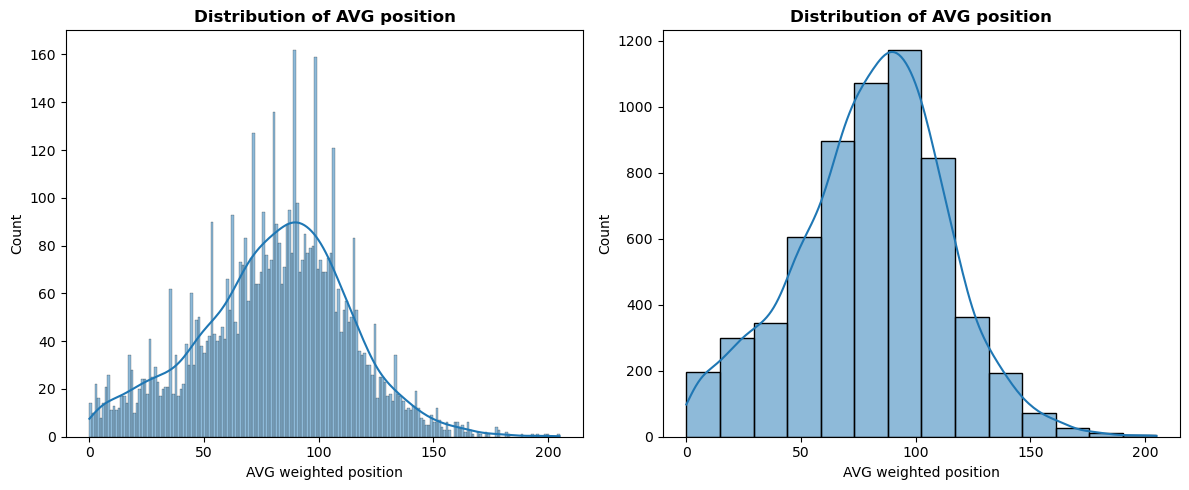

In [180]:
plt.figure(figsize=(12, 5))

#First plot --> a bin for each unique value
plt.subplot(1, 2, 1)
sbn.histplot(cyclists_performance['AVG weighted position'], bins=cyclists_performance['AVG position'].nunique(), kde=True)
plt.title('Distribution of AVG position', fontweight='bold')
plt.xlabel('AVG weighted position')

#Second plot --> bins determined using sturges rule
plt.subplot(1, 2, 2)
sbn.histplot(cyclists_performance['AVG weighted position'], bins='sturges', kde=True)
plt.title('Distribution of AVG position', fontweight='bold')
plt.xlabel('AVG weighted position')

plt.tight_layout()
plt.show()
plt.close()

Description of attribute 'AVG weighted position':


count       6095.0
mean     80.594258
std      32.641542
min            0.0
25%           60.0
50%           83.0
75%          102.0
max          205.0
Name: AVG weighted position, dtype: Float64


Unique values:
<IntegerArray>
[ 22,  66,  54,  21,  38,  43,  75,  53,  51,  60,
 ...
 177, 193, 195, 200, 189, 167, 171, 183, 199, 170]
Length: 183, dtype: Int64

Null values: 0 over 6095 records - (0.00%)

Top 5 most frequent values:
AVG weighted position
91    98
87    95
76    94
86    89
82    89
Name: count, dtype: Int64


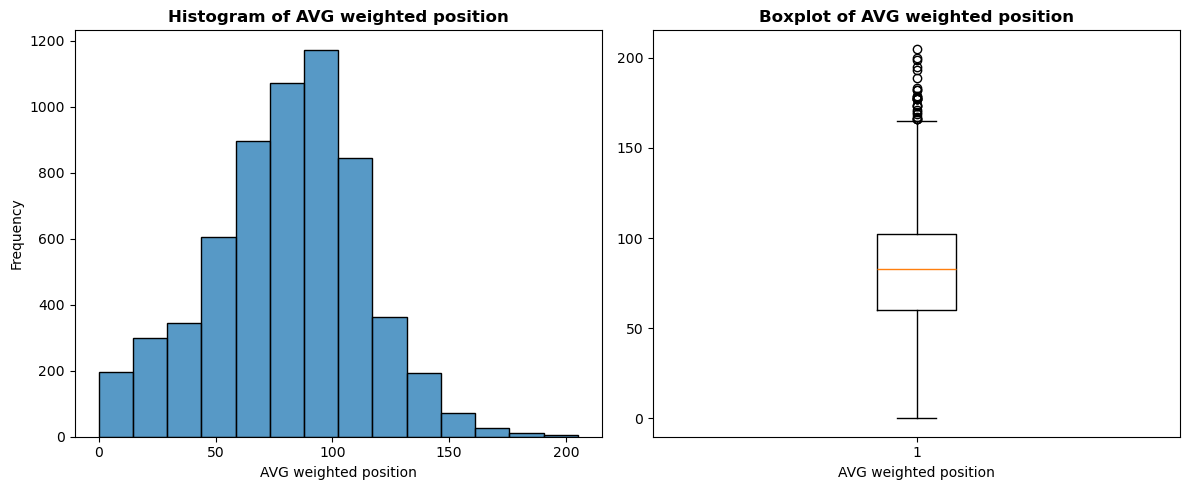

Outliers in AVG weighted position: [193, 195, 166, 167, 200, 169, 199, 171, 170, 205, 174, 173, 177, 178, 179, 182, 183, 189]


In [181]:
stats_and_distribution(cyclists_performance, 'AVG weighted position', 'numerical')

As expected, this new feature is more indicative and presents outliers for extremely poor average performance. The mean of that column is similar as before, around position 78. The first quartile is on position 64, which means that 25% of the cyclist have an AVG weighted performance lower than 64. 

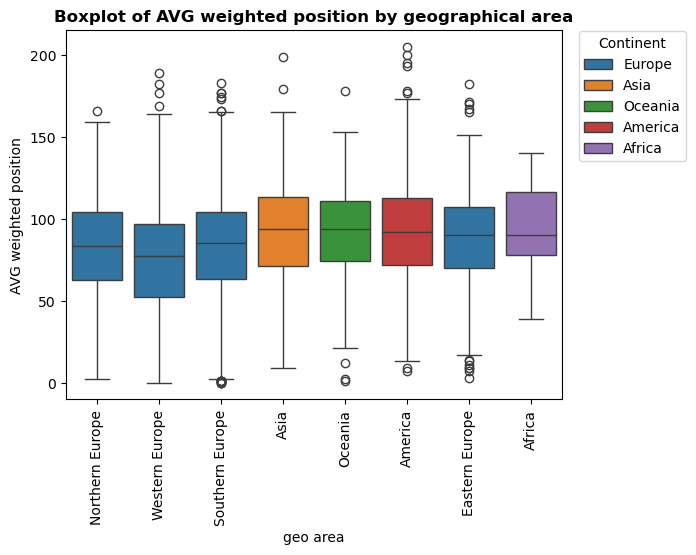

In [183]:
sbn.boxplot(data=cyclists_performance, x='geo area', y='AVG weighted position', hue='continent')
plt.legend(bbox_to_anchor=(1.02, 1.015), loc='upper left', title='Continent')
plt.xticks(rotation=90)
plt.title('Boxplot of AVG weighted position by geographical area', fontweight='bold')
plt.show()

We can see that Western European cyclists have a slightly better average position. There are some Southern European cyclists with an average position of 0, which is classified as an outlier. Among the European cyclists, the Eastern and Southern Europeans have more variability in their average position. The average position of African cyclists has a compact distribution, as this is the least represented group.

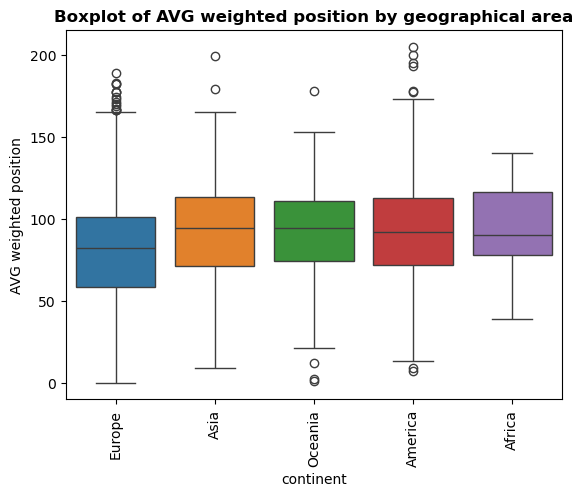

In [185]:
sbn.boxplot(data=cyclists_performance, x='continent', y='AVG weighted position', hue='continent')
plt.xticks(rotation=90)
plt.title('Boxplot of AVG weighted position by geographical area', fontweight='bold')
plt.show()

As already mentioned in the previous box plot, the group of European cyclists is the one with the most outliers, as it is the most populated group with 85% of cyclists. European cyclists generally have a better average weighted position.

### Median position

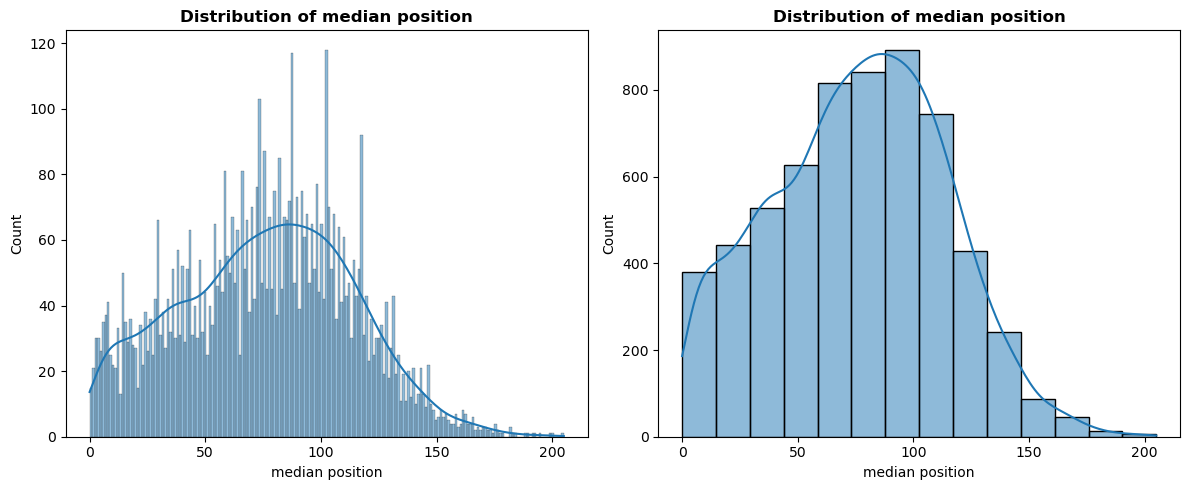

In [186]:
plt.figure(figsize=(12, 5))

#First plot --> a bin for each unique value
plt.subplot(1, 2, 1)
sbn.histplot(cyclists_performance['median position'], bins=cyclists_performance['median position'].nunique(), kde=True)
plt.title('Distribution of median position', fontweight='bold')
plt.xlabel('median position')

#Second plot --> bin determined used sturges
plt.subplot(1, 2, 2)
sbn.histplot(cyclists_performance['median position'], bins='sturges', kde=True)
plt.title('Distribution of median position', fontweight='bold')
plt.xlabel('median position')

plt.tight_layout()
plt.show()
plt.close()

Description of attribute 'median position':


count    6095.000000
mean       76.079409
std        37.708953
min         0.000000
25%        48.000000
50%        78.000000
75%       103.000000
max       205.000000
Name: median position, dtype: float64


Unique values:
[  6  38  42   8  25   7  14  17  36  48  19  64  23  31  46  44  16  20
  56  24  57  60  10  21  54  32  26  76  29  47  39  37  41  12  30  52
  40  61  80  53  50  78  49  68  55  71  93  62  73  72  81  70  90  74
  65  66  89   3  69  51  33  22  88  63  67  92 108  82  85  59  77  98
  83 110  75  97  84  79  86  96 102 120 104 122 114 116  87  95 145 118
  43 125 117 121 137 123 131 132 106 105 128 124 111 112  28  18  34  91
 135 103 101  27 100  45  94 119  35  58 107 115 109 136 126 129 113 130
 143 134  13  99  11   5 138 139 140 156 169   9 158 155 146 147 133  15
 127 144 141 160 142 151 150 148 167 154 172 171 166 157 159 161 153 162
 164   4 152 168   1   2 165 170 163 182 177   0 149 176 179 174 205 188
 178 173 192 175 193 195 200 184 189 183 199]

Null values: 0 over 6095 records - (0.00%)

Top 5 most frequent values:
median position
76    87
82    85
66    81
98    77
72    76
Name: count, dtype: int64


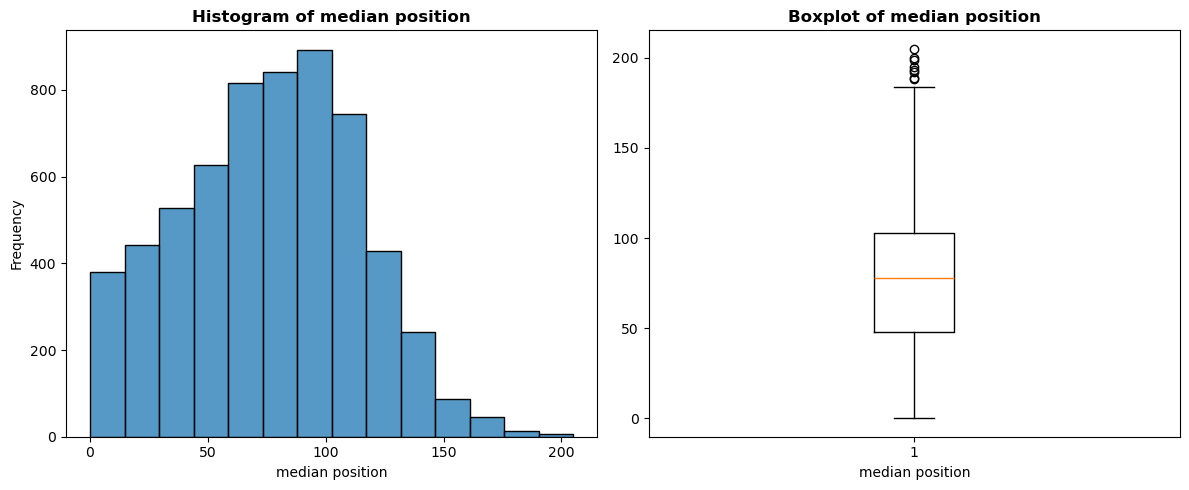

Outliers in median position: [192, 193, 195, 199, 200, 205, 188, 189]


In [187]:
stats_and_distribution(cyclists_performance, 'median position', 'numerical')

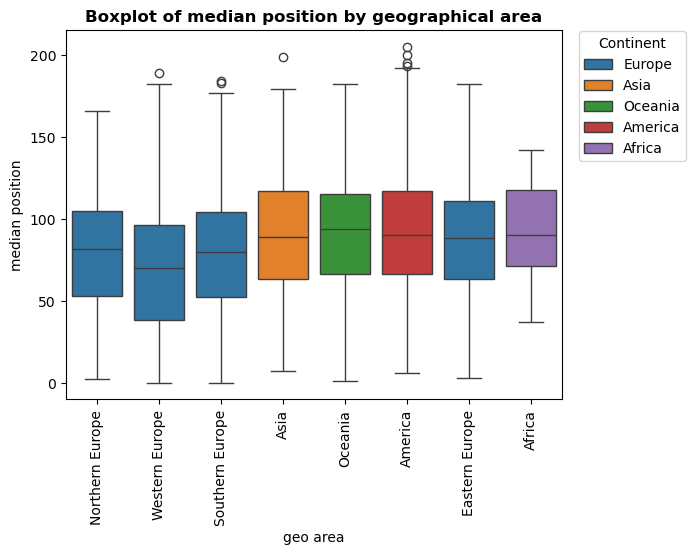

In [189]:
sbn.boxplot(data=cyclists_performance, x='geo area', y='median position', hue='continent')
plt.legend(bbox_to_anchor=(1.02, 1.015), loc='upper left', title='Continent')
plt.xticks(rotation=90)
plt.title('Boxplot of median position by geographical area', fontweight='bold')
plt.show()

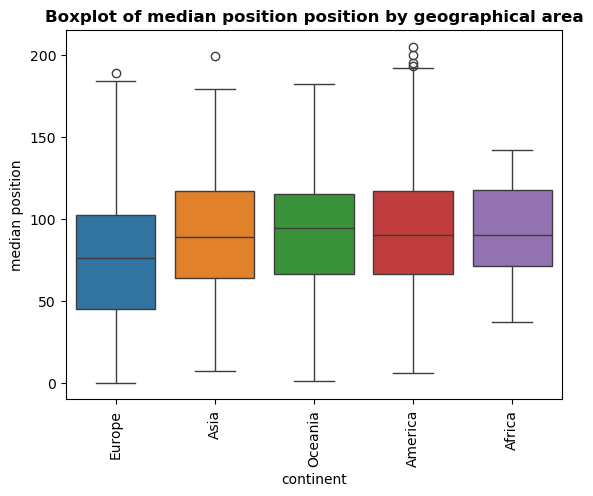

In [190]:
sbn.boxplot(data=cyclists_performance, x='continent', y='median position', hue='continent')
plt.xticks(rotation=90)
plt.title('Boxplot of median position position by geographical area', fontweight='bold')
plt.show()

For the median position, we can more or less repeat the same considerations as for the average weighted position of the cyclists. In practice, we can confirm that the median is more robust to outliers.

### AVG Position considering the season

In [191]:
join_result.head()

,_url_x,date,position,cyclist,cyclist_age,cyclist_team,delta,_url_y,birth_year,weight,height,nationality,continent,geo area,BMI,median position,AVG position,# cyclist races,# race participants,weighted position
0,tour-de-france/1978/stage-6,1978-07-05 04:02:24,0,sean-kelly,22.0,vini-ricordi-pinarello-sidermec-1986,0.0,sean-kelly,1956,77.0,180,Ireland,Europe,Northern Europe,23.77,6,16,629,106,0
1,tour-de-france/1978/stage-6,1978-07-05 04:02:24,1,gerrie-knetemann,27.0,norway-1987,0.0,gerrie-knetemann,1951,NaN,<NA>,Netherlands,Europe,Western Europe,19.959003,38,48,271,106,106
2,tour-de-france/1978/stage-6,1978-07-05 04:02:24,2,rene-bittinger,24.0,NaN,0.0,rene-bittinger,1954,69.0,174,France,Europe,Western Europe,22.79,42,47,146,106,212
3,tour-de-france/1978/stage-6,1978-07-05 04:02:24,3,joseph-bruyere,30.0,navigare-blue-storm-1993,0.0,joseph-bruyere,1948,NaN,<NA>,Belgium,Europe,Western Europe,23.086015,8,16,48,106,318
4,tour-de-france/1978/stage-6,1978-07-05 04:02:24,4,sven-ake-nilsson,27.0,spain-1991,0.0,sven-ake-nilsson,1951,63.0,172,Sweden,Europe,Northern Europe,21.3,25,33,145,106,424


In [192]:
join_result['date'].describe()

count                  589865
unique                 140509
top       1986-07-05 01:58:44
freq                      203
Name: date, dtype: object

In [193]:
#Convertion of the object column to datetime64 (There are no missing values)
join_result['date'] = pd.to_datetime(join_result['date']).dt.floor('d')
print(join_result['date'].dtype)

datetime64[ns]


In [194]:
join_result['date'].head()

0   1978-07-05
1   1978-07-05
2   1978-07-05
3   1978-07-05
4   1978-07-05
Name: date, dtype: datetime64[ns]

In [195]:
#The column 'month' will have the name of the month contained in the associated date field
join_result['month'] = join_result['date'].dt.month_name()

In [196]:
join_result['month'].unique()

array(['July', 'September', 'June', 'March', 'May', 'April', 'February',
       'August', 'October', 'November'], dtype=object)

In December and January there are no races.

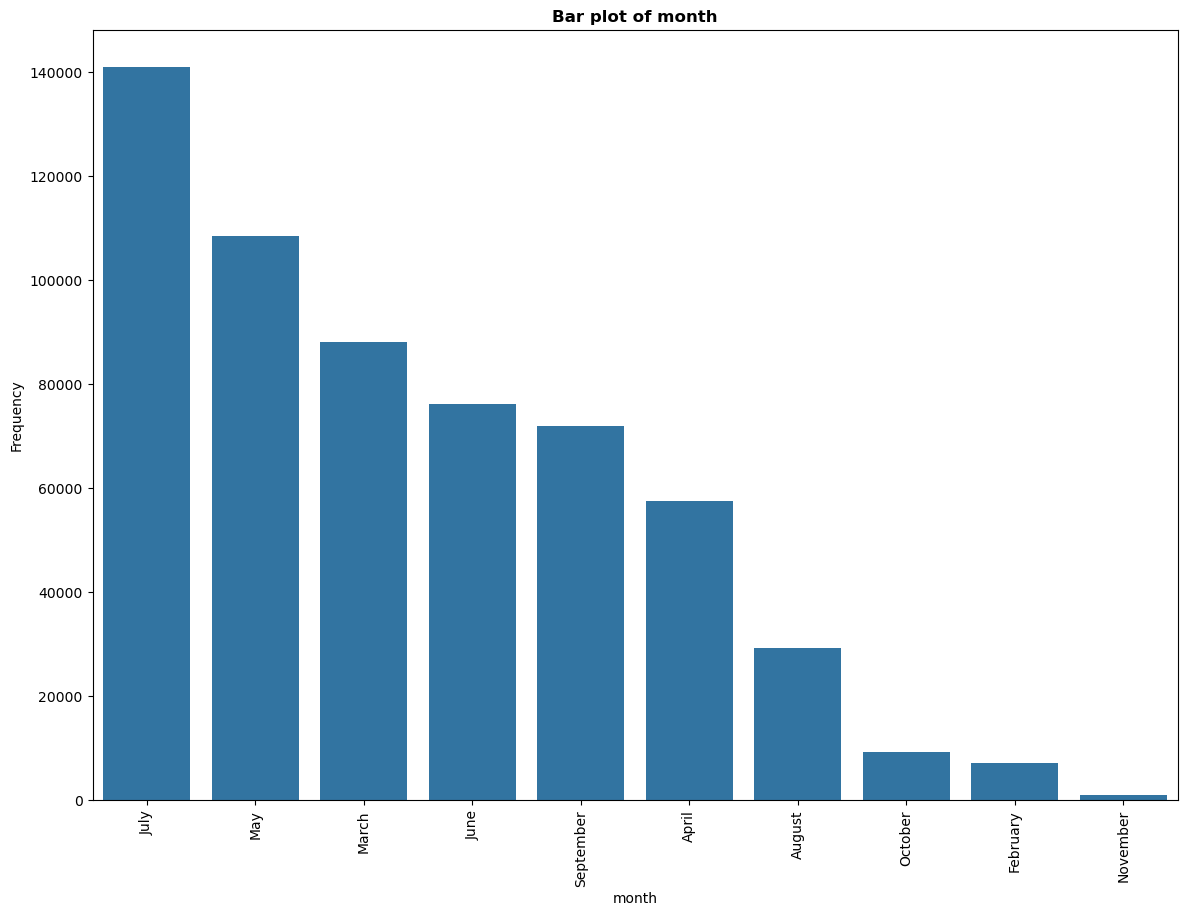

In [197]:
show_bar_plot(join_result, 'month')

**NOTE** By grouping the months into seasons or groups, there may be missing values due to the fact that a cyclist may not have raced in a particular season (e.g. only one race in this dataset!).

In [198]:
#We define a mapping from months to seasons (4) and we use it to generate a new column 'month'
season_mapping = {
    'December': 'Winter',
    'January': 'Winter',
    'February': 'Winter',
    'March': 'Spring',
    'April': 'Spring',
    'May': 'Spring',
    'June': 'Summer',
    'July': 'Summer',
    'August': 'Summer',
    'September': 'Autumn',
    'October': 'Autumn',
    'November': 'Autumn'
}
join_result['season'] = join_result['month'].map(season_mapping)

In [199]:
#We define a mapping from months to quarters (3 months) and we use it to generate a new column 'month'
quarter_mapping = {
    'January': 'Q1',
    'February': 'Q1',
    'March': 'Q1',
    'April': 'Q2',
    'May': 'Q2',
    'June': 'Q2',
    'July': 'Q3',
    'August': 'Q3',
    'September': 'Q3',
    'October': 'Q4',
    'November': 'Q4',
    'December': 'Q4'
}
join_result['quarter'] = join_result['month'].map(quarter_mapping)

In [200]:
join_result[['date','month','season','quarter']]

,date,month,season,quarter
0,1978-07-05,July,Summer,Q3
1,1978-07-05,July,Summer,Q3
2,1978-07-05,July,Summer,Q3
3,1978-07-05,July,Summer,Q3
4,1978-07-05,July,Summer,Q3
...,...,...,...,...
589860,2010-05-08,May,Spring,Q2
589861,2010-05-08,May,Spring,Q2
589862,2010-05-08,May,Spring,Q2
589863,2010-05-08,May,Spring,Q2


In [201]:
cyclists_performance.columns

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'height', 'weight', 'nationality', 'continent', 'geo area',
       'birth_year', 'AVG weighted position'],
      dtype='object')

In [202]:
# Determine the average seasonal position per cyclist
# The group by will return rows in this format:
# URL_Y   | SEASON | AVG POSITION
# cyclist | winter |avg_pos_in winter
# cyclist | spring |avg_pos_in_spring
# ....
# The unstack will make the result in this form
# URL_Y   | AVG_POS_WINT | AVG_POS_SPRING |AVG_POS_SUMM....
# cyclist | num          |   num          | num        ...
# cyclist | num          |   num          | num        ....
# .... 
season_means = join_result.groupby(['_url_y', 'season'])['position'].mean().unstack()
season_means=season_means.reset_index()

cyclists_performance=pd.merge(cyclists_performance, season_means, left_on='name', right_on='_url_y', how='inner')
cyclists_performance.drop('_url_y', axis=1, inplace=True) #remove useless column

# Determine the average position per cyclist in each quarter
#The structure of the result is similar as above
quarter_means = join_result.groupby(['_url_y', 'quarter'])['position'].mean().unstack()
quarter_means=quarter_means.reset_index()

cyclists_performance=pd.merge(cyclists_performance, quarter_means, left_on='name', right_on='_url_y', how='inner')
cyclists_performance.drop('_url_y', axis=1, inplace=True) #remove useless column

cyclists_performance

,name,BMI,median position,AVG position,# cyclist races,height,weight,nationality,continent,geo area,birth_year,AVG weighted position,Autumn,Spring,Summer,Winter,Q1,Q2,Q3,Q4
0,sean-kelly,23.77,6,16,629,180,77.0,Ireland,Europe,Northern Europe,1956,22,10.595745,7.384956,22.358757,20.0,7.531915,9.528037,23.161812,18.166667
1,gerrie-knetemann,19.959003,38,48,271,<NA>,NaN,Netherlands,Europe,Western Europe,1951,66,56.000000,14.661290,58.096154,NaN,14.545455,18.424242,66.005814,NaN
2,rene-bittinger,22.79,42,47,146,174,69.0,France,Europe,Western Europe,1954,54,15.000000,30.880952,54.607843,NaN,17.272727,37.318182,56.077778,18.000000
3,joseph-bruyere,23.086015,8,16,48,<NA>,NaN,Belgium,Europe,Western Europe,1948,21,29.000000,11.157895,19.071429,NaN,4.625000,13.947368,22.523810,NaN
4,sven-ake-nilsson,21.3,25,33,145,172,63.0,Sweden,Europe,Northern Europe,1951,38,17.142857,12.318182,38.189655,NaN,13.714286,26.718750,37.323529,15.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6090,ivan-raimondi,19.696783,173,173,1,<NA>,NaN,Italy,Europe,Southern Europe,1969,173,NaN,173.000000,NaN,NaN,173.000000,NaN,NaN,NaN
6091,jose-vincente-diaz,20.031931,17,17,1,<NA>,NaN,Colombia,America,America,1965,17,NaN,17.000000,NaN,NaN,17.000000,NaN,NaN,NaN
6092,jon-ander-insausti,25.45,54,54,1,187,89.0,Spain,Europe,Southern Europe,1992,54,NaN,NaN,54.000000,NaN,NaN,NaN,54.000000,NaN
6093,carlos-melero,20.011635,38,38,1,<NA>,NaN,Spain,Europe,Southern Europe,1948,38,NaN,38.000000,NaN,NaN,38.000000,NaN,NaN,NaN


In [203]:
#Rename the columns with the proper name
cyclists_performance.rename(columns={'Winter': 'AVG position Winter', 'Spring': 'AVG position Spring','Summer': 'AVG position Summer', 'Autumn': 'AVG position Autumn'}, inplace=True)
cyclists_performance.rename(columns={'Q1': 'AVG position Q1', 'Q2': 'AVG position Q2','Q3': 'AVG position Q3', 'Q4': 'AVG position Q4'}, inplace=True)

In [204]:
cyclists_performance.columns

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'height', 'weight', 'nationality', 'continent', 'geo area',
       'birth_year', 'AVG weighted position', 'AVG position Autumn',
       'AVG position Spring', 'AVG position Summer', 'AVG position Winter',
       'AVG position Q1', 'AVG position Q2', 'AVG position Q3',
       'AVG position Q4'],
      dtype='object')

In [205]:
cyclists_performance.shape

(6095, 20)

In [206]:
#Rounding of all the average positions. Notice that the rounding could be applied only if the value is not a NaN. Final cast to Int64
cyclists_performance['AVG position Winter'] = cyclists_performance['AVG position Winter'].apply(lambda x: round(x, 0) if pd.notna(x) else x).astype("Int64")
cyclists_performance['AVG position Spring'] = cyclists_performance['AVG position Spring'].apply(lambda x: round(x, 0) if pd.notna(x) else x).astype("Int64")
cyclists_performance['AVG position Summer'] = cyclists_performance['AVG position Summer'].apply(lambda x: round(x, 0) if pd.notna(x) else x).astype("Int64")
cyclists_performance['AVG position Autumn'] = cyclists_performance['AVG position Autumn'].apply(lambda x: round(x, 0) if pd.notna(x) else x).astype("Int64")

cyclists_performance['AVG position Q1'] = cyclists_performance['AVG position Q1'].apply(lambda x: round(x, 0) if pd.notna(x) else x).astype("Int64")
cyclists_performance['AVG position Q2'] = cyclists_performance['AVG position Q2'].apply(lambda x: round(x, 0) if pd.notna(x) else x).astype("Int64")
cyclists_performance['AVG position Q3'] = cyclists_performance['AVG position Q3'].apply(lambda x: round(x, 0) if pd.notna(x) else x).astype("Int64")
cyclists_performance['AVG position Q4'] = cyclists_performance['AVG position Q4'].apply(lambda x: round(x, 0) if pd.notna(x) else x).astype("Int64")

After the merge and post processing each row will have the following information:

In [207]:
cyclists_performance[cyclists_performance['name']=='sean-kelly']

,name,BMI,median position,AVG position,# cyclist races,height,weight,nationality,continent,geo area,birth_year,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4
0,sean-kelly,23.77,6,16,629,180,77.0,Ireland,Europe,Northern Europe,1956,22,11,7,22,20,8,10,23,18


In [208]:
print(f"AVG position in Q1: missing value for {cyclists_performance['AVG position Q1'].isna().sum()} over {cyclists_performance.shape[0]} ({(cyclists_performance['AVG position Q1'].isna().sum()*100/cyclists_performance.shape[0]):.2f})%")
print(f"AVG position in Q2: missing value for {cyclists_performance['AVG position Q2'].isna().sum()} over {cyclists_performance.shape[0]} ({(cyclists_performance['AVG position Q2'].isna().sum()*100/cyclists_performance.shape[0]):.2f})%")
print(f"AVG position in Q3: missing value for {cyclists_performance['AVG position Q3'].isna().sum()} over {cyclists_performance.shape[0]} ({(cyclists_performance['AVG position Q3'].isna().sum()*100/cyclists_performance.shape[0]):.2f})%")
print(f"AVG position in Q4: missing value for {cyclists_performance['AVG position Q4'].isna().sum()} over {cyclists_performance.shape[0]} ({(cyclists_performance['AVG position Q4'].isna().sum()*100/cyclists_performance.shape[0]):.2f})%")

AVG position in Q1: missing value for 1694 over 6095 (27.79)%
AVG position in Q2: missing value for 1023 over 6095 (16.78)%
AVG position in Q3: missing value for 2280 over 6095 (37.41)%
AVG position in Q4: missing value for 4270 over 6095 (70.06)%


In [209]:
print(f"AVG position Winter: missing value for {cyclists_performance['AVG position Winter'].isna().sum()} over {cyclists_performance.shape[0]} ({(cyclists_performance['AVG position Winter'].isna().sum()*100/cyclists_performance.shape[0]):.2f})%")
print(f"AVG position Spring: missing value for {cyclists_performance['AVG position Spring'].isna().sum()} over {cyclists_performance.shape[0]} ({(cyclists_performance['AVG position Spring'].isna().sum()*100/cyclists_performance.shape[0]):.2f})%")
print(f"AVG position Summer: missing value for {cyclists_performance['AVG position Summer'].isna().sum()} over {cyclists_performance.shape[0]} ({(cyclists_performance['AVG position Summer'].isna().sum()*100/cyclists_performance.shape[0]):.2f})%")
print(f"AVG position Autumn: missing value for {cyclists_performance['AVG position Autumn'].isna().sum()} over {cyclists_performance.shape[0]} ({(cyclists_performance['AVG position Autumn'].isna().sum()*100/cyclists_performance.shape[0]):.2f})%")

AVG position Winter: missing value for 4523 over 6095 (74.21)%
AVG position Spring: missing value for 737 over 6095 (12.09)%
AVG position Summer: missing value for 1945 over 6095 (31.91)%
AVG position Autumn: missing value for 2879 over 6095 (47.24)%


The presence of a considerable number of missing values is due to the fact that most cyclists have participated in very few races, as shown by the distribution of the 'number of participations' feature. For this reason, cyclists may have few associated records in the 'races' dataset, probably close to each other in time, so they may not have 'races' in some seasons/quarters. <br> 
Note that the percentage of missing values for Q2-Q3 and Spring-Summer are quite comparable as these categories cover more or less the same months. The main differences are between Q1-Winter and Q4-Autumn since the months are distributed in a different way in these two groupings. <br>
Notice that the "temporary" 'month' feature is an attribute with a meaningful ordering in its sematics, hence we cannot group together months that are not adjacent in the year in order to balance the number of races in each group (remember that most of the race events are concentrated in a group of months).

### Standard DEV of placements

In [210]:
# .std determines the standard deviation of the column 'position'
std_dev = join_result.groupby('_url_y')['position'].std().reset_index()
std_dev

,_url_y,position
0,aad-van-den-hoek,40.031627
1,aaron-gate,53.467426
2,aaron-kemps,50.218664
3,aaron-olsen,32.945490
4,aaron-van-poucke,32.794454
...,...,...
6090,zenon-jaskula,41.418590
6091,zhandos-bizhigitov,37.859889
6092,zico-waeytens,51.495756
6093,zoran-klemencic,64.437907


In [211]:
cyclists_performance=pd.merge(cyclists_performance, std_dev, left_on='name', right_on='_url_y', how='inner')
cyclists_performance.drop('_url_y', axis=1, inplace=True) #remove useless column
cyclists_performance.rename(columns={'position':'std_dev position'}, inplace=True)
cyclists_performance

,name,BMI,median position,AVG position,# cyclist races,height,weight,nationality,continent,geo area,...,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position
0,sean-kelly,23.77,6,16,629,180,77.0,Ireland,Europe,Northern Europe,...,22,11,7,22,20,8,10,23,18,24.497844
1,gerrie-knetemann,19.959003,38,48,271,<NA>,NaN,Netherlands,Europe,Western Europe,...,66,56,15,58,<NA>,15,18,66,<NA>,46.993017
2,rene-bittinger,22.79,42,47,146,174,69.0,France,Europe,Western Europe,...,54,15,31,55,<NA>,17,37,56,18,32.648452
3,joseph-bruyere,23.086015,8,16,48,<NA>,NaN,Belgium,Europe,Western Europe,...,21,29,11,19,<NA>,5,14,23,<NA>,19.723611
4,sven-ake-nilsson,21.3,25,33,145,172,63.0,Sweden,Europe,Northern Europe,...,38,17,12,38,<NA>,14,27,37,16,26.276978
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6090,ivan-raimondi,19.696783,173,173,1,<NA>,NaN,Italy,Europe,Southern Europe,...,173,<NA>,173,<NA>,<NA>,173,<NA>,<NA>,<NA>,NaN
6091,jose-vincente-diaz,20.031931,17,17,1,<NA>,NaN,Colombia,America,America,...,17,<NA>,17,<NA>,<NA>,17,<NA>,<NA>,<NA>,NaN
6092,jon-ander-insausti,25.45,54,54,1,187,89.0,Spain,Europe,Southern Europe,...,54,<NA>,<NA>,54,<NA>,<NA>,<NA>,54,<NA>,NaN
6093,carlos-melero,20.011635,38,38,1,<NA>,NaN,Spain,Europe,Southern Europe,...,38,<NA>,38,<NA>,<NA>,38,<NA>,<NA>,<NA>,NaN


Description of attribute 'std_dev position':


count    5392.000000
mean       37.294436
std        13.886510
min         0.000000
25%        29.888105
50%        38.976872
75%        45.809134
max       108.187338
Name: std_dev position, dtype: float64


Unique values:
[24.49784378 46.99301749 32.64845242 ... 56.55970297 36.76955262
 96.16652224]

Null values: 703 over 6095 records - (11.53%)

Top 5 most frequent values:
std_dev position
1.414214    16
2.828427    12
0.707107    10
2.121320    10
0.000000     8
Name: count, dtype: int64


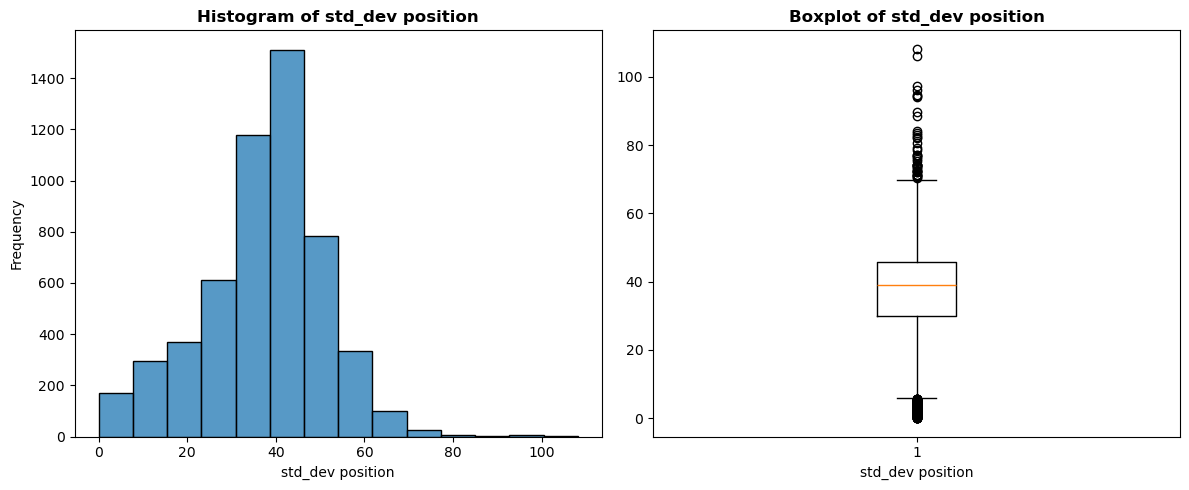

Outliers in std_dev position: [0.0, 1.7320508075688772, 2.1213203435596424, 3.9157800414902426, 4.031128874149275, 5.656854249492381, 4.349329450233296, 5.0579969684978385, 4.004404626190566, 5.100802075966271, 3.5355339059327378, 4.949747468305833, 4.764451699828638, 4.509249752822894, 2.0, 2.081665999466132, 4.0, 5.131601439446882, 1.0, 3.785938897200183, 70.91096041576044, 71.155536605456, 72.42823189835832, 72.3657377492968, 74.13838412050805, 2.081665999466133, 74.24621202458749, 73.43868821962545, 73.92933651825612, 75.17364513629043, 76.70408387769508, 72.74809766781338, 73.27289175859424, 75.84172863951811, 84.11809879838313, 4.242640687119285, 81.94103571064582, 82.92365967161201, 79.19595949289332, 89.77740329758454, 82.2455672564384, 88.38834764831844, 83.43860018001261, 94.40868604106298, 94.75230867899737, 94.04520189781083, 97.2745256135096, 96.16652224137046, 106.06601717798213, 2.8867513459481287, 2.0816659994661335, 108.18733752154178, 3.605551275463989, 3.391164991562

In [212]:
stats_and_distribution(cyclists_performance, 'std_dev position', attr_type='numerical')

From the histogram we can see that most riders do not have a very consistent behaviour in terms of race placings, i.e. they typically alternate between good and bad performances. The outliers shown in the lower part of the box plot are related to riders with fairly constant placings.

There are 703 cyclists with NaN std deviation of the position of their placements. This results is due to the fact that those cyclists have only a single recorded placement. Hence there is no variability in their positions so we can perform an imputation with a zero value.

In [213]:
cyclists_performance['std_dev position'].isna().sum()

703

In [214]:
cyclists_performance[(cyclists_performance['std_dev position'].isna()) & (cyclists_performance['# cyclist races']!=1)]

,name,BMI,median position,AVG position,# cyclist races,height,weight,nationality,continent,geo area,...,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position


In [215]:
cyclists_performance['std_dev position'] = cyclists_performance['std_dev position'].fillna(0)

Description of attribute 'std_dev position':


count    6095.000000
mean       32.992879
std        17.678627
min         0.000000
25%        22.952250
50%        37.116233
75%        44.798198
max       108.187338
Name: std_dev position, dtype: float64


Unique values:
[24.49784378 46.99301749 32.64845242 ... 56.55970297 36.76955262
 96.16652224]

Null values: 0 over 6095 records - (0.00%)

Top 5 most frequent values:
std_dev position
0.000000    711
1.414214     16
2.828427     12
0.707107     10
2.121320     10
Name: count, dtype: int64


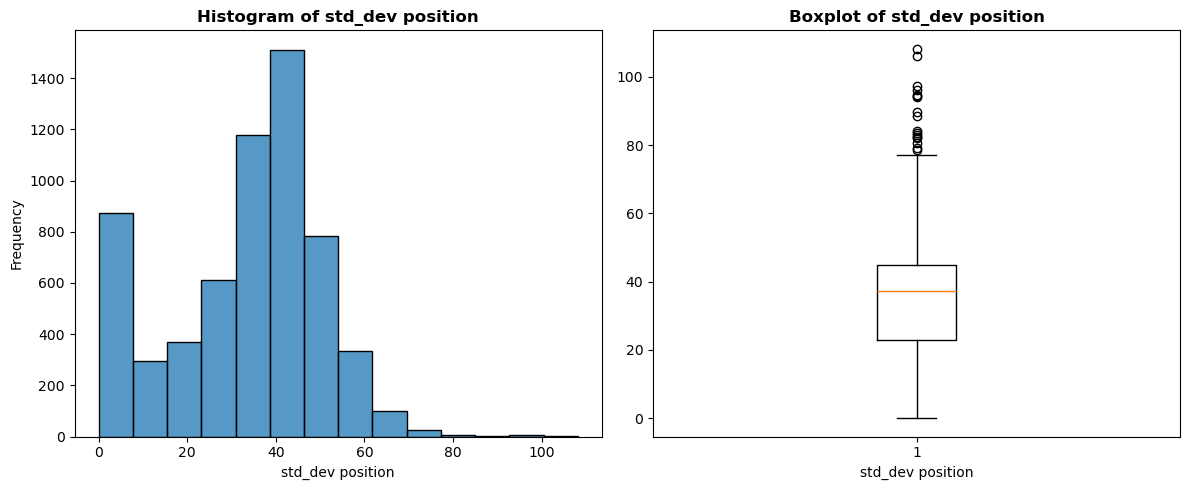

Outliers in std_dev position: [96.16652224137046, 97.2745256135096, 106.06601717798213, 108.18733752154178, 78.48885271170677, 79.19595949289332, 80.49016503068351, 94.75230867899737, 81.94103571064582, 82.92365967161201, 84.11809879838313, 82.2455672564384, 83.43860018001261, 88.38834764831844, 89.77740329758454, 94.04520189781083, 94.40868604106298]


In [216]:
stats_and_distribution(cyclists_performance, 'std_dev position', attr_type='numerical')

### Correlation between these new features

In [217]:
cyclists_performance.columns

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'height', 'weight', 'nationality', 'continent', 'geo area',
       'birth_year', 'AVG weighted position', 'AVG position Autumn',
       'AVG position Spring', 'AVG position Summer', 'AVG position Winter',
       'AVG position Q1', 'AVG position Q2', 'AVG position Q3',
       'AVG position Q4', 'std_dev position'],
      dtype='object')

In [218]:
cyclists_performance.dtypes

name                      object
BMI                      Float64
median position            int64
AVG position               int64
# cyclist races            int64
height                     Int64
weight                   float64
nationality               object
continent                 object
geo area                  object
birth_year                 Int64
AVG weighted position      Int64
AVG position Autumn        Int64
AVG position Spring        Int64
AVG position Summer        Int64
AVG position Winter        Int64
AVG position Q1            Int64
AVG position Q2            Int64
AVG position Q3            Int64
AVG position Q4            Int64
std_dev position         float64
dtype: object

In [219]:
cyclists_performance.describe()

,BMI,median position,AVG position,# cyclist races,height,weight,birth_year,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position
count,6095.0,6095.000000,6095.000000,6095.000000,3128.0,3063.000000,6085.0,6095.0,3216.0,5358.0,4150.0,1572.0,4401.0,5072.0,3815.0,1825.0,6095.000000
mean,21.209146,76.079409,76.355373,96.778507,179.813939,68.655762,1974.033361,80.594258,71.435323,71.476297,80.255904,61.675573,69.879118,71.068415,84.641678,52.411507,32.992879
std,1.355285,37.708953,33.147284,140.804582,6.451356,6.349417,15.550961,32.641542,36.140552,35.400249,32.58477,30.006837,36.369873,34.07043,31.550981,30.895782,17.678627
min,16.354805,0.000000,0.000000,1.000000,154.0,48.000000,1933.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
25%,20.31,48.000000,54.000000,5.000000,175.0,64.000000,1962.0,60.0,44.0,44.0,61.0,41.0,42.0,46.0,64.0,27.0,22.952250
50%,21.188612,78.000000,78.000000,30.000000,180.0,69.000000,1974.0,83.0,74.0,72.0,82.0,60.0,71.0,72.0,86.0,48.0,37.116233
75%,22.09,103.000000,99.000000,133.000000,184.0,73.000000,1987.0,102.0,97.0,97.0,102.0,82.0,95.0,95.0,106.0,75.0,44.798198
max,27.77,205.000000,205.000000,959.000000,204.0,94.000000,2004.0,205.0,189.0,205.0,200.0,145.0,202.0,205.0,200.0,167.0,108.187338


**Pearson Correlation**
- _Assumption_: Assumes a linear relationship and that data is normally distributed.
- _Use Case_: Suitable for continuous data when you want to measure linear associations.
- _Strength_: Sensitive to linear relationships, good for capturing linear trends.
- _Formula_: Based on covariance and standard deviations of the original data.
- _Interpretation_: Measures the strength and direction of the linear relationship, ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation), with 0 indicating no linear correlation.

**Spearman Rank Correlation**
- _Assumption_: Non-parametric and does not assume a linear relationship but assumes a monotonic relationship.
- _Use Case_: Appropriate for both continuous and ordinal data. Particularly useful when the relationship is expected to be monotonic but not necessarily linear.
- _Strength_: Robust to outliers and non-linearity.
- _Formula_: Calculates the correlation based on the ranks of data points.
- _Interpretation_: Measures the strength and direction of the monotonic relationship, similar to Kendall’s Tau.

**Kendall’s Tau Rank Correlation**
- _Assumption_: Non-parametric and makes no assumptions about the data distribution.
- _Use Case_: Suitable for both continuous and ordinal (ranked) data. Useful when the data may not follow a linear relationship.
- _Strength_: Robust to outliers and non-linearity.
- _Formula_: Based on concordant and discordant pairs of data points.
- _Interpretation_: Measures the similarity in ranking order between two variables, where 1 indicates perfect agreement, -1 indicates perfect disagreement, and 0 suggests no association.

In [220]:
correlation_matrix_p=correlations(cyclists_performance.drop('birth_year', axis=1, inplace=False))
correlation_matrix_p

,BMI,median position,AVG position,# cyclist races,height,weight,AVG weighted position,AVG position Autumn,AVG position Spring,AVG position Summer,AVG position Winter,AVG position Q1,AVG position Q2,AVG position Q3,AVG position Q4,std_dev position,correlation_type
BMI,1.000000,0.012153,0.000887,-0.017400,-0.031881,0.457497,0.013774,0.032065,-0.024430,0.040446,0.006487,-0.033244,0.002150,0.056613,-0.025304,0.047109,kendall
median position,0.012153,1.000000,0.892170,0.015174,0.102441,0.109662,0.838039,0.576083,0.705416,0.666218,0.388934,0.590390,0.718530,0.646659,0.397758,0.183822,kendall
AVG position,0.000887,0.892170,1.000000,0.028629,0.099582,0.088598,0.909117,0.583939,0.732363,0.696745,0.406926,0.614548,0.731259,0.682492,0.399379,0.188807,kendall
# cyclist races,-0.017400,0.015174,0.028629,1.000000,-0.009508,-0.024812,0.025660,-0.004145,-0.009606,-0.032633,-0.153240,-0.004681,-0.013839,-0.037777,-0.054618,0.451992,kendall
height,-0.031881,0.102441,0.099582,-0.009508,1.000000,0.540682,0.096440,0.088658,0.084617,0.121069,0.074924,0.078107,0.102301,0.117106,0.089396,-0.002626,kendall
weight,0.457497,0.109662,0.088598,-0.024812,0.540682,1.000000,0.098786,0.105853,0.047001,0.145706,0.053341,0.037048,0.088197,0.157636,0.049458,0.079243,kendall
AVG weighted position,0.013774,0.838039,0.909117,0.025660,0.096440,0.098786,1.000000,0.547290,0.676498,0.704304,0.375906,0.575079,0.666254,0.719182,0.352379,0.250160,kendall
AVG position Autumn,0.032065,0.576083,0.583939,-0.004145,0.088658,0.105853,0.547290,1.000000,0.483232,0.392458,0.243071,0.411265,0.480590,0.630302,0.522859,0.149210,kendall
AVG position Spring,-0.024430,0.705416,0.732363,-0.009606,0.084617,0.047001,0.676498,0.483232,1.000000,0.377779,0.355631,0.733959,0.757592,0.376034,0.388108,0.100095,kendall
AVG position Summer,0.040446,0.666218,0.696745,-0.032633,0.121069,0.145706,0.704304,0.392458,0.377779,1.000000,0.272011,0.334125,0.536089,0.699350,0.287698,0.231073,kendall


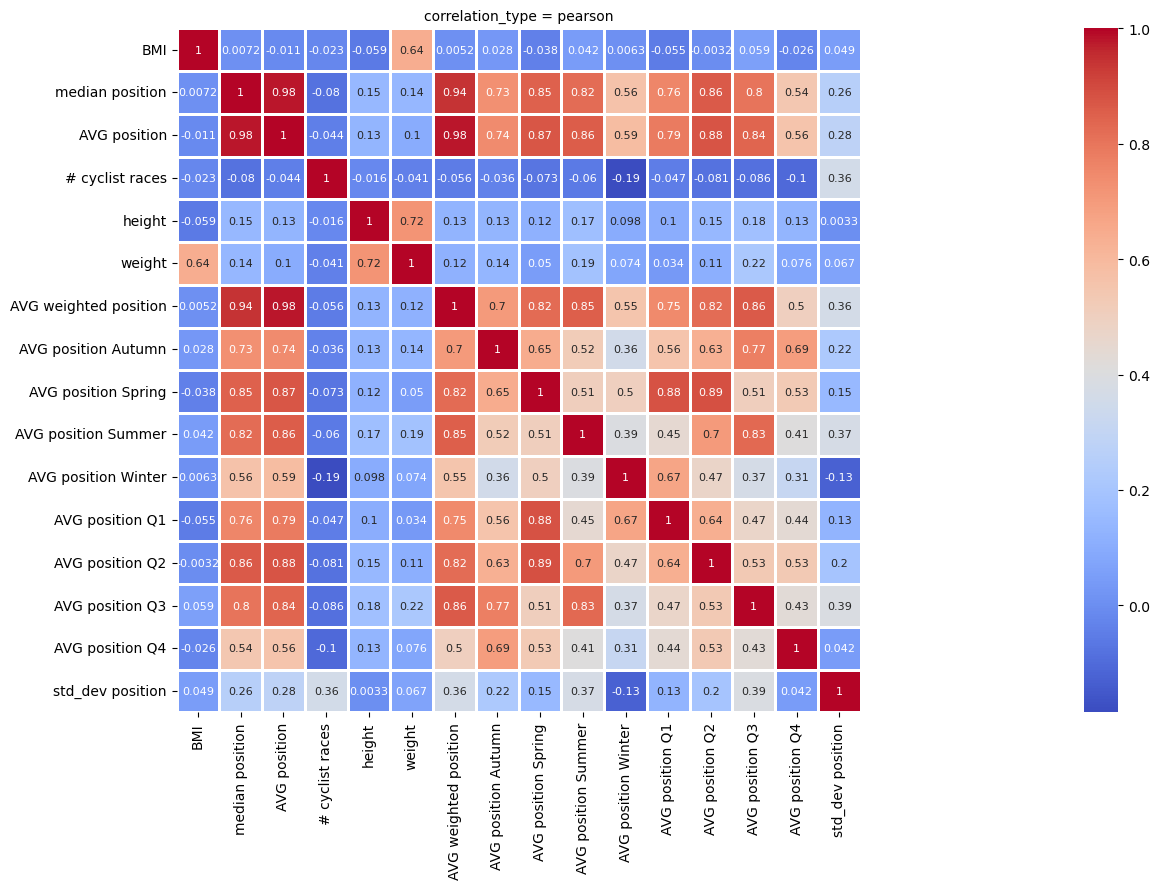

In [221]:
only_pearson=correlation_matrix_p[correlation_matrix_p['correlation_type'] == 'pearson']
g = sbn.FacetGrid(only_pearson, col="correlation_type", col_wrap=1, height=9, aspect=5)
g.map_dataframe(lambda data, color: sbn.heatmap(
    data[data.columns[:-1]], #Ignore the last column of the matrix which contains the correlation type
    cmap="coolwarm", #Colormap 
    annot=True, #Correlation values inside the cell
    square=True, #Square shape for each cell of the matrix
    cbar=True, #Color bar next to the matrix to "visually" interpret the correlation
    linewidths=1,  #Lines between cells
    annot_kws={"size": 8}  #Font size
))
plt.show()
plt.close()

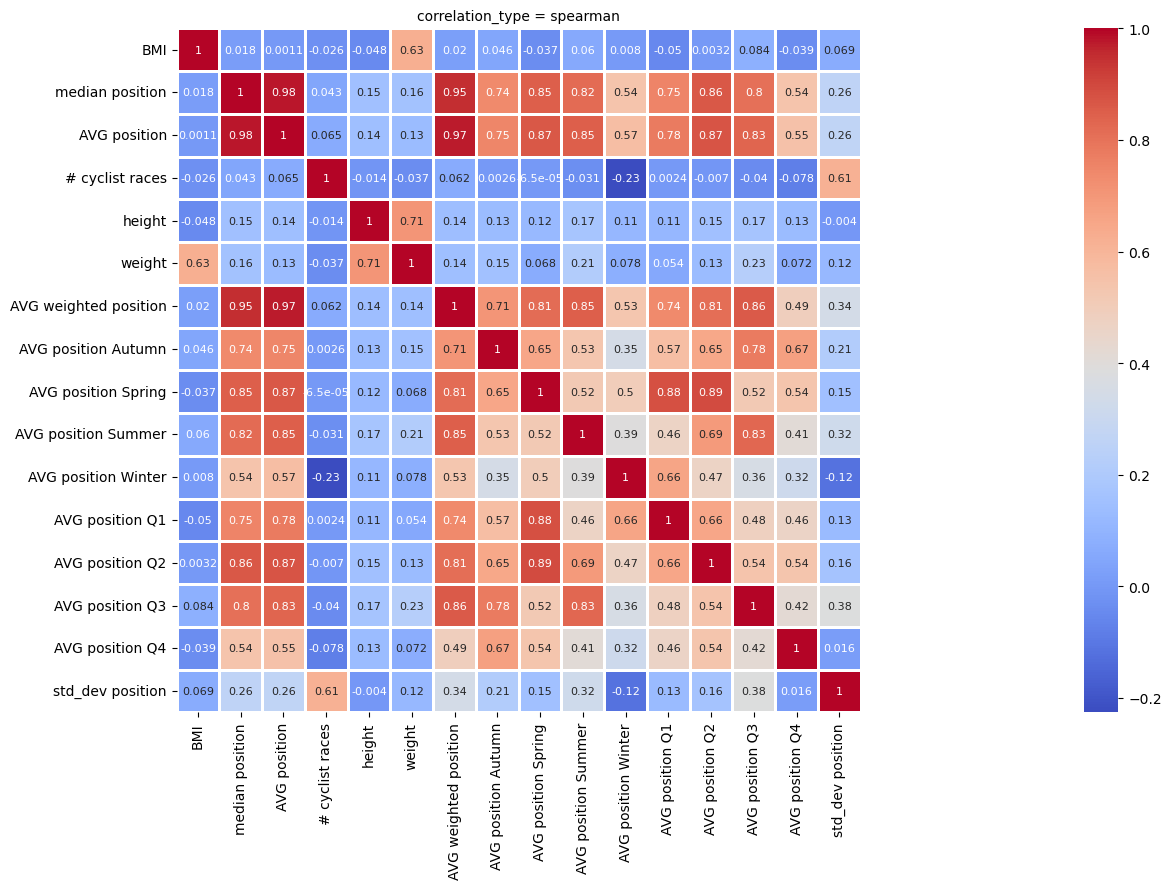

In [222]:
only_spearman=correlation_matrix_p[correlation_matrix_p['correlation_type'] == 'spearman']
g = sbn.FacetGrid(only_spearman, col="correlation_type", col_wrap=1, height=9, aspect=5)
g.map_dataframe(lambda data, color: sbn.heatmap(
    data[data.columns[:-1]], #Ignore the last column of the matrix which contains the correlation type
    cmap="coolwarm", #Colormap 
    annot=True, #Correlation values inside the cell
    square=True, #Square shape for each cell of the matrix
    cbar=True, #Color bar next to the matrix to "visually" interpret the correlation
    linewidths=1,  #Lines between cells
    annot_kws={"size": 8}  #Font size
))
plt.show()
plt.close()

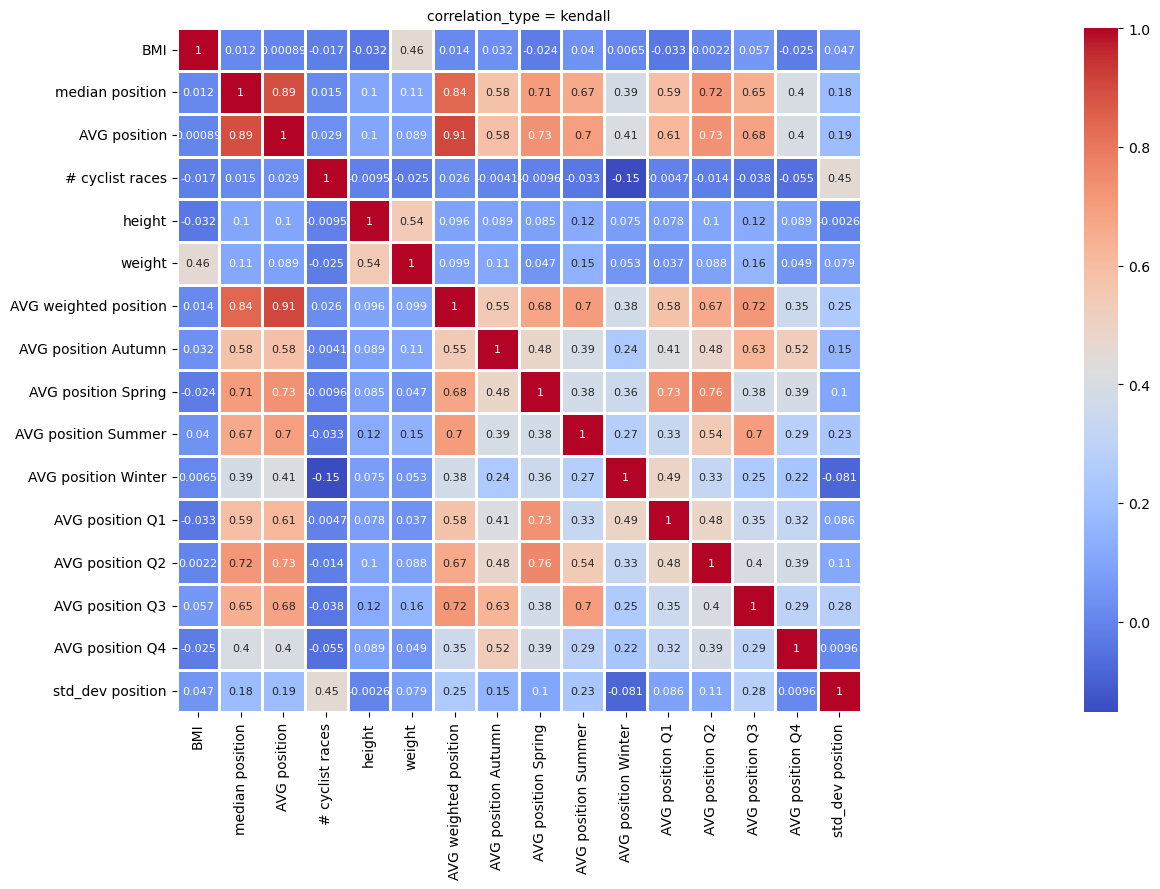

In [223]:
only_kendall=correlation_matrix_p[correlation_matrix_p['correlation_type'] == 'kendall']
g = sbn.FacetGrid(only_kendall, col="correlation_type", col_wrap=1, height=9, aspect=5)
g.map_dataframe(lambda data, color: sbn.heatmap(
    data[data.columns[:-1]], #Ignore the last column of the matrix which contains the correlation type
    cmap="coolwarm", #Colormap 
    annot=True, #Correlation values inside the cell
    square=True, #Square shape for each cell of the matrix
    cbar=True, #Color bar next to the matrix to "visually" interpret the correlation
    linewidths=1,  #Lines between cells
    annot_kws={"size": 8}  #Font size
))
plt.show()
plt.close()

**Observations on the correlation scores** <br>
_*Pearson*_ <br>
As expected, the '_height_' and the '_weight_' features are quite correlated (Pearson's score of 0.72). This score is the same as the one determined at the beginning of the data understanding since we have decided to directly impute the BMI feature. After the imputation the BMI is highly correlated to the '_weight_' (Pearson's score around 0.65) given the fact that the BMI formula is 
$$
\text{BMI} = \frac{\text{Weight (kg)}}{\text{Height (m)}^2}
$$ 

hence there is a linear relationship between the two values. Regarding the correlation between '_height_' and '_BMI_', the score is very low, in fact the '_height_' is in the denominator of the formula and the relationship is not linear but quadratic. The score is negative because as '_height_' increases '_BMI_' decreases. <br><br>

_*Spearman | Kendall*_ <br>
The '_AVG position_' and the '_Median position_' are very highly correlated (Kendall score 0.89 and Spearman score 0.98) since both the features express the central tendency of the feature '_position_' for each cyclists. As we know, the mean is more sensitive to outliers, while the median is more robust in this sense. The same observation is still valid for the high correlation between <'_AVG weighted position_', '_Median position_'> and '_AVG weighted position_', '_AVG position_'> with a score near to 1.<br>
A very high correlation indicates that the two values may be quite similar, so that the cyclists' placings are generally normal, without extreme outliers (e.g. many good placings followed by very poor ones). <br>

We can see that there is a high Spearman and Kendall correlation between the _AVG position_ and the _Median position_ with the AVG positions in all seasons or quarters, especially for the Spring-Summer-Autumn seasons and the quarters from Q1 to Q3. The lower correlation for winter positions and Q4 may be due to the fact that there are very few rows in the 'races' dataset in these periods, so that few results have an high impact on this numeric score. <br>

In the right bottom part of the Spearman heatmap matrix we can identify good correlation score between columns referring more or less to the same month, like those between '_AVG Position in Spring_' and, '_AVG Position in Q1_' or '_AVG Position in Q2_'. In fact the month coverage is:
- 'Spring' --> March, April and May 
- 'Q1' --> January, February and March
 - 'Q2' --> April, May and June

#### Write the new dataset in a new csv

In [ ]:
cyclists_performance.head()
dataset_to_save=cyclists_performance.drop(['height', 'weight'], axis=1, inplace=False)
#dataset_to_save.to_csv('../../dataset/preprocessedCyclists.csv', index=False)